# NeuroShield AI: Exploratory Data Analysis of Stroke Risk Factors

This notebook focuses on **understanding the dataset**, discovering trends and patterns, checking data quality, and identifying relationships with stroke occurrence. It is **not** intended to build or evaluate a predictive model at this stage.

The analysis is organized around:
1. Basic user information
2. Health and medical history
3. Lifestyle and physical activity
4. Physical and mental well-being
5. Stroke target variable

## 1. Objectives

- Understand the structure and size of the dataset.
- Check data types, missing values, duplicates, and unusual values.
- Examine the distribution of the stroke target variable.
- Explore each meaningful variable group.
- Compare feature distributions across stroke and non-stroke groups.
- Identify possible trends, associations, and outliers.
- Record observations without making causal claims.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load the Dataset

Update the path below if your dataset is stored in a different location.

In [2]:
df = pd.read_csv("../dataset/processed/transformed_train.csv")

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset loaded successfully: 345,242 rows × 48 columns


,binary__Sex_of_Respondent_Male,"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes,binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,"binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes",binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,"binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes",binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days,binary__Physical_Activity_Index_Meet Aerobic Recommendations,binary__Adults_that_participated_in_greater_than_300_minutes_(or_vigorous_equivalent_minutes)_of_physical_activity_per_week_(2-levels)._301+ minutes (or vigorous equivalent minutes) of physical activity,"multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_No","multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_No, pre-diabetes or borderline diabetes","multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_Yes","multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_Yes, but female told only during pregnancy","multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Current smoker","multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Former smoker","multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Never smoked","multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_Don't know / Not sure","multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_No","multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_Yes","multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_No","multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_Yes","multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_Yes, during pregnancy",multi__Are_you_currently?_A homemaker,multi__Are_you_currently?_A student,multi__Are_you_currently?_Employed for wages,multi__Are_you_currently?_Out of work for 1 year or more,multi__Are_you_currently?_Out of work for less than 1 year,multi__Are_you_currently?_Retired,multi__Are_you_currently?_Self-employed,multi__Are_you_currently?_Unable to work,multi__Are_you:_(marital_status)_A me

## 3. Basic Dataset Understanding

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")


Dataset shape: (345242, 48)

Column names:
1. binary__Sex_of_Respondent_Male
2. binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes
3. binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes
4. binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD
5. binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes
6. binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes
7. binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes
8. binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes
9. binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics

In [4]:
# Select columns having exactly 2 unique values
binary_cols = [
    col for col in df.columns
    if df[col].nunique() == 2
]

# Convert those columns to int64
df[binary_cols] = df[binary_cols].astype("int8")

# Select remainder columns except BMI
remainder_cols = [
    col for col in df.columns
    if col.startswith("remainder__") and "BMI" not in col
]

# Select all ordinal columns
ordinal_cols = [
    col for col in df.columns
    if col.startswith("ordinal__")
]

# Combine both column lists
cols_to_convert = remainder_cols + ordinal_cols

# Convert selected columns to int64
df[cols_to_convert] = df[cols_to_convert].astype("int64")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345242 entries, 0 to 345241
Data columns (total 48 columns):
 #   Column                                                                                                                                                                                                                                         Non-Null Count   Dtype  
---  ------                                                                                                                                                                                                                                         --------------   -----  
 0   binary__Sex_of_Respondent_Male                                                                                                                                                                                                                 345242 non-null  int8   
 1   binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_

In [6]:
display(df.describe(include='all').T)

,count,mean,std,min,25%,50%,75%,max
binary__Sex_of_Respondent_Male,345242.0,0.470490,0.499129,0.00,0.00,0.0,1.00,1.00
"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",345242.0,0.406497,0.491180,0.00,0.00,0.0,1.00,1.00
binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes,345242.0,0.366268,0.481785,0.00,0.00,0.0,1.00,1.00
binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,345242.0,0.083628,0.276830,0.00,0.00,0.0,0.00,1.00
"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",345242.0,0.054000,0.226018,0.00,0.00,0.0,0.00,1.00
binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,345242.0,0.053939,0.225898,0.00,0.00,0.0,0.00,1.00
"binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes",345242.0,0.366679,0.481899,0.00,0.00,0.0,1.00,1.00
binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,345242.0,0.283094,0.450502,0.00,0.00,0.0,1.00,1.00
"binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes",345242.0,0.753871,0.430755,0.00,1.00,1.0,1.00,1.00
binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days,345242.0,0.246129,0.430755,0.00,0.00,0.0,0.00,1.00


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))


Number of duplicate rows: 233

Missing values:


,missing_values
binary__Sex_of_Respondent_Male,0
"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",0
binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes,0
binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,0
"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",0
binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,0
"binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes",0
binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,0
"binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes",0
binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days,0


## 4. Variable Groups
Basic User Information (18 columns)
 - binary__Sex_of_Respondent_Male
 - multi__Are_you:_(marital_status)_A member of an unmarried couple
 - multi__Are_you:_(marital_status)_Divorced
 - multi__Are_you:_(marital_status)_Married
 - multi__Are_you:_(marital_status)_Never married
 - multi__Are_you:_(marital_status)_Separated
 - multi__Are_you:_(marital_status)_Widowed
 - multi__Are_you_currently?_A homemaker
 - multi__Are_you_currently?_A student
 - multi__Are_you_currently?_Employed for wages
 - multi__Are_you_currently?_Out of work for 1 year or more
 - multi__Are_you_currently?_Out of work for less than 1 year
 - multi__Are_you_currently?_Retired
 - multi__Are_you_currently?_Self-employed
 - multi__Are_you_currently?_Unable to work
 - ordinal__Is_your_annual_household_income_from_all_sources:_(If_respondent_refuses_at_any_income_level,_code_Refused.)
 - ordinal__What_is_the_highest_grade_or_year_of_school_you_completed?
 - remainder__Imputed_Age_value_collapsed_above_80

Health and Medical History (16 columns)
 - binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes
 - binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes
 - binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes
 - binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes
 - binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes
 - binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD
 - multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_No
 - multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_No, pre-diabetes or borderline diabetes
 - multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_Yes
 - multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_Yes, but female told only during pregnancy
 - multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_No
 - multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_Yes
 - multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_Yes, during pregnancy
 - multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_Don't know / Not sure
 - multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_No
 - multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_Yes

Lifestyle and Physical Activity (8 columns)
 - binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days
 - binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes
 - binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes
 - binary__Physical_Activity_Index_Meet Aerobic Recommendations
 - multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Current smoker
 - multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Former smoker
 - multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Never smoked
 - remainder__Minutes_of_Physical_Activity_per_week_for_First_Activity

Physical and Mental Well-being (3 columns)
 - remainder__Body_Mass_Index_(BMI)
 - remainder__Now_thinking_about_your_mental_health,_which_includes_stress,_depression,_and_problems_with_emotions,_for_how_many_days_during_the_past_30_days_was_your_mental_health_not_good?
 - remainder__Now_thinking_about_your_physical_health,_which_includes_physical_illness_and_injury,_for_how_many_days_during_the_past_30_days_was_your_physical_health_not_good?

Target (1 columns)
 - (Ever_told)_(you_had)_a_stroke.

## 5. Target Variable: Stroke Distribution

This section checks how many observations belong to each stroke class. A large difference between the classes indicates class imbalance.

In [8]:
target_col= "(Ever_told)_(you_had)_a_stroke."
stroke_counts = df[target_col].value_counts(dropna=False).sort_index()
stroke_percentages = df[target_col].value_counts(normalize=True, dropna=False).sort_index().mul(100)

stroke_summary = pd.DataFrame({
    "count": stroke_counts,
    "percentage": stroke_percentages.round(2)
})

display(stroke_summary)


,count,percentage
(Ever_told)_(you_had)_a_stroke.,,
0,330571,95.75
1,14671,4.25


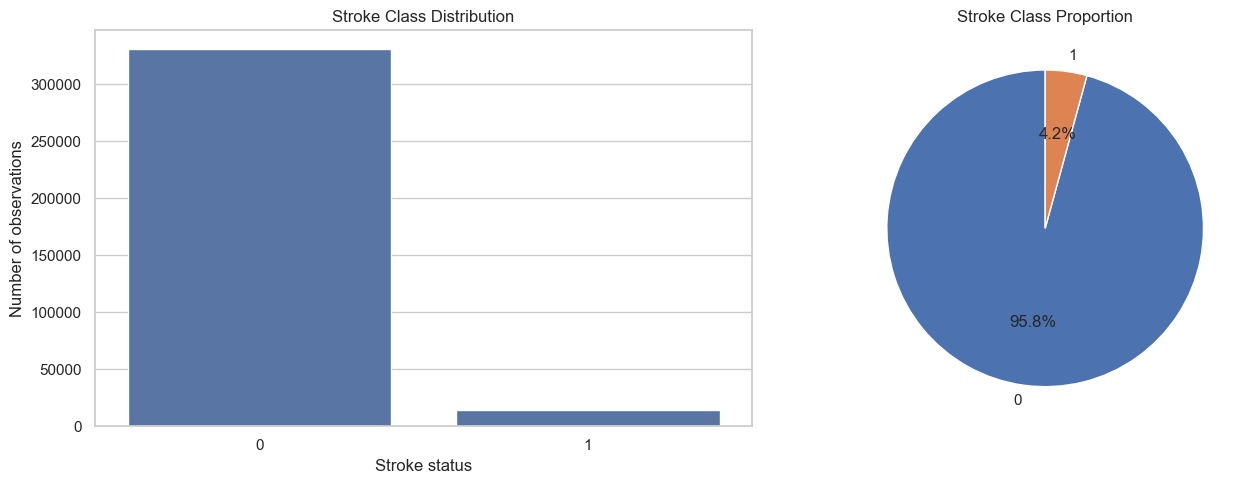

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=target_col, ax=axes[0])
axes[0].set_title("Stroke Class Distribution")
axes[0].set_xlabel("Stroke status")
axes[0].set_ylabel("Number of observations")

axes[1].pie(
    stroke_counts.values,
    labels=stroke_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Stroke Class Proportion")

plt.tight_layout()
plt.show()


## 6. Numerical Variable Analysis

In [10]:
numeric_feature_cols = [
    col for col in df.select_dtypes(include="int8").columns
    if col != target_col
]

display(df[numeric_feature_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
binary__Sex_of_Respondent_Male,345242.0,0.470490,0.499129,0.0,0.0,0.0,1.0,1.0
"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",345242.0,0.406497,0.491180,0.0,0.0,0.0,1.0,1.0
binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes,345242.0,0.366268,0.481785,0.0,0.0,0.0,1.0,1.0
binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,345242.0,0.083628,0.276830,0.0,0.0,0.0,0.0,1.0
"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",345242.0,0.054000,0.226018,0.0,0.0,0.0,0.0,1.0
binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,345242.0,0.053939,0.225898,0.0,0.0,0.0,0.0,1.0
"binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes",345242.0,0.366679,0.481899,0.0,0.0,0.0,1.0,1.0
binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,345242.0,0.283094,0.450502,0.0,0.0,0.0,1.0,1.0
"binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes",345242.0,0.753871,0.430755,0.0,1.0,1.0,1.0,1.0
binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days,345242.0,0.246129,0.430755,0.0,0.0,0.0,0.0,1.0


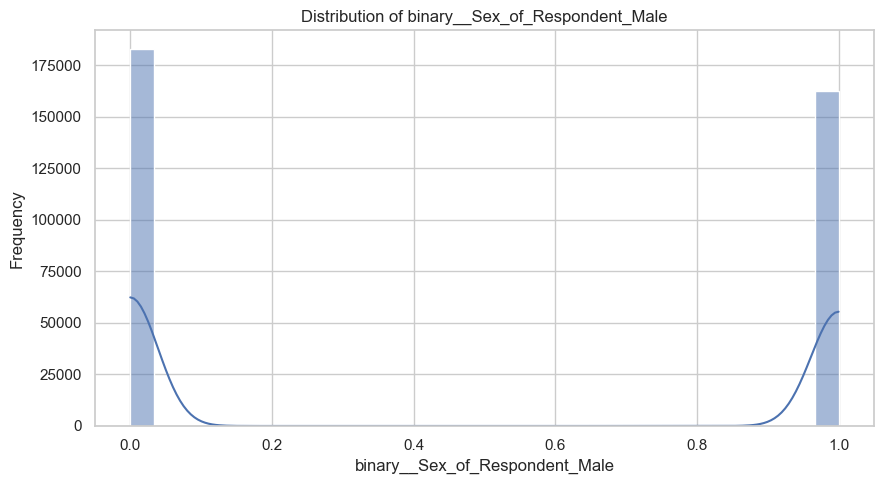

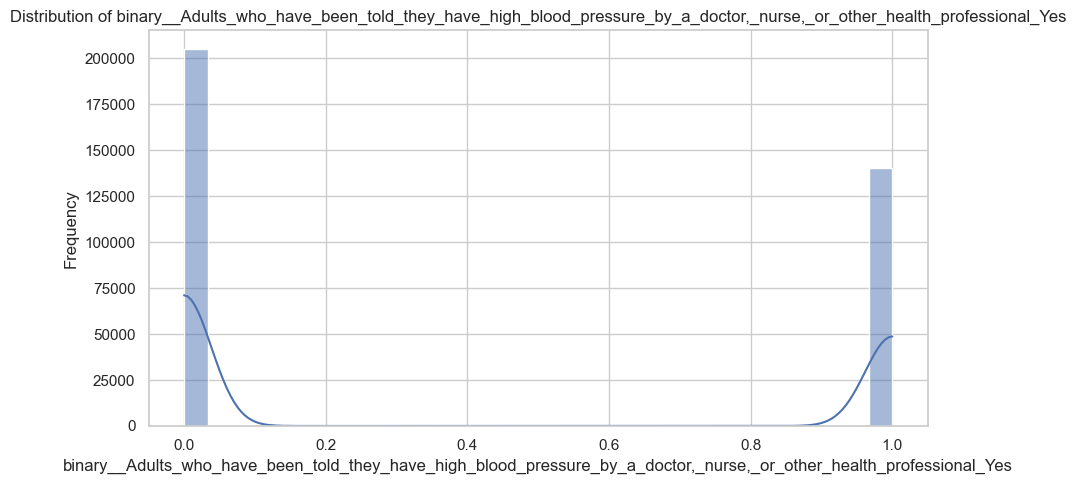

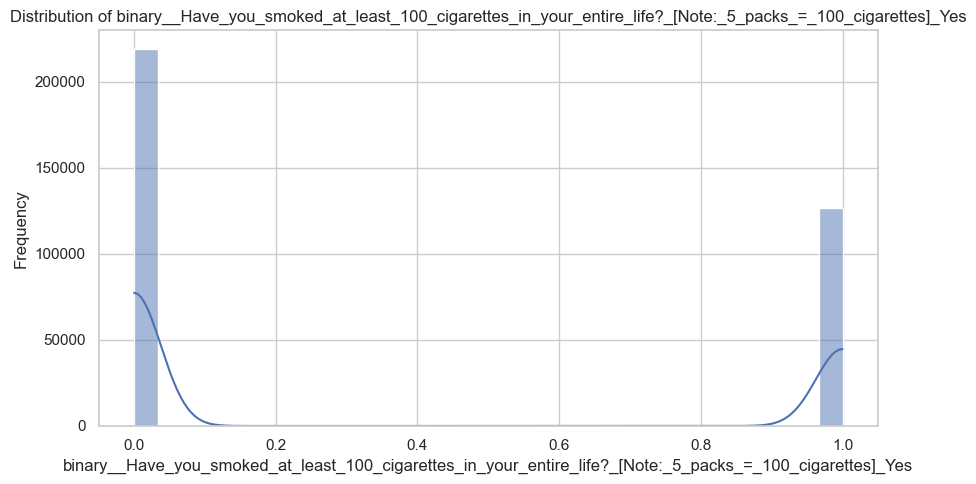

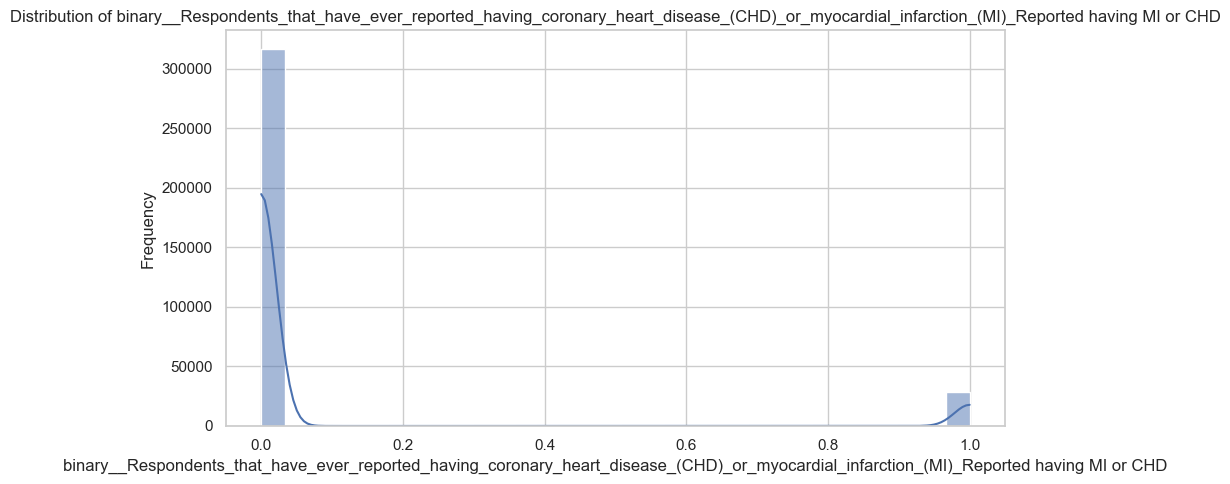

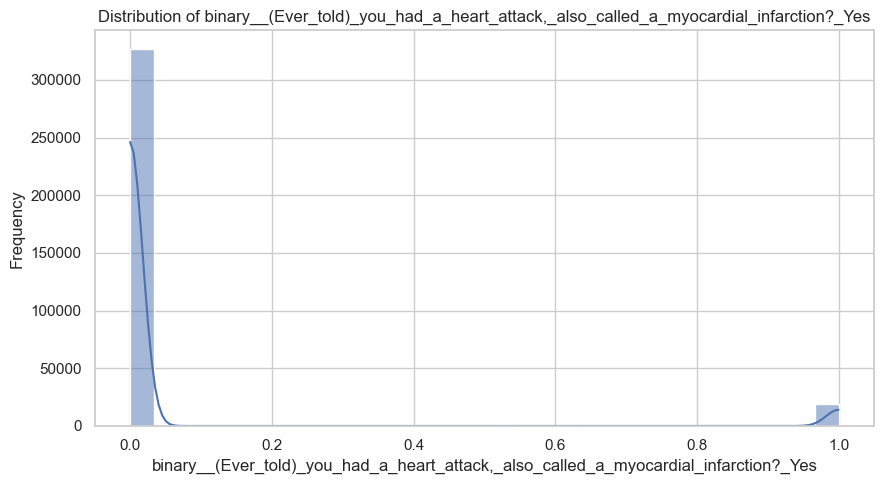

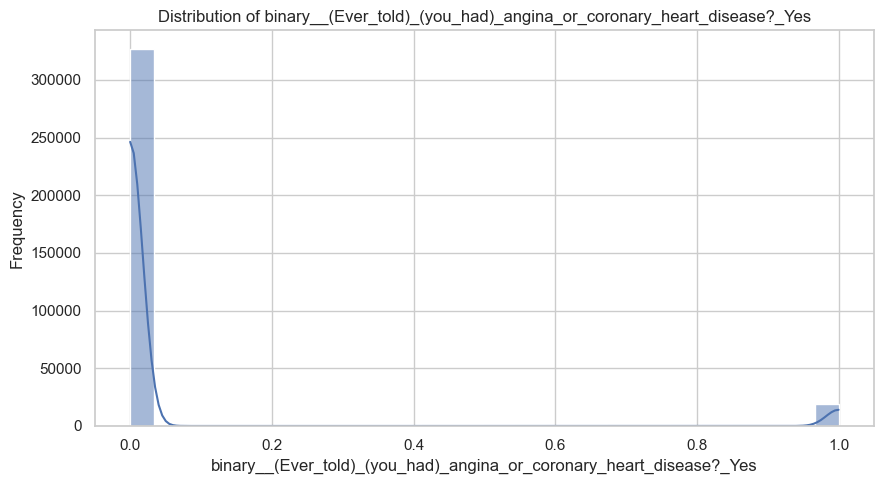

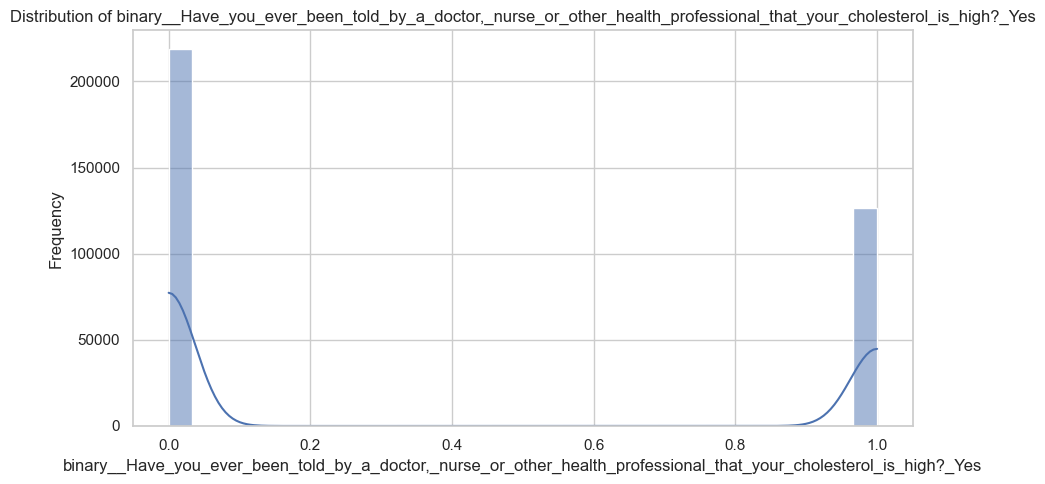

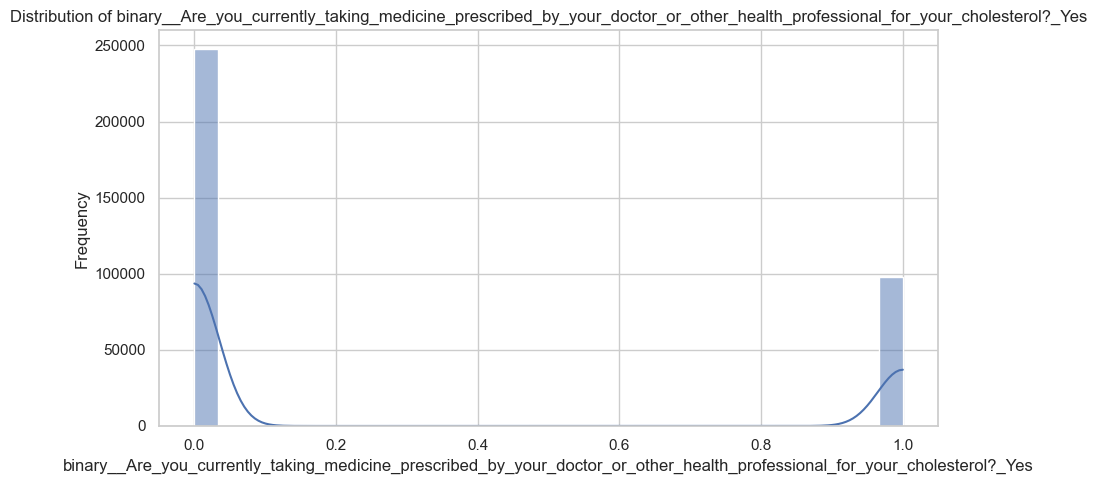

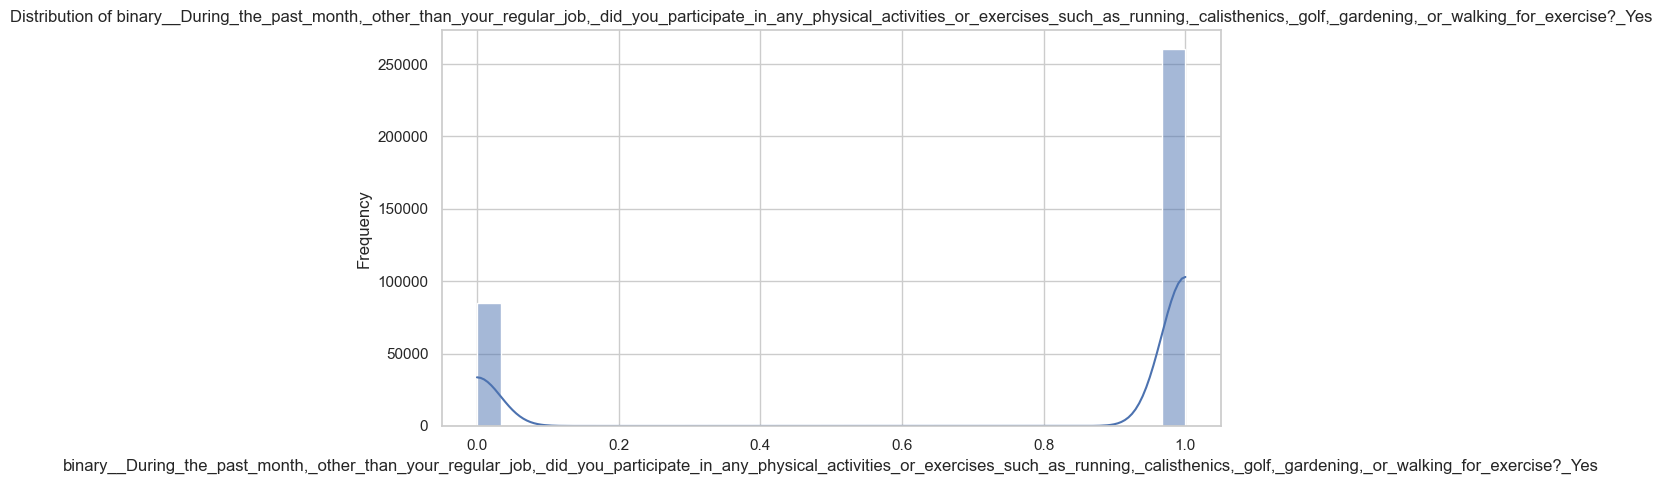

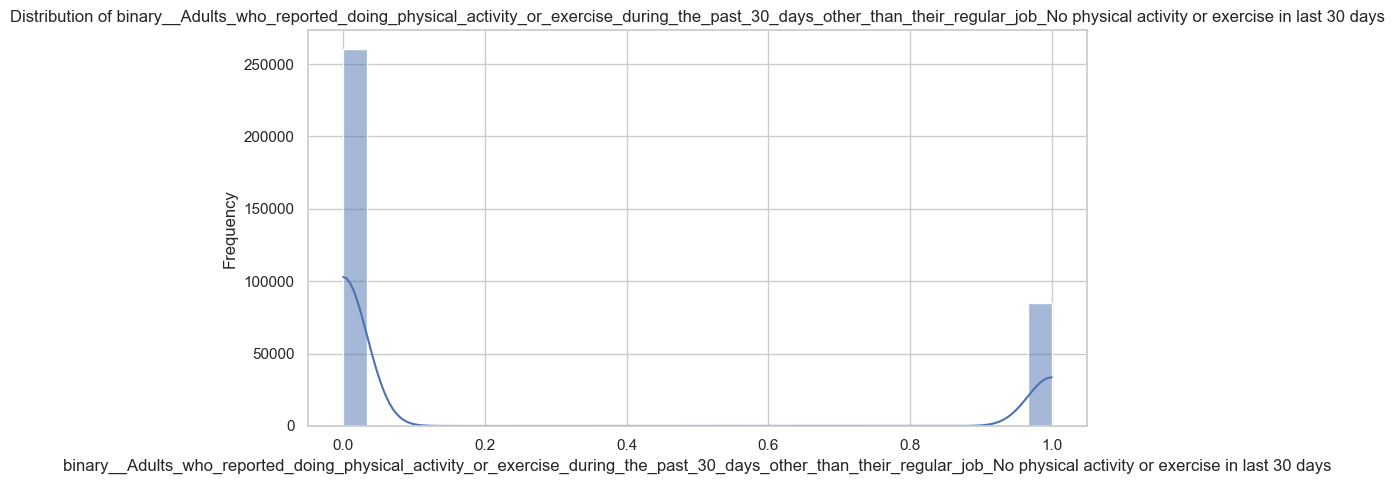

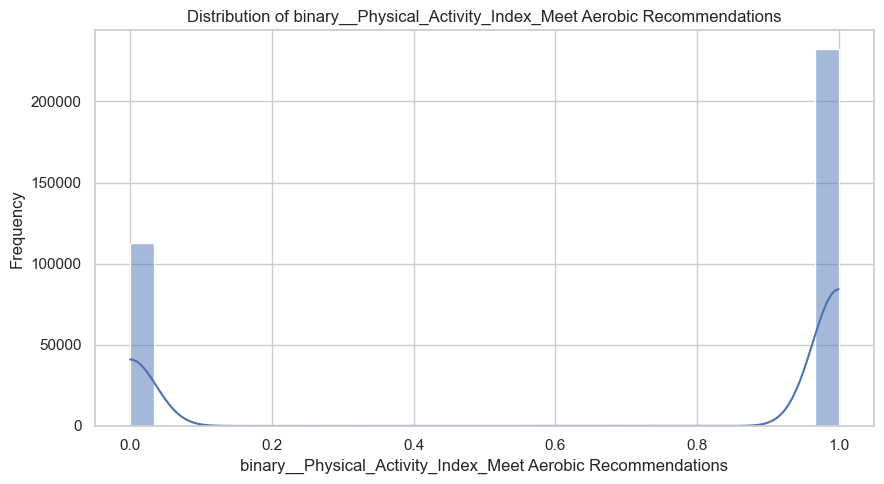

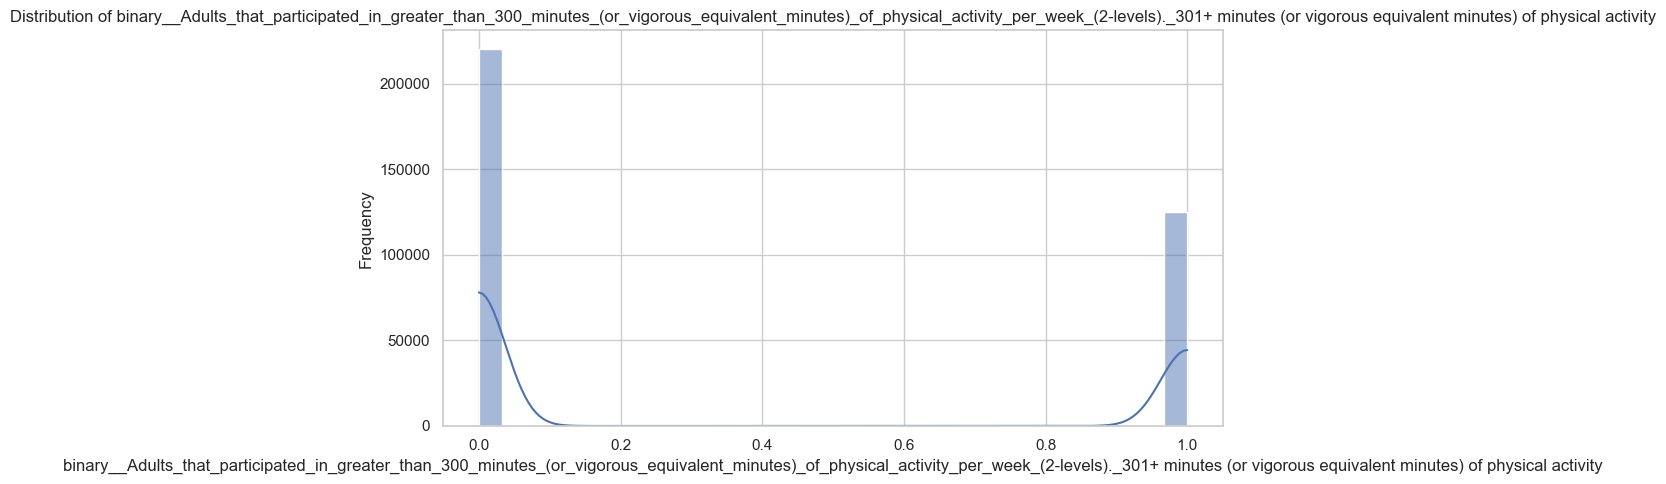

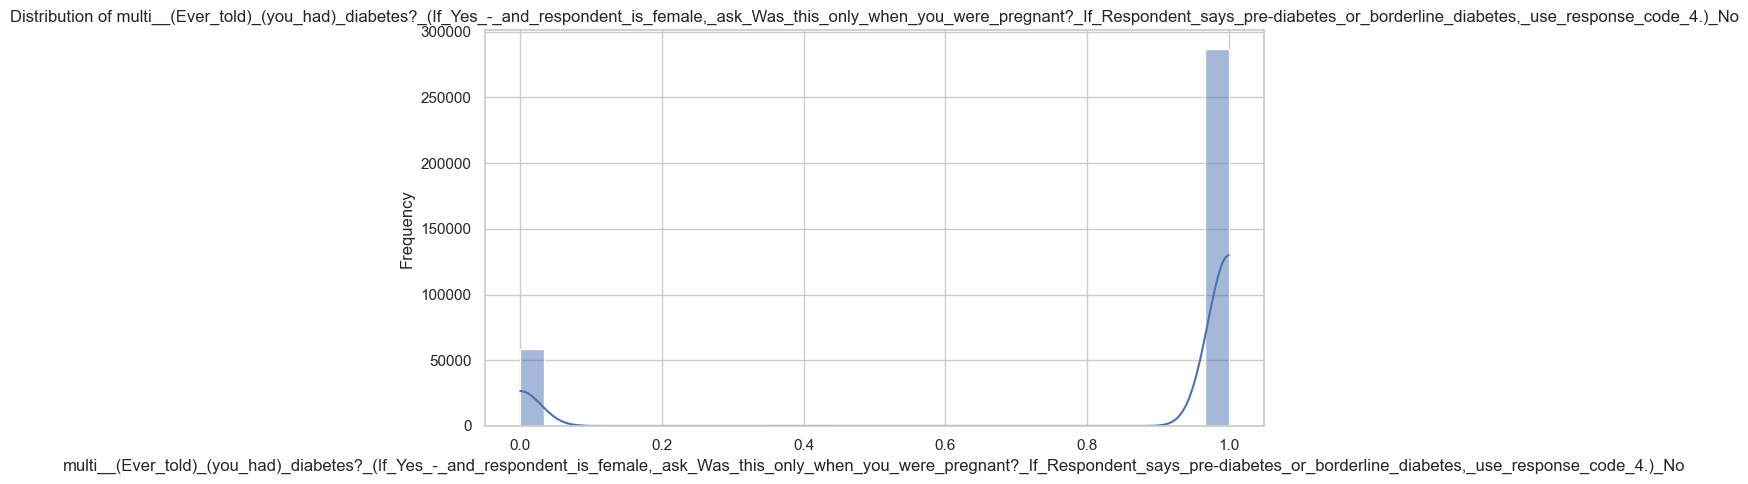

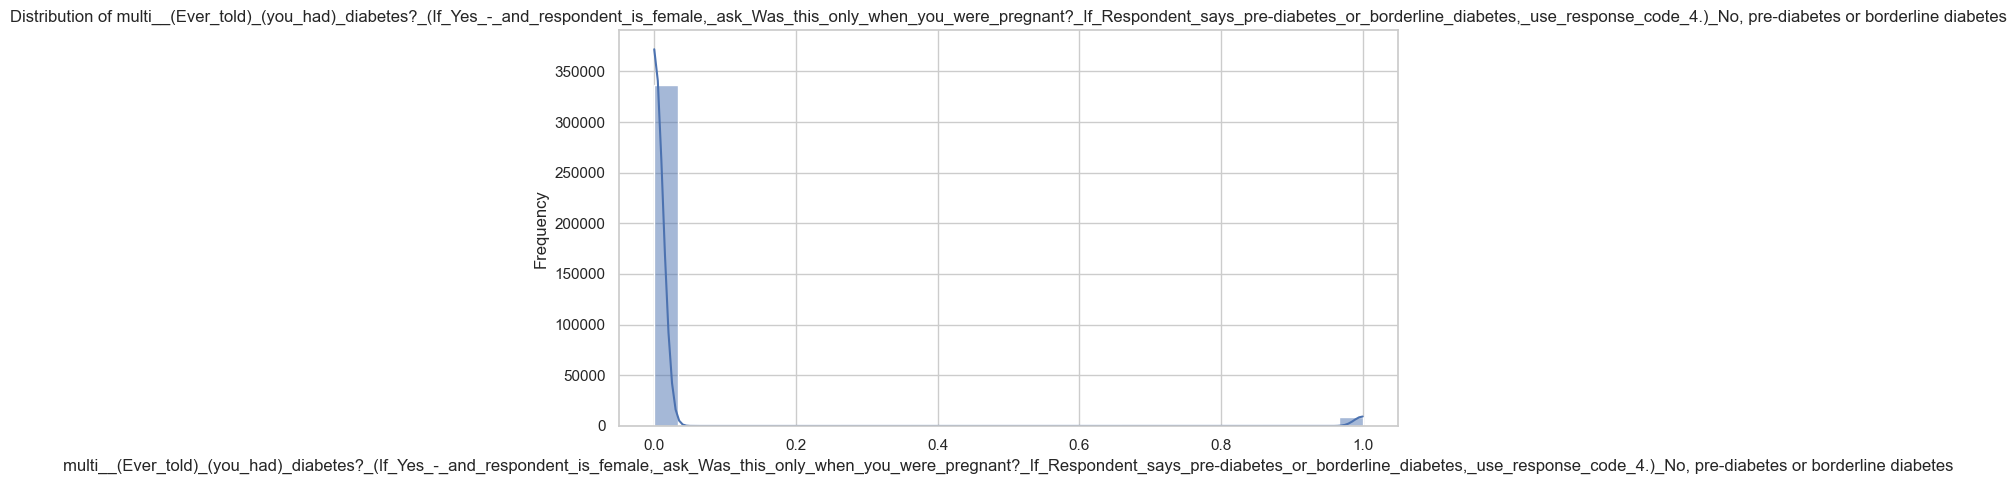

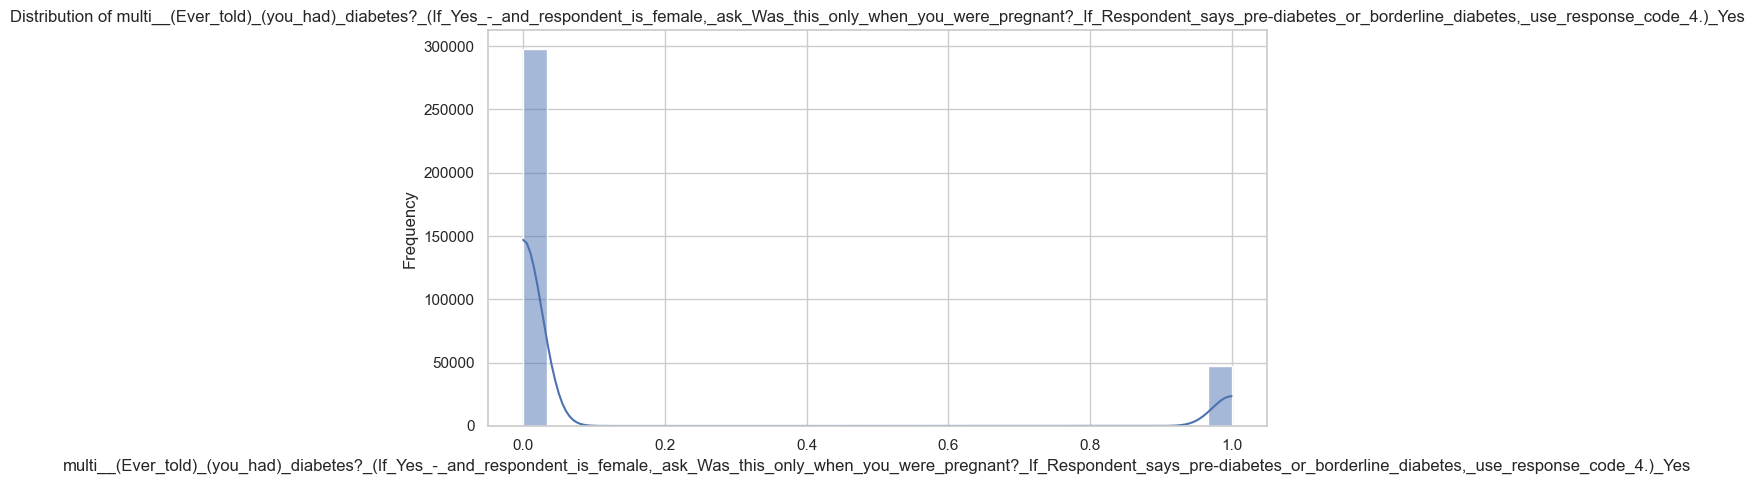

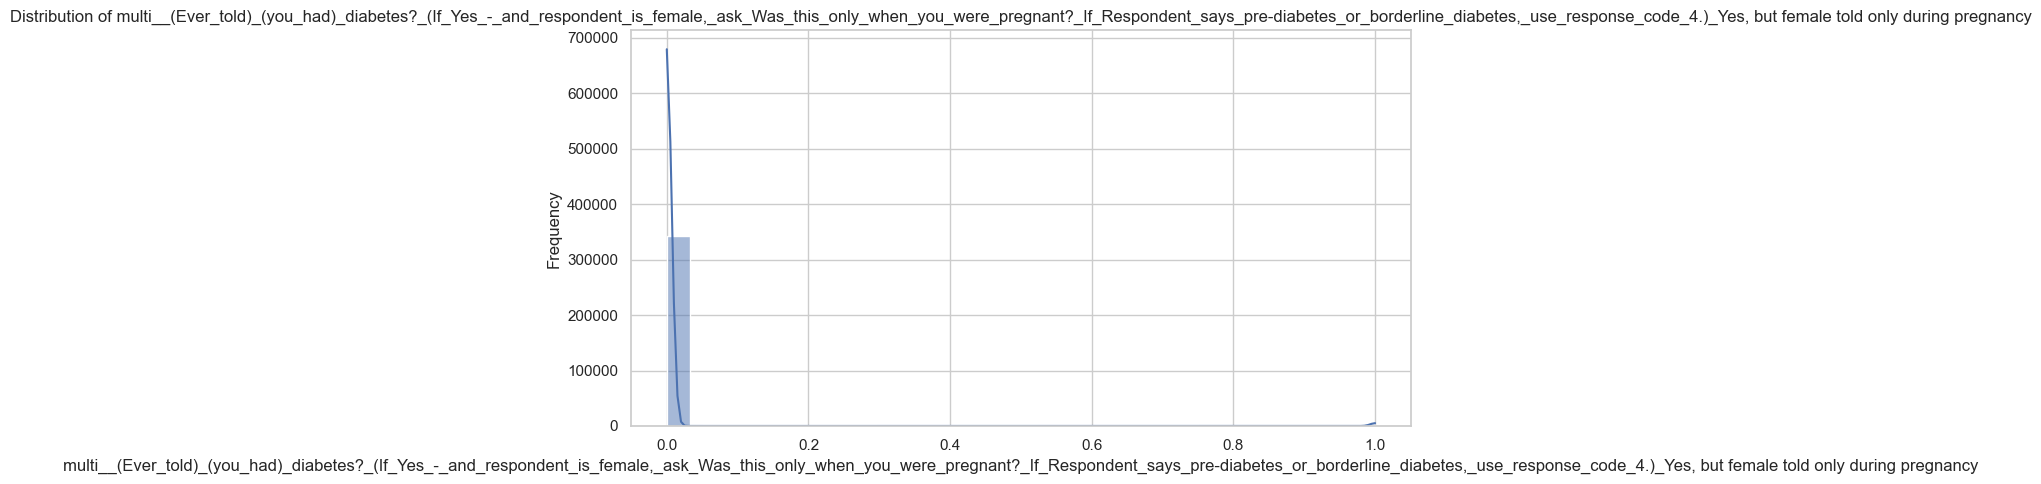

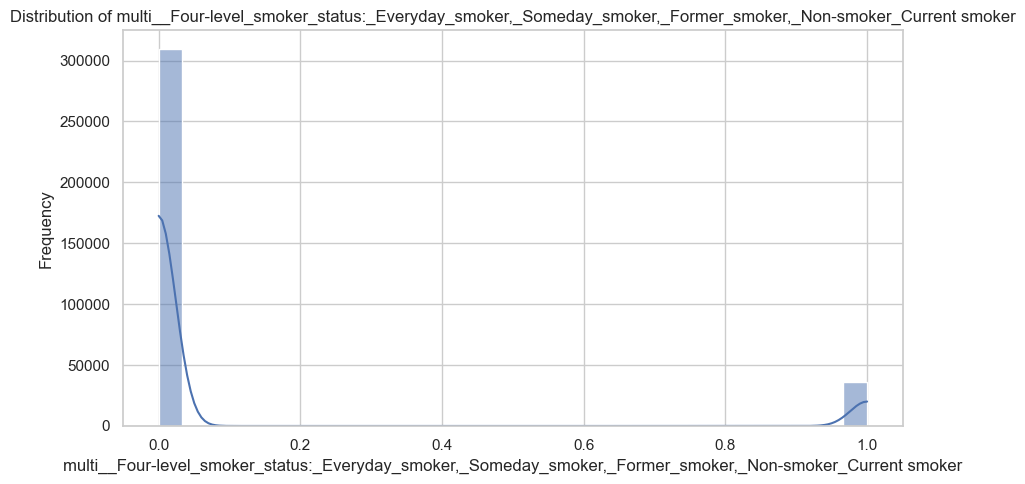

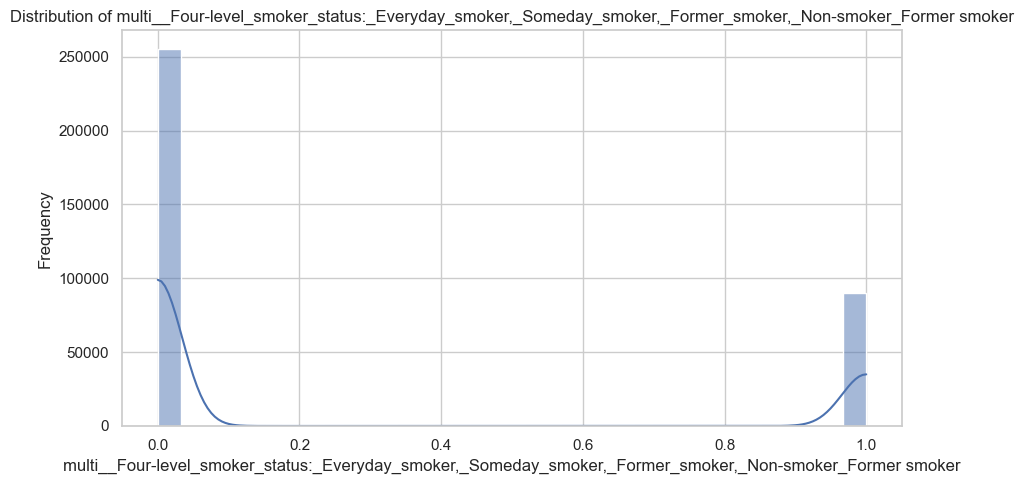

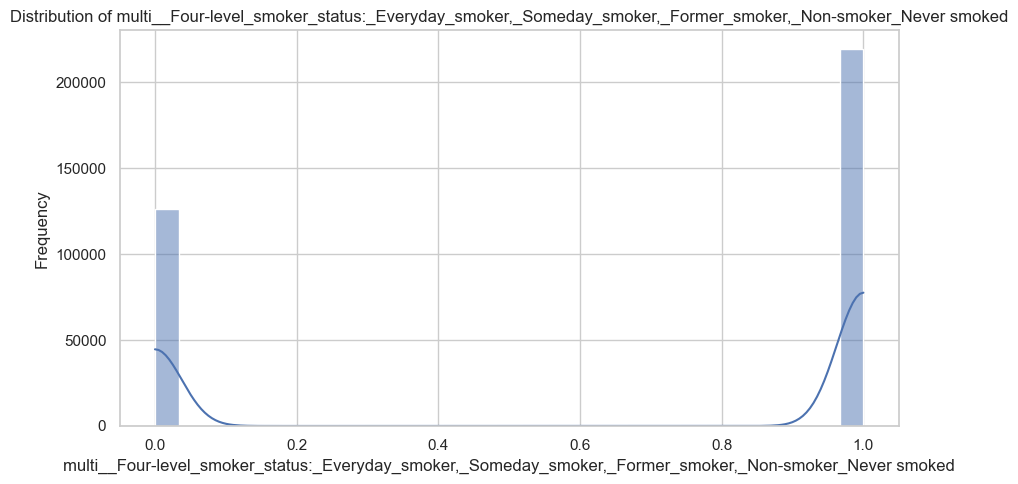

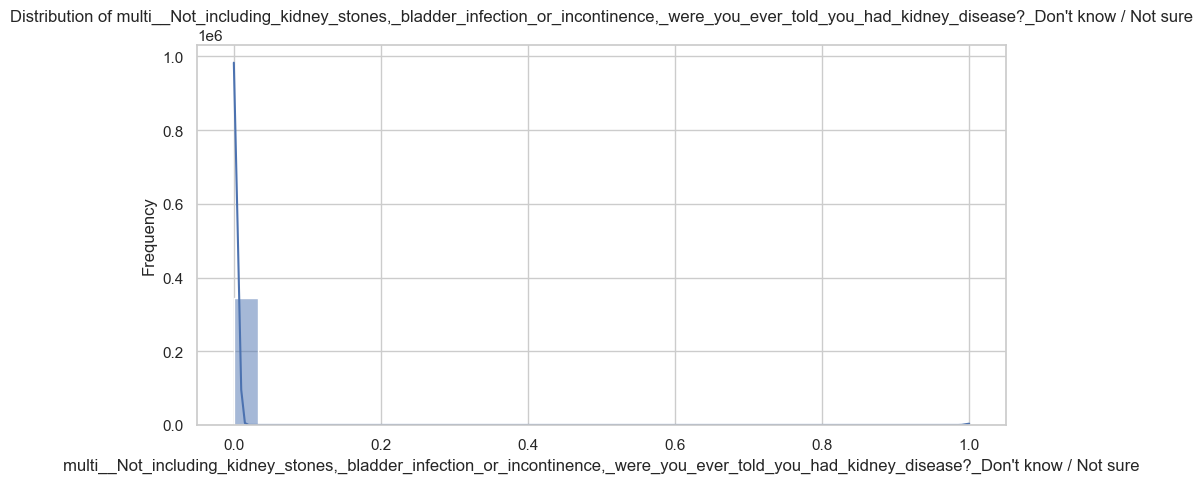

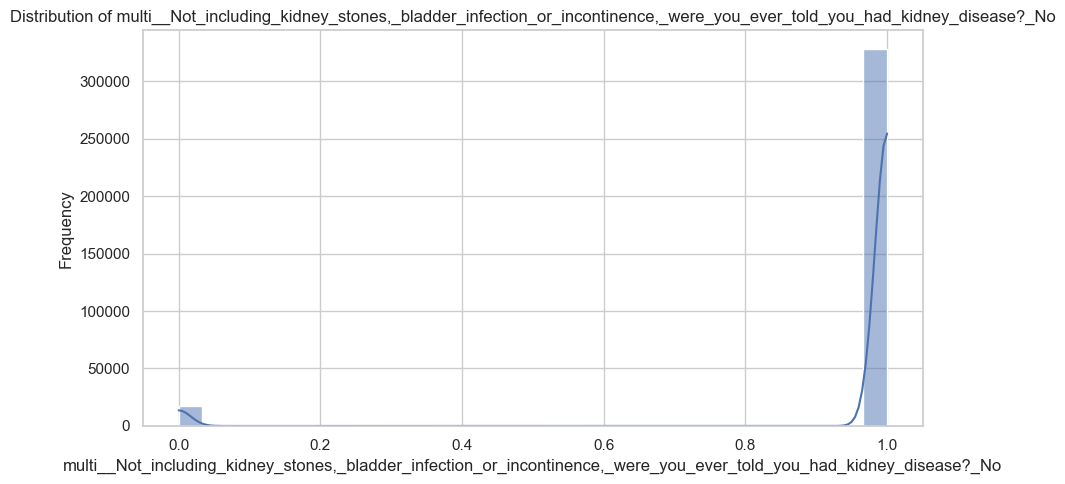

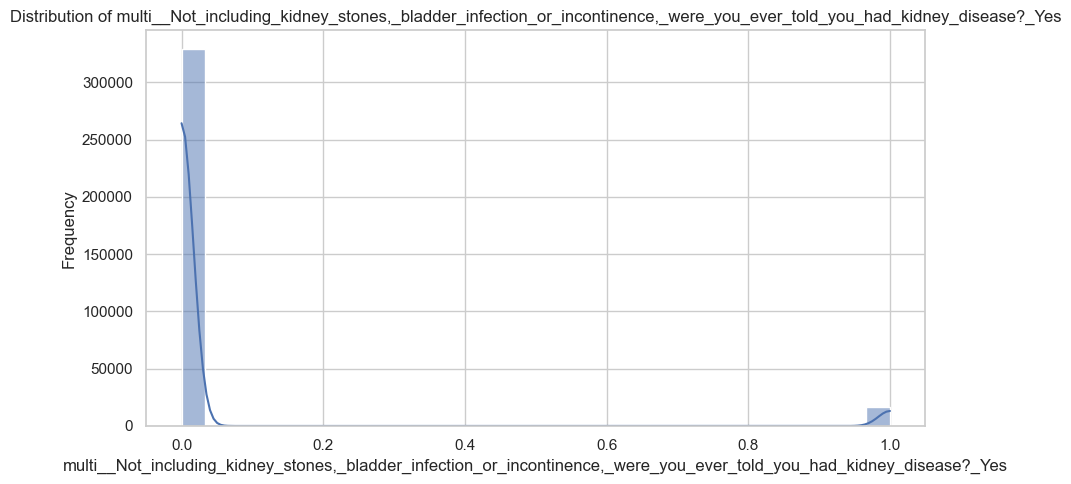

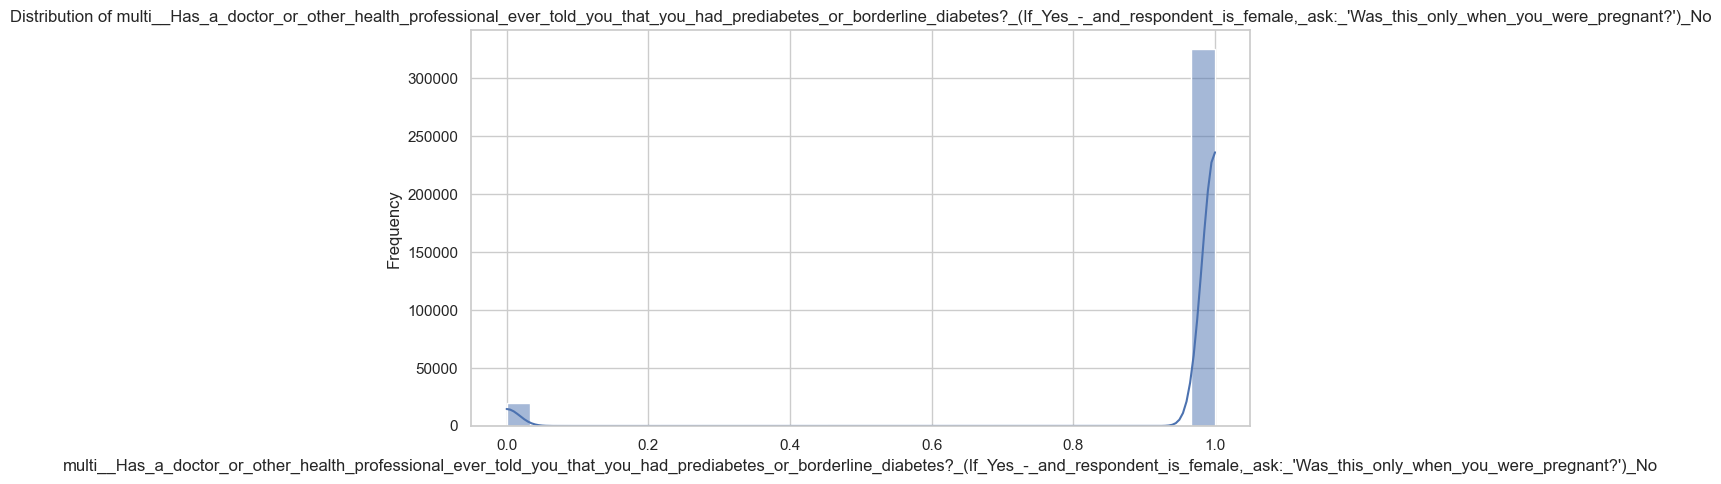

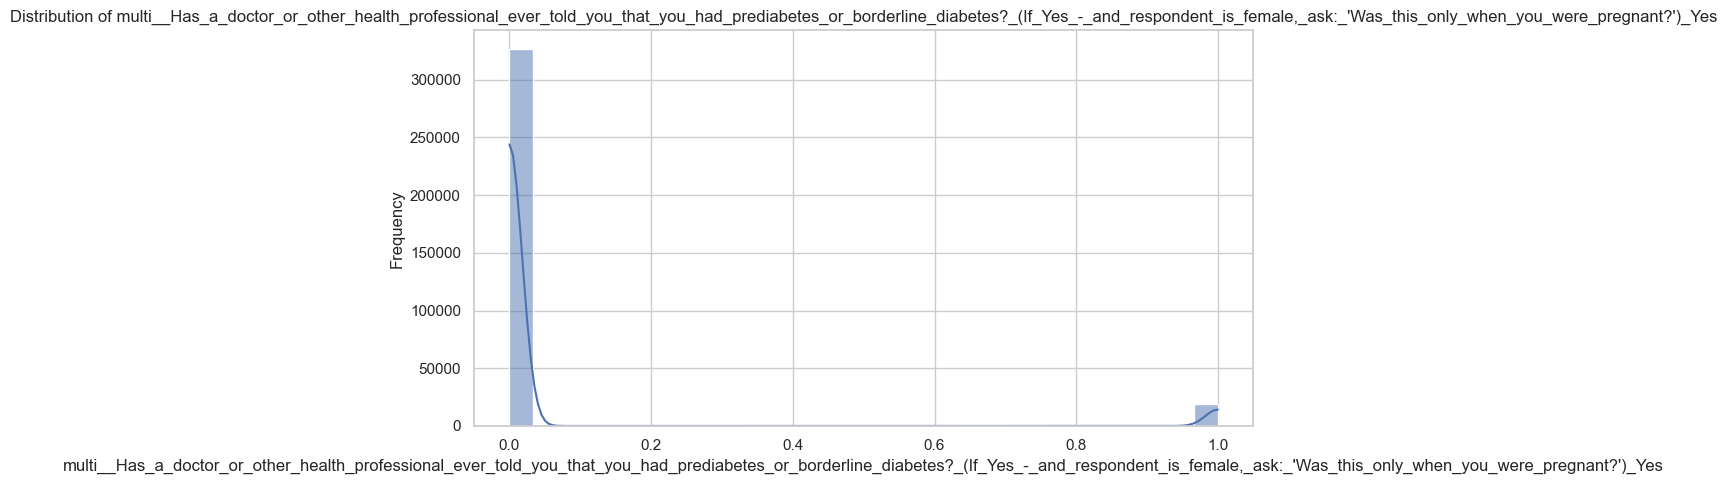

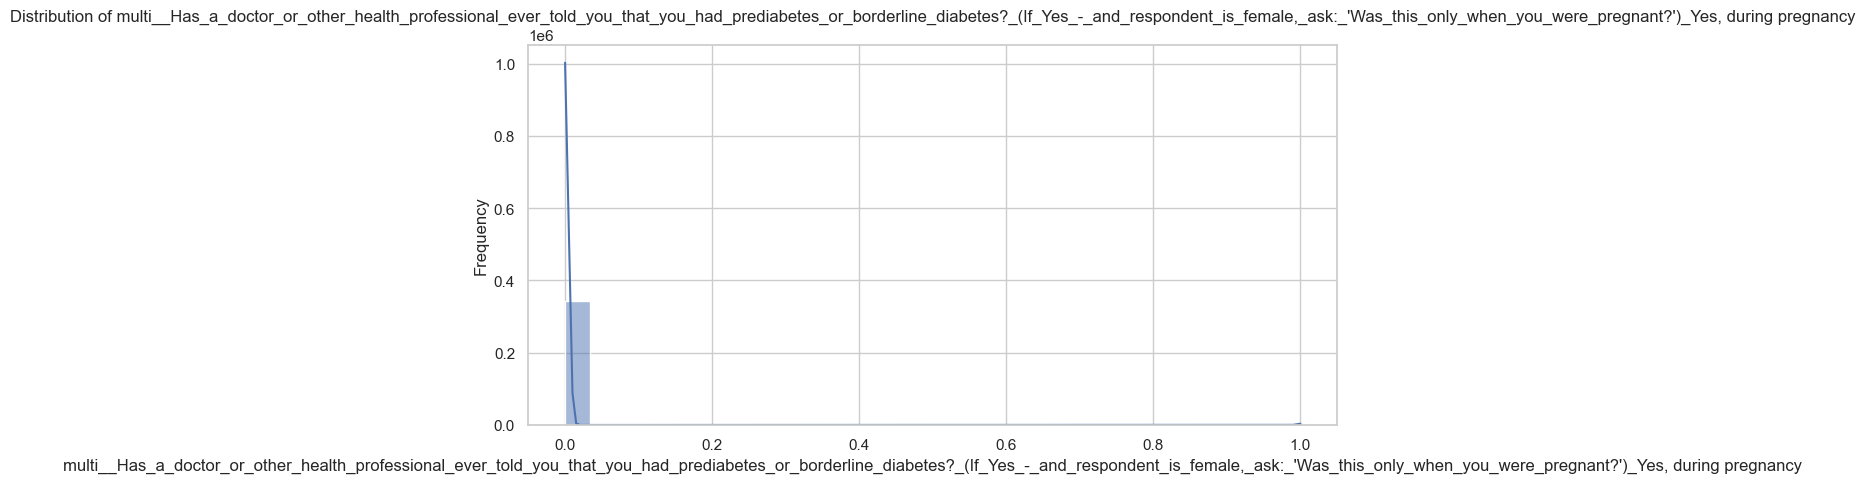

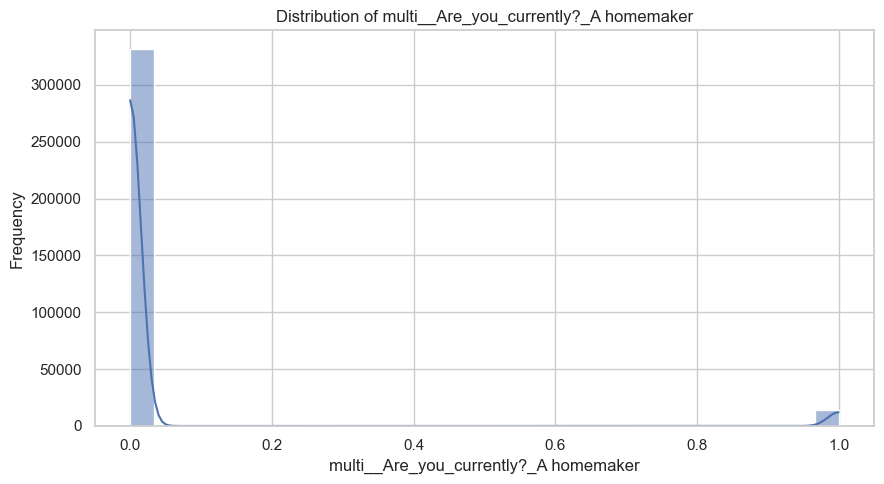

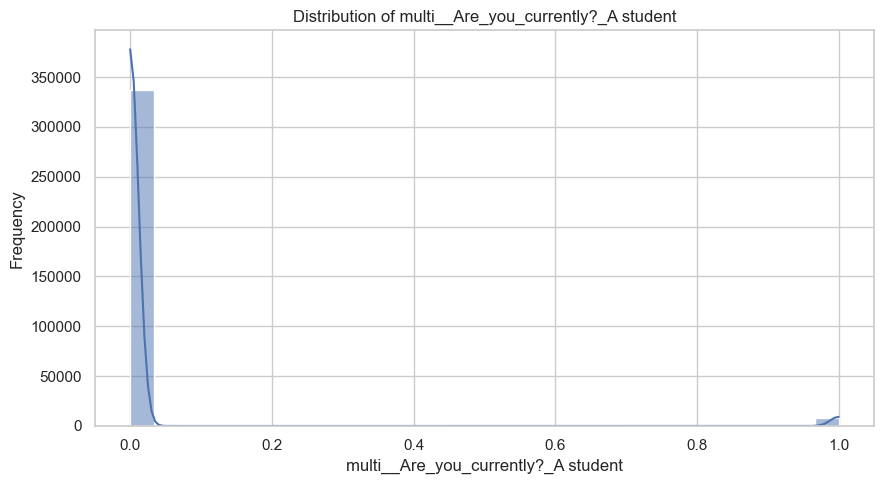

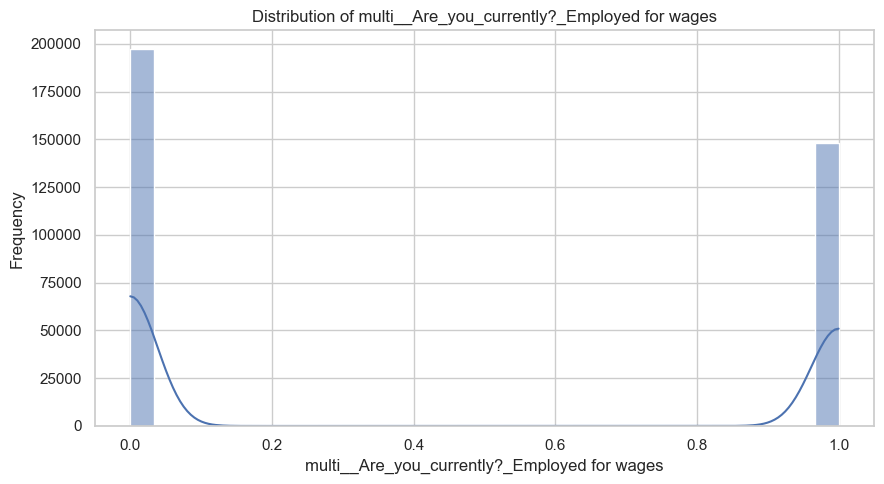

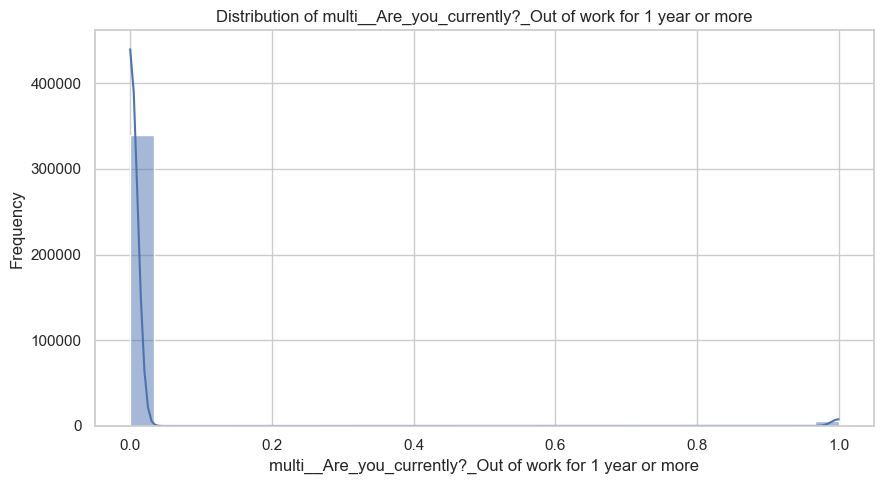

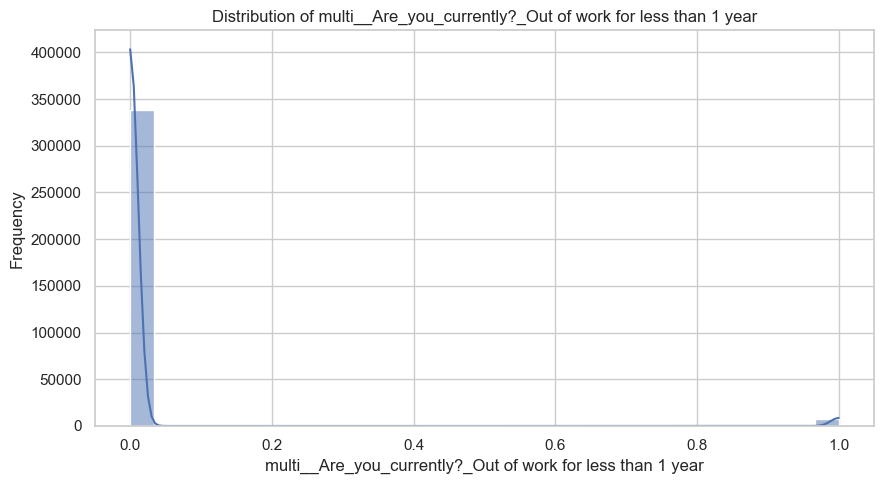

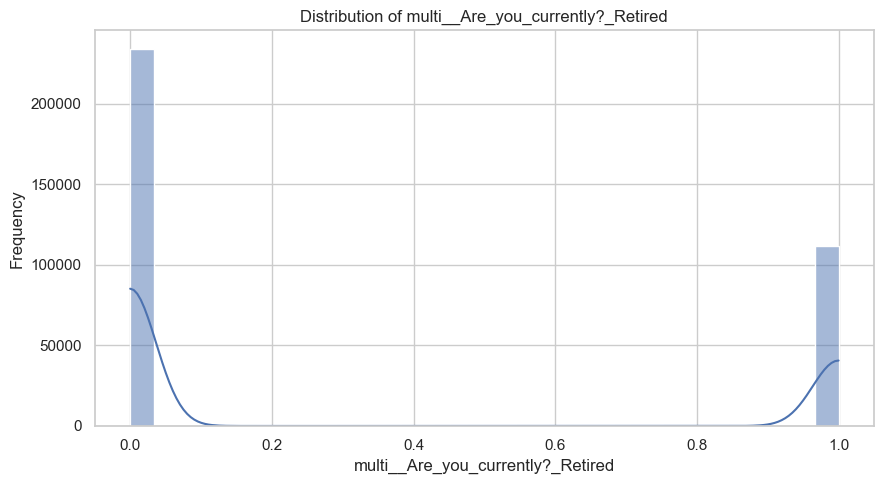

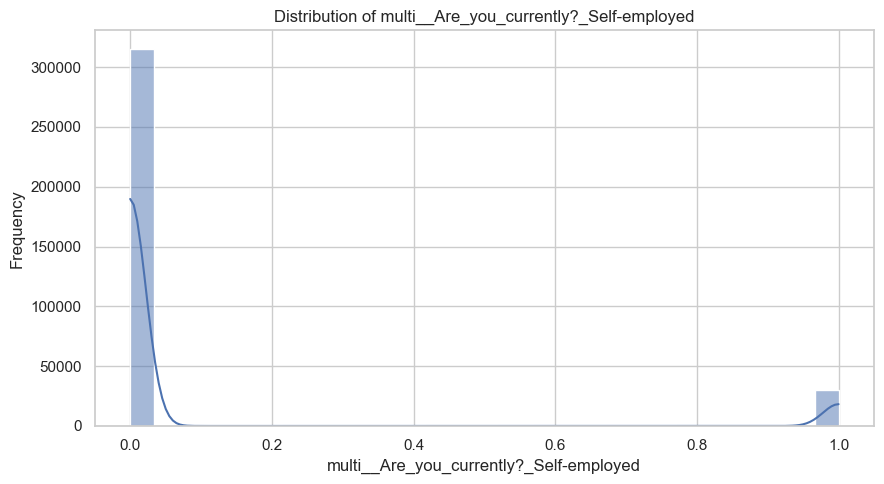

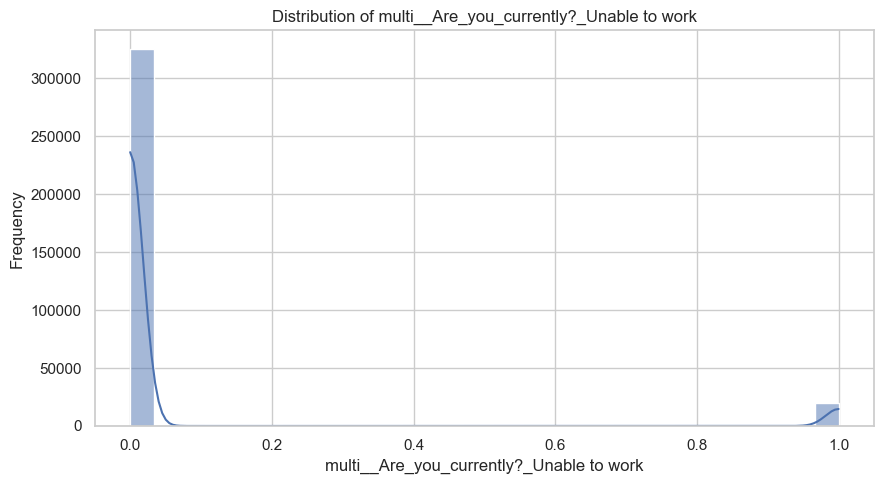

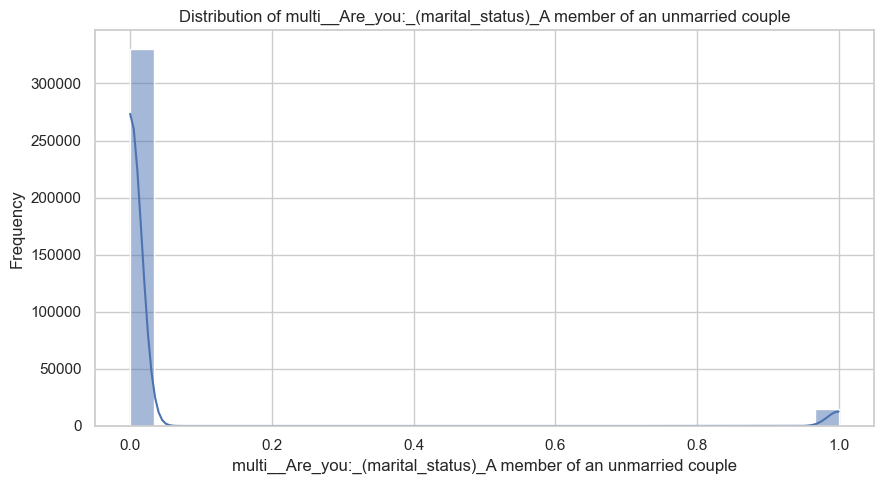

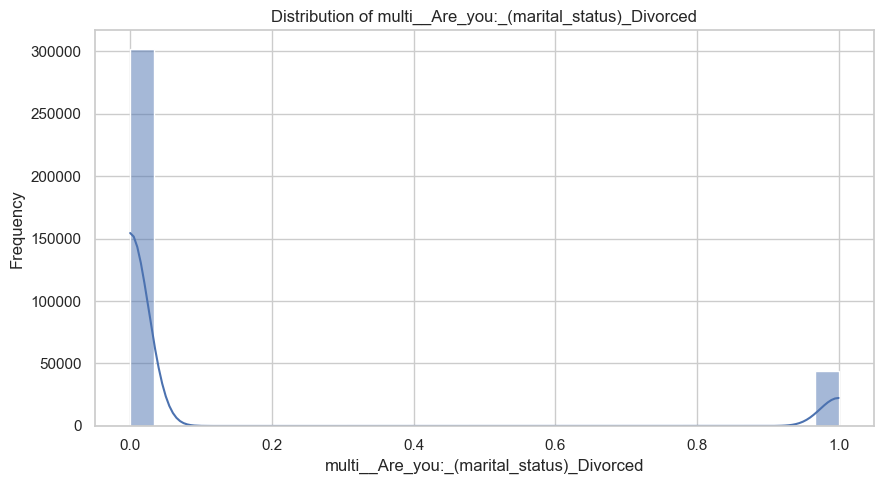

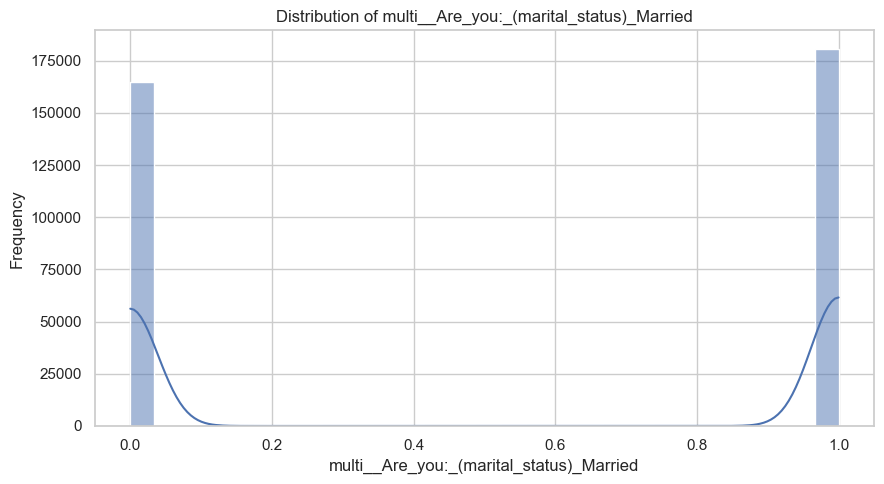

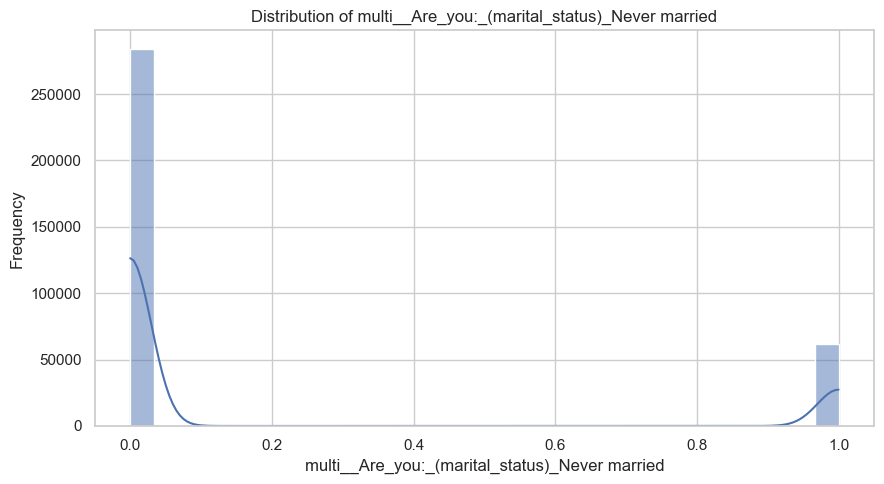

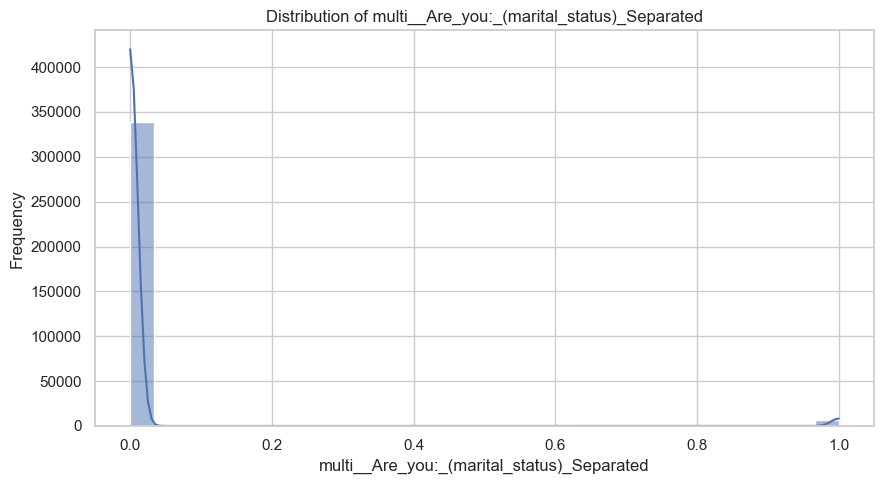

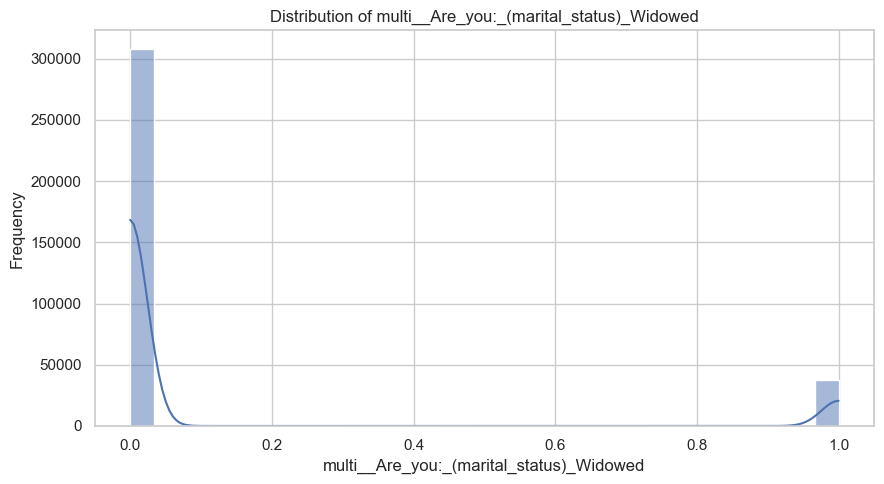

In [11]:
for col in numeric_feature_cols:
    plt.figure(figsize=(9, 5))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


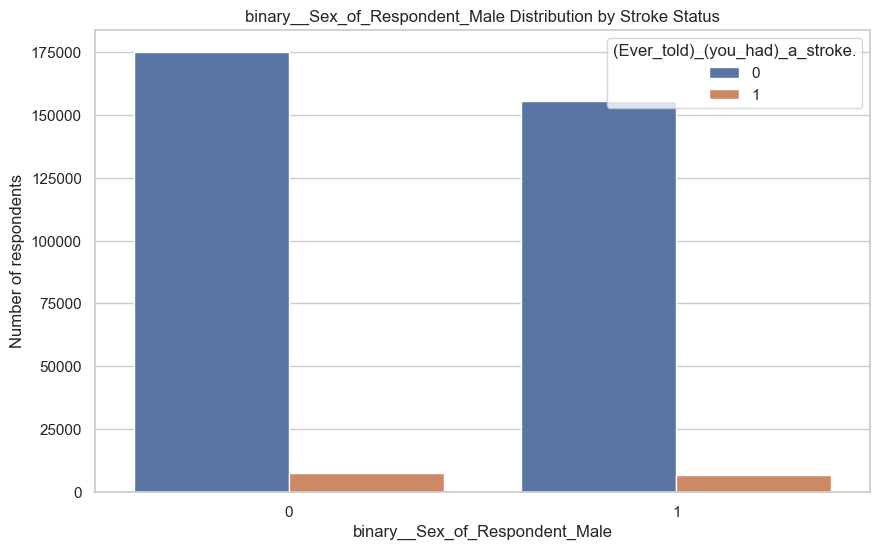

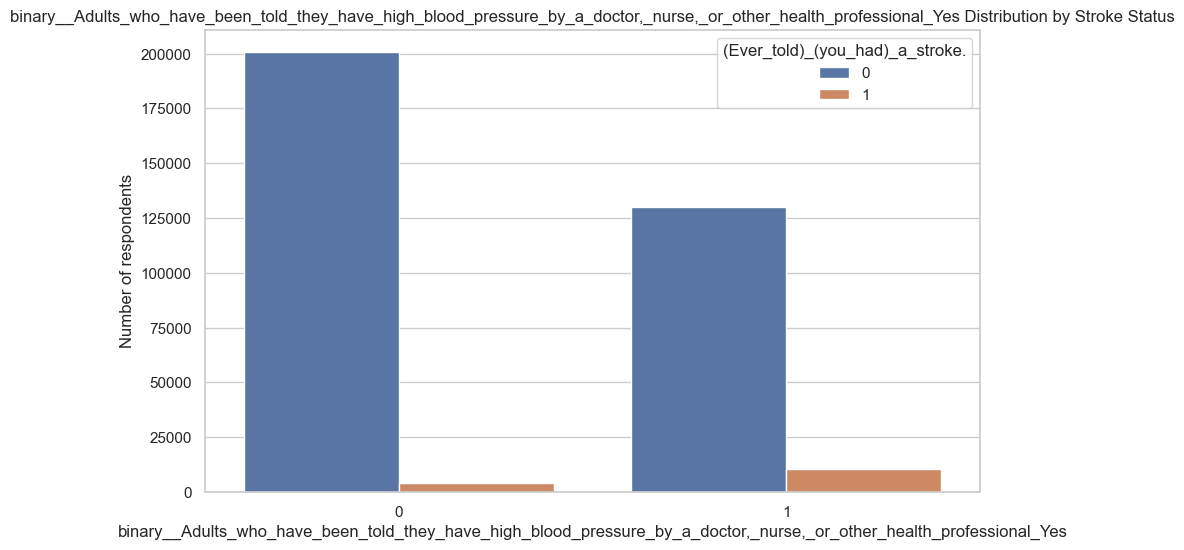

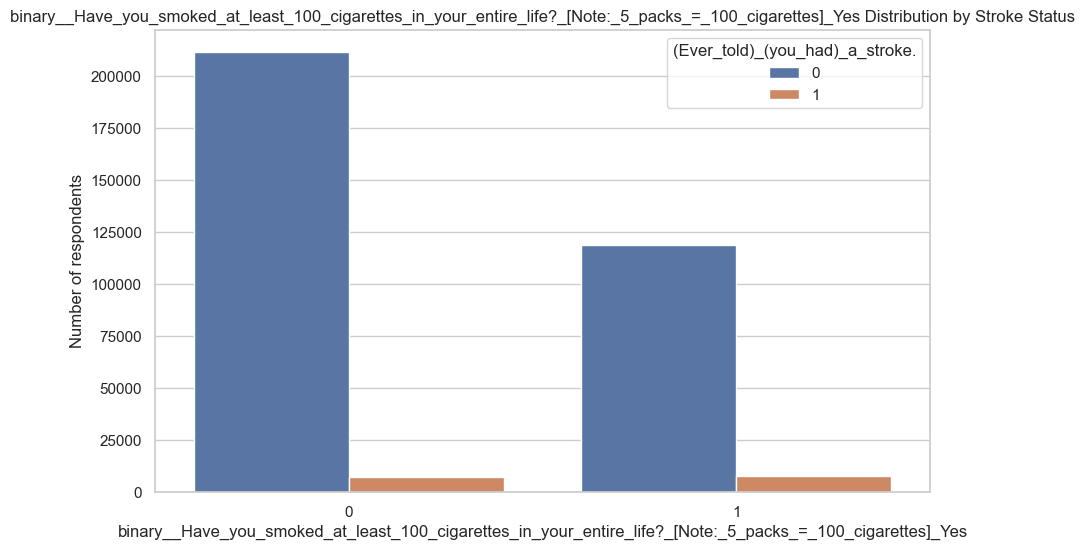

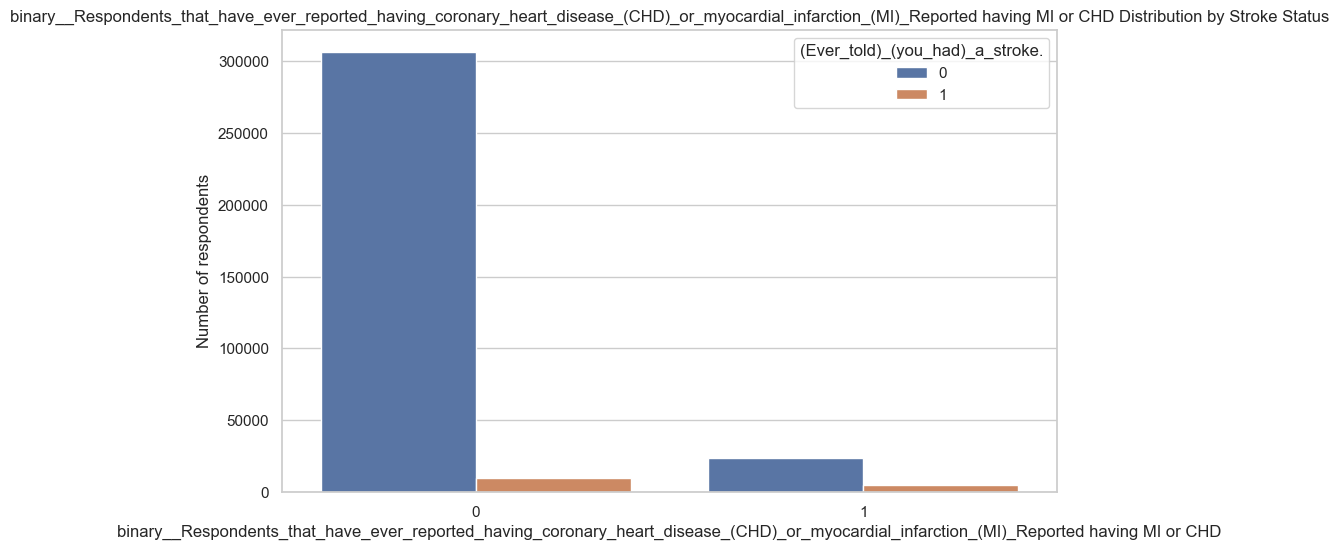

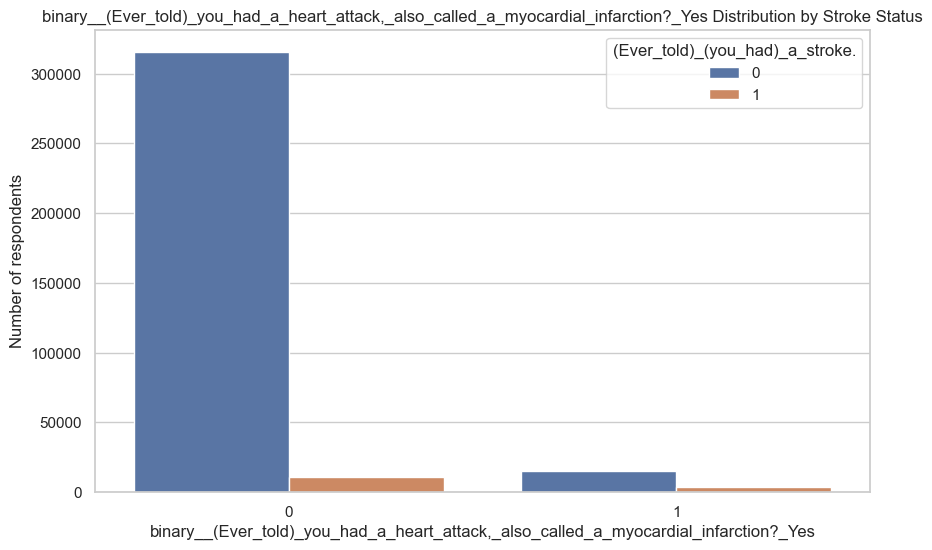

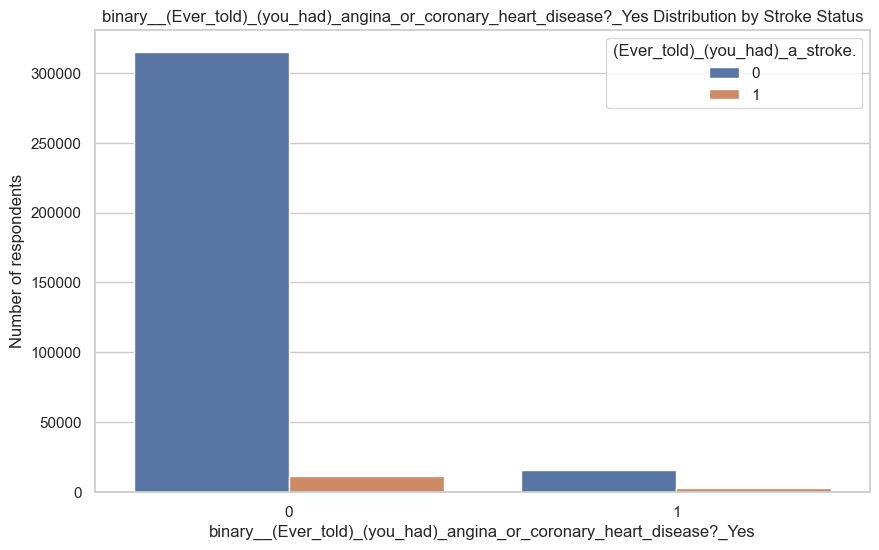

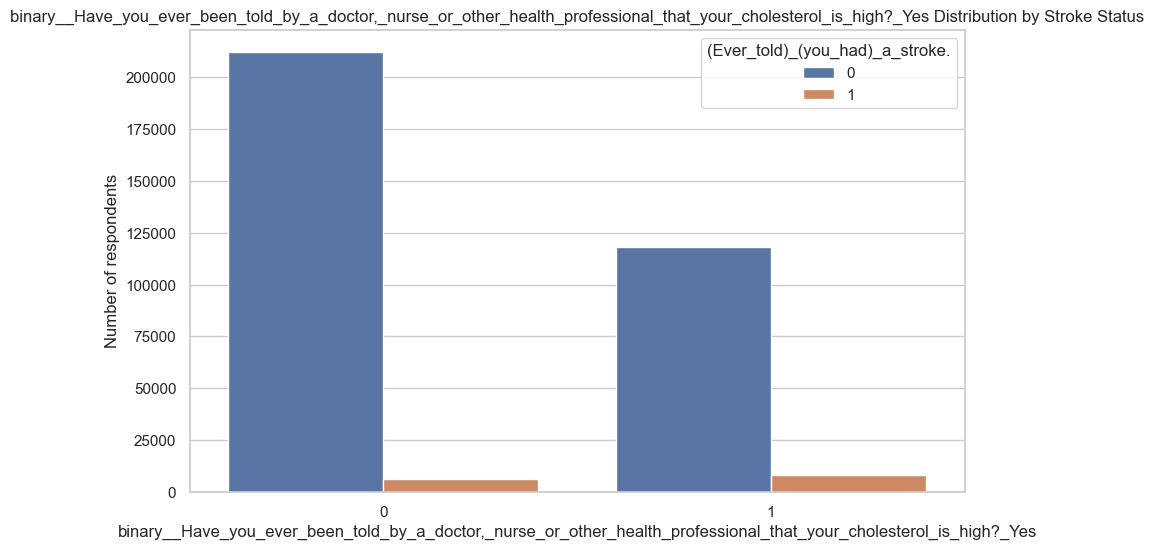

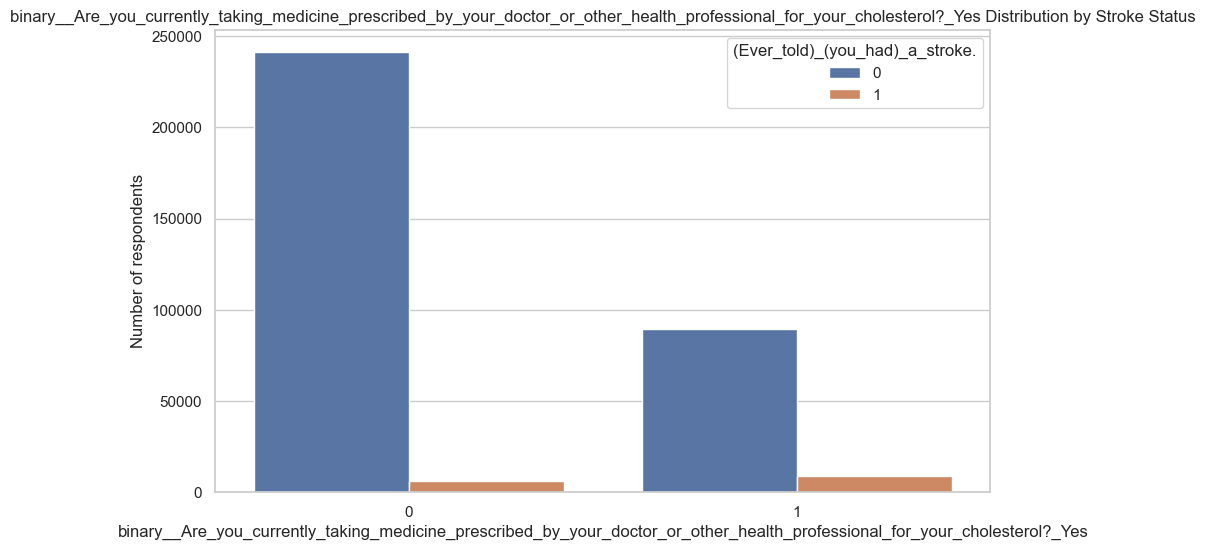

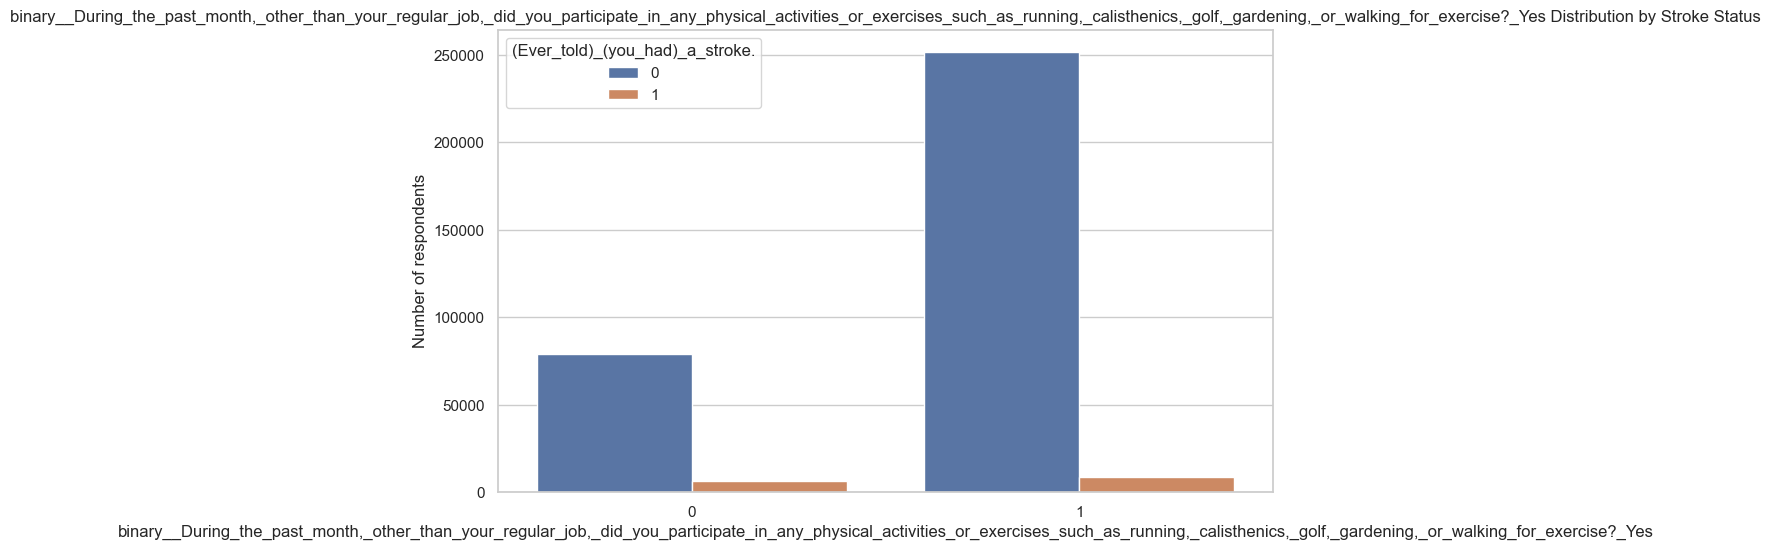

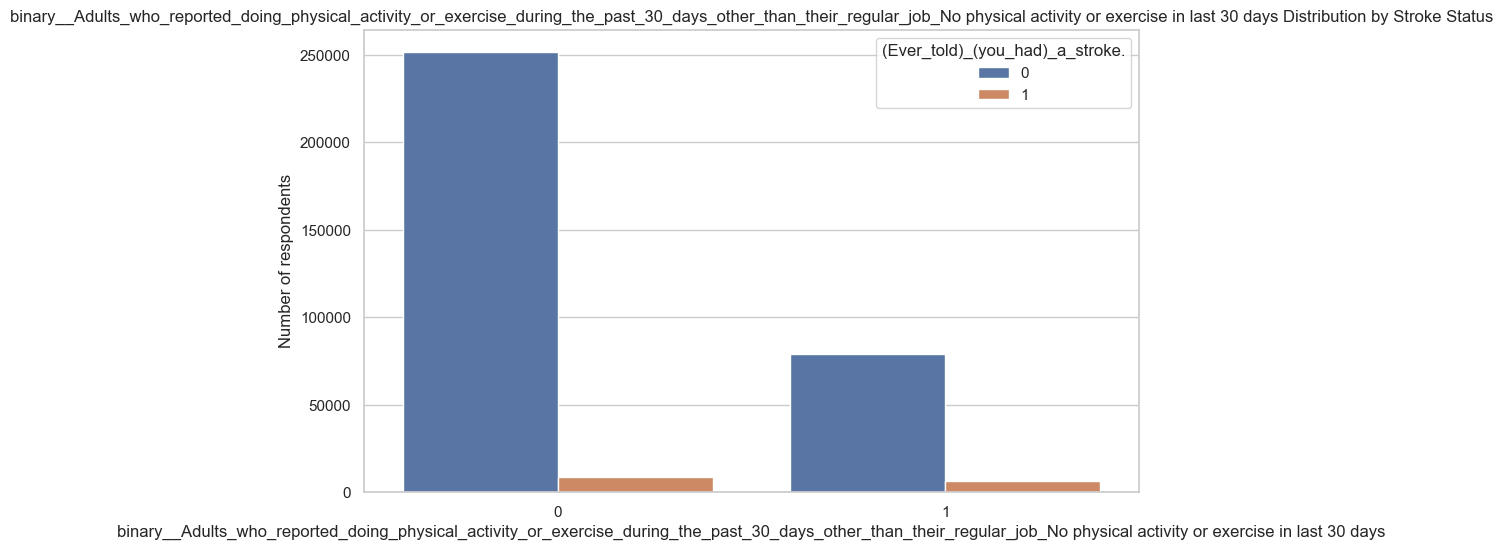

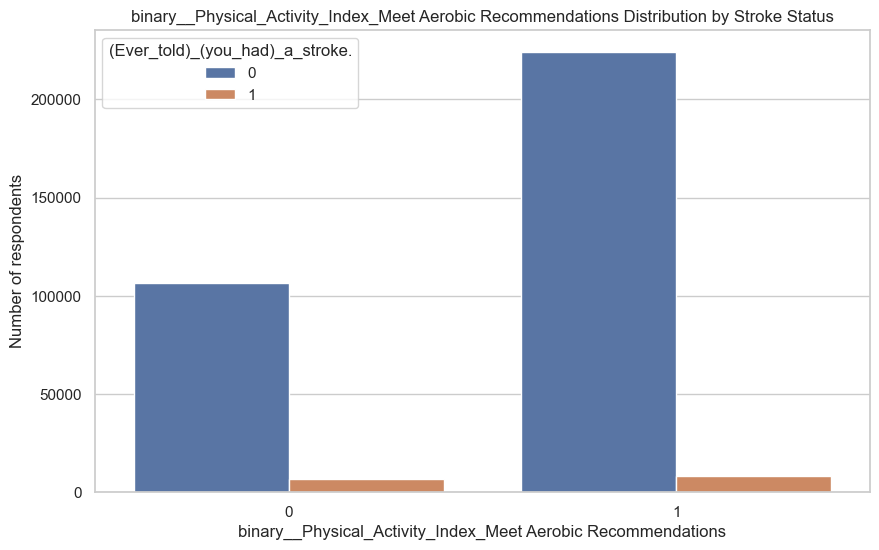

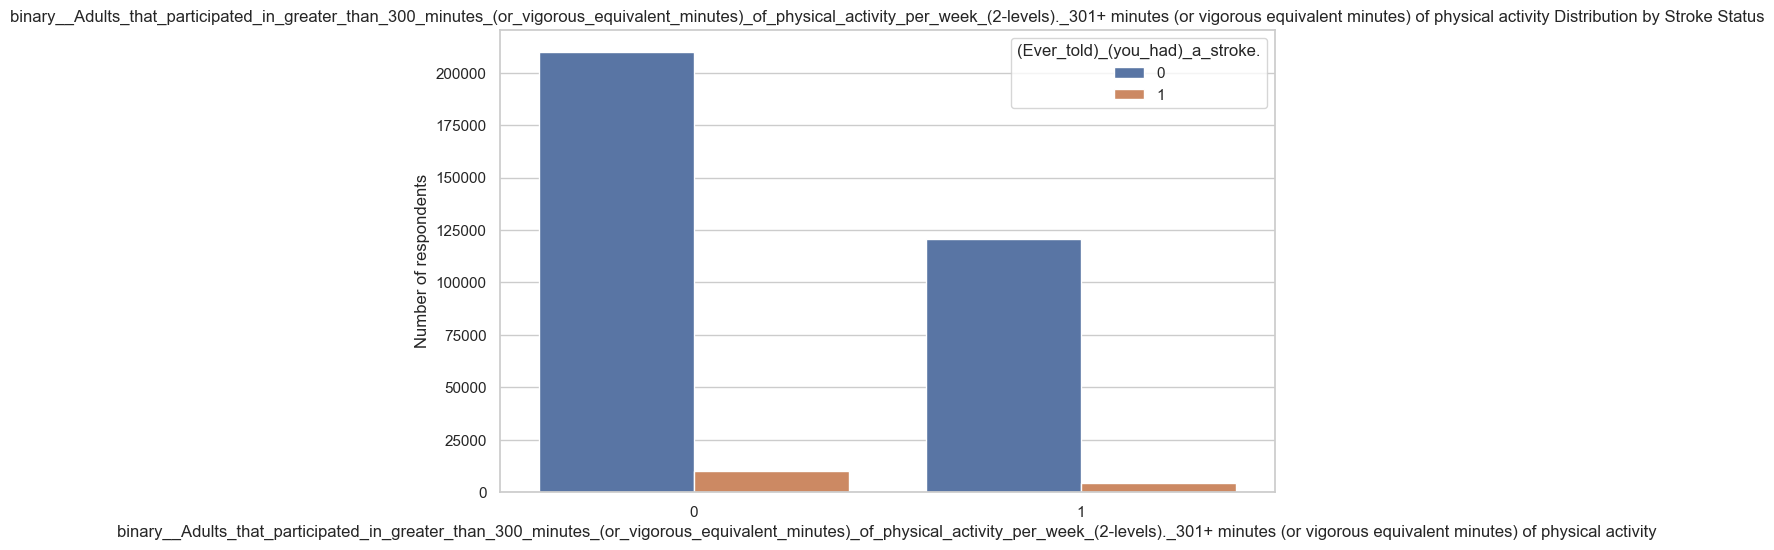

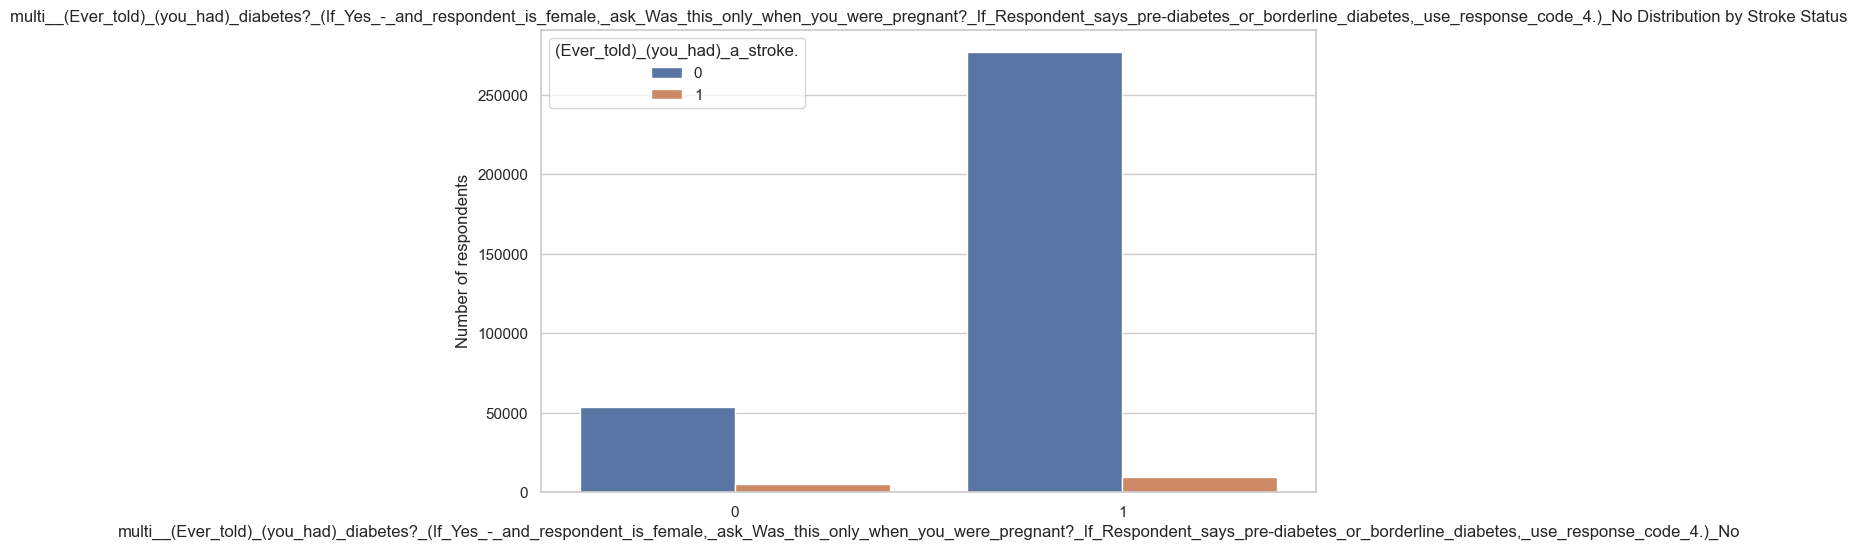

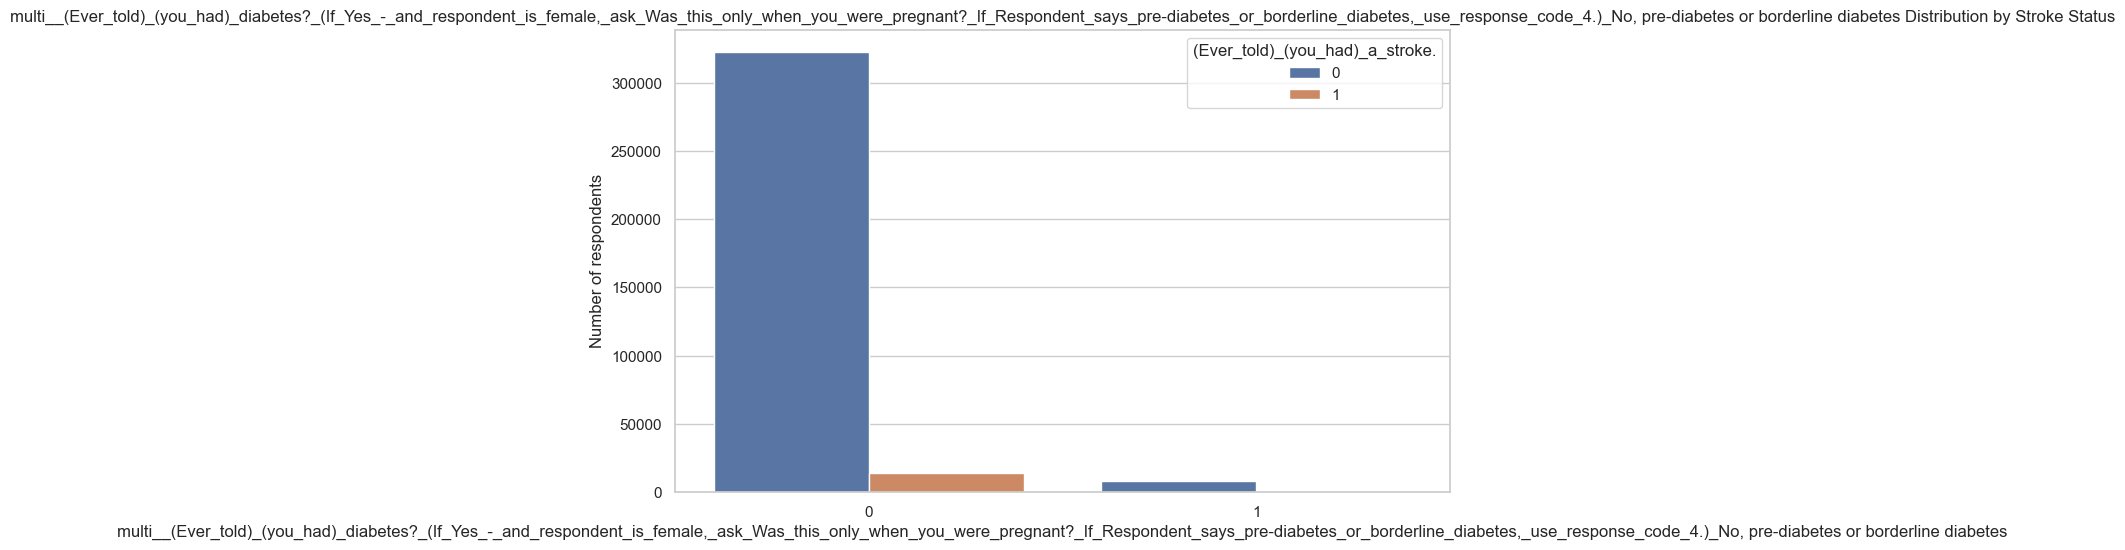

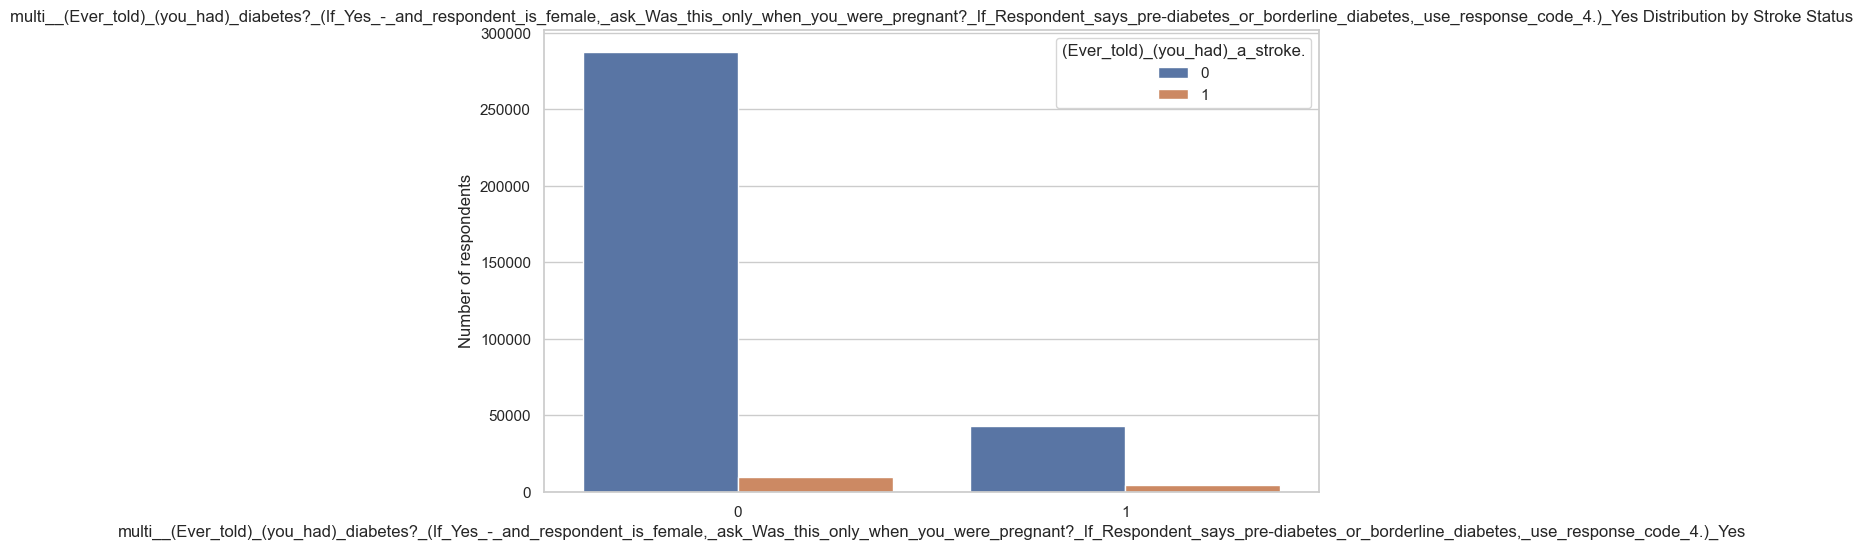

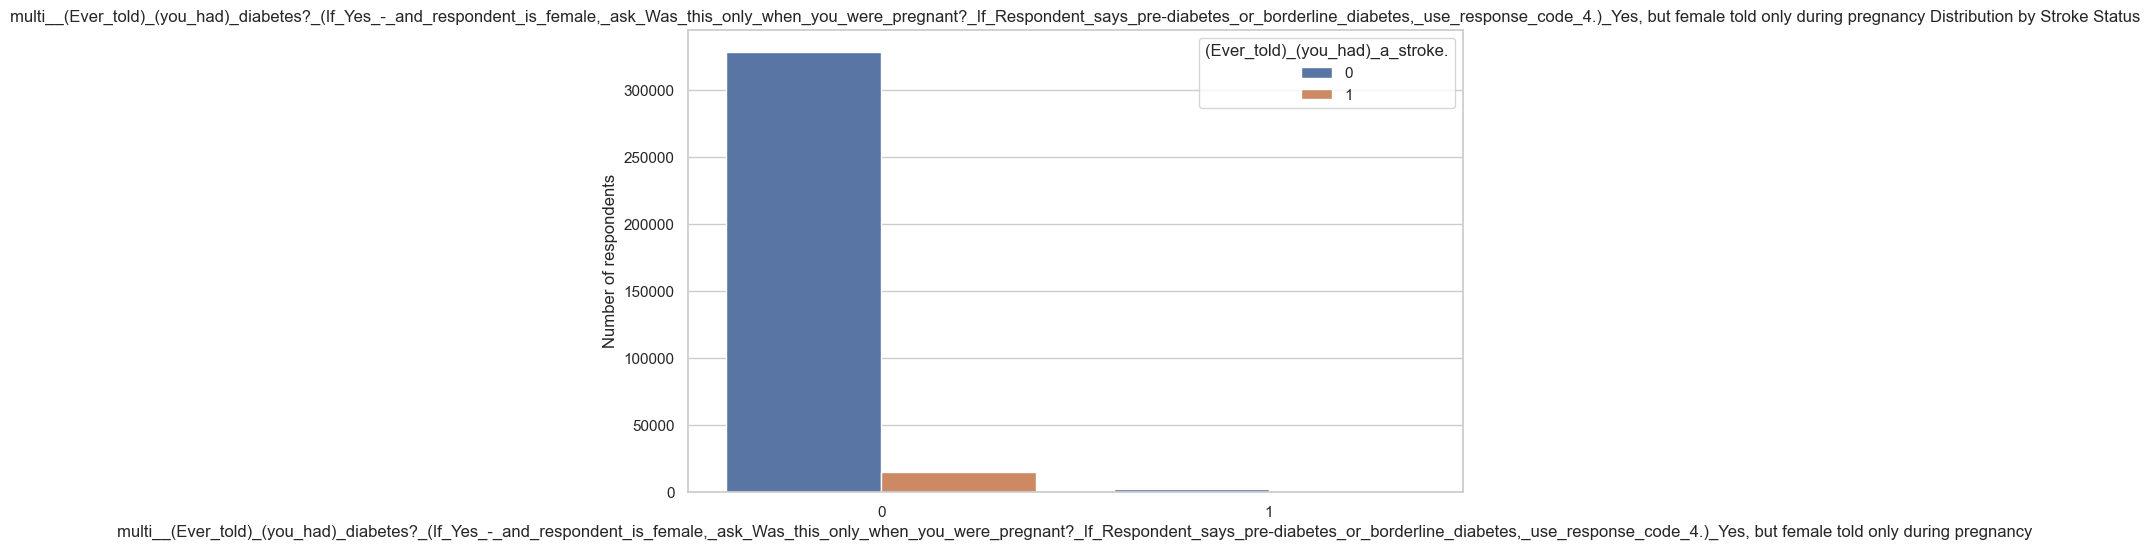

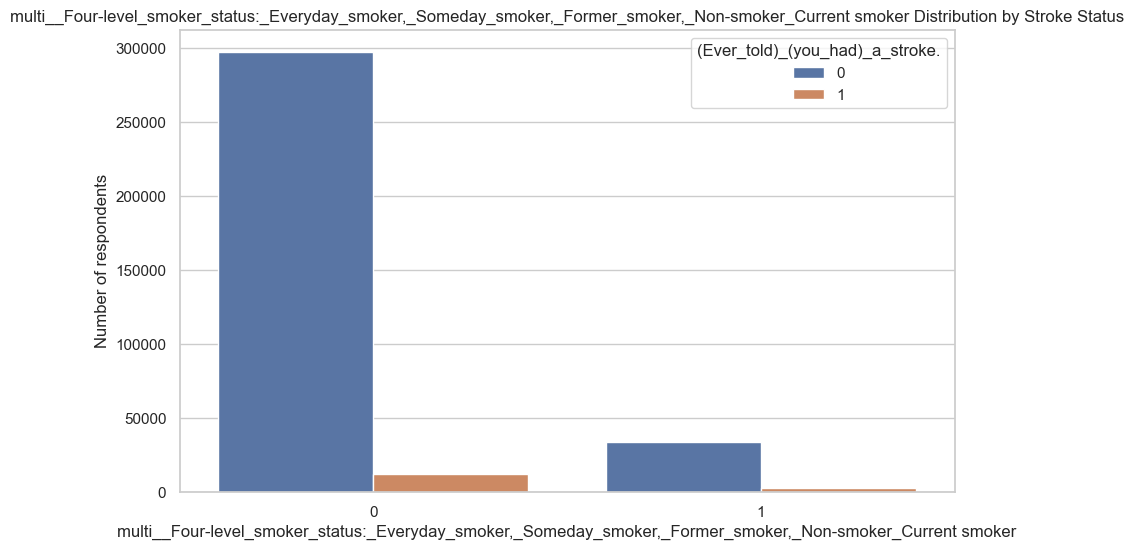

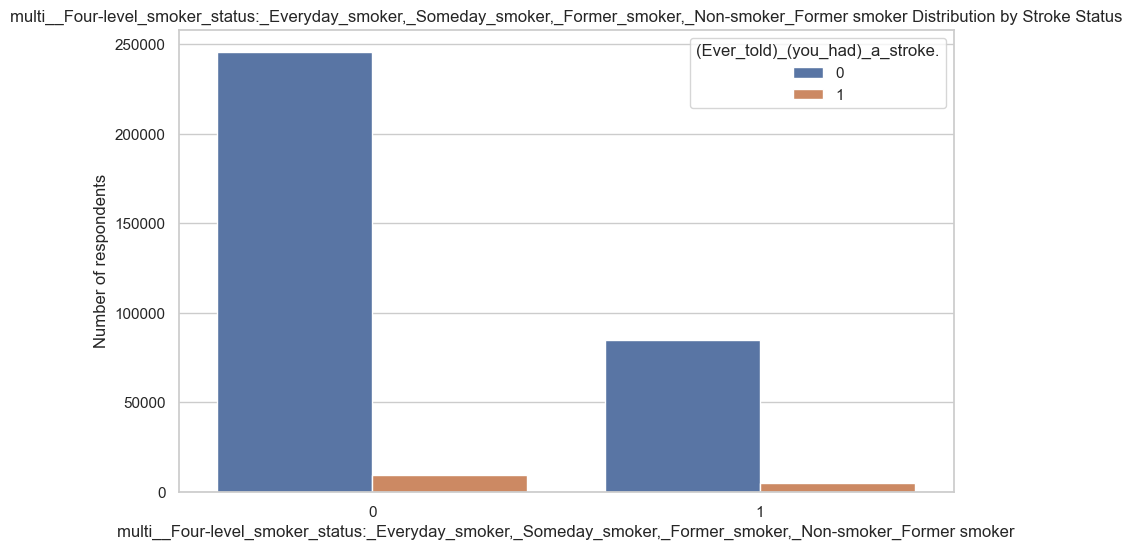

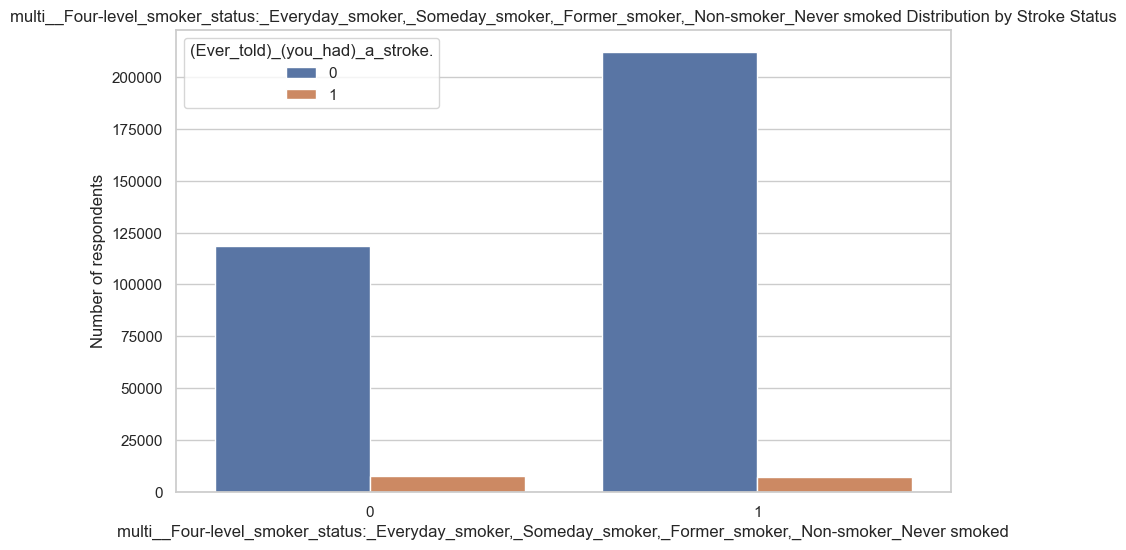

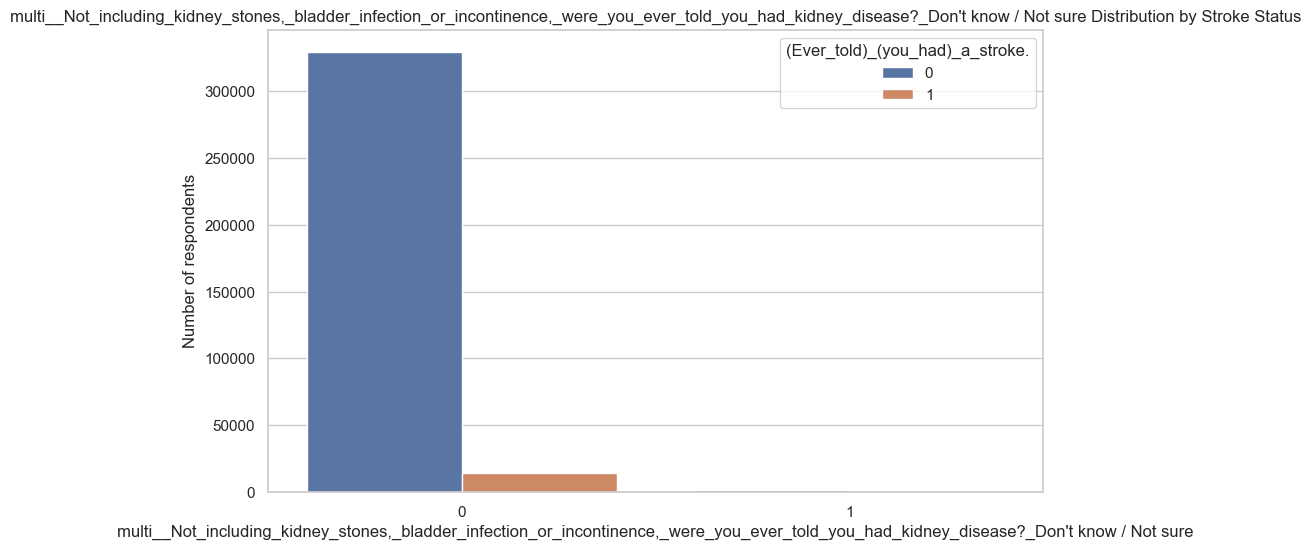

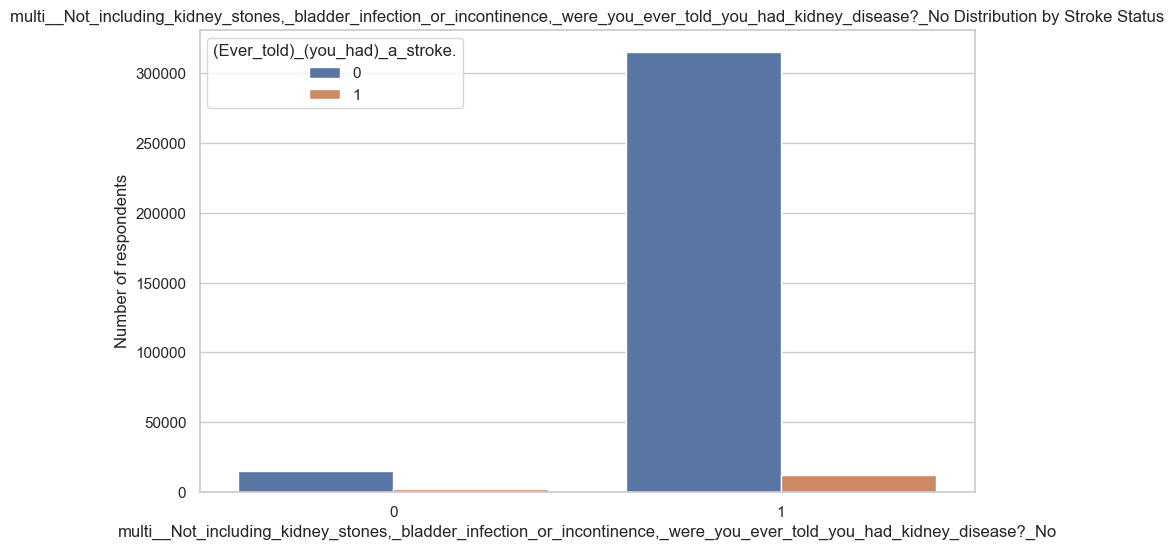

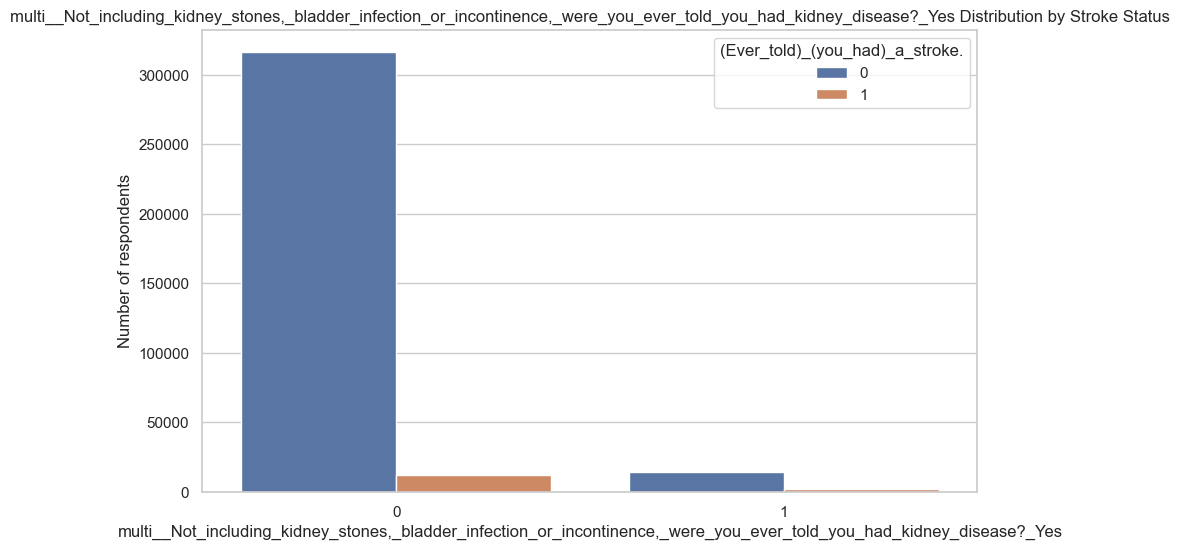

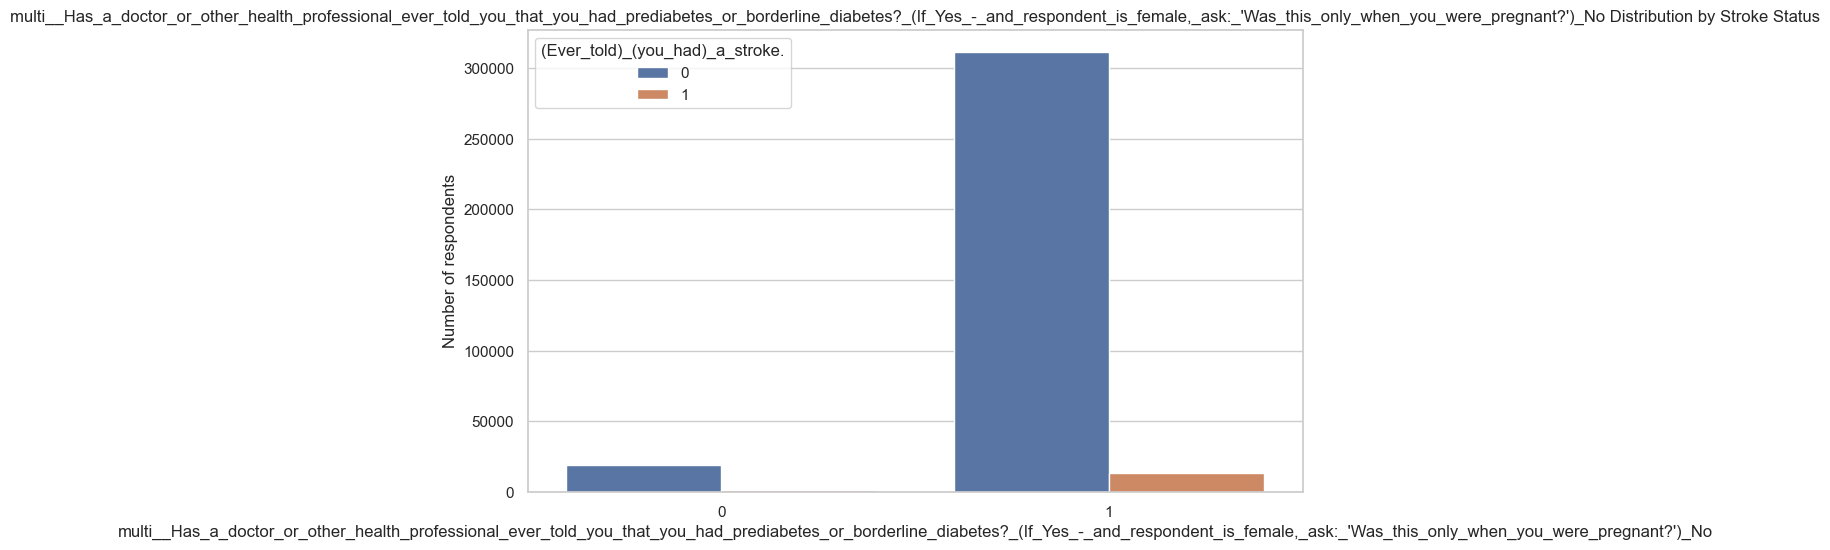

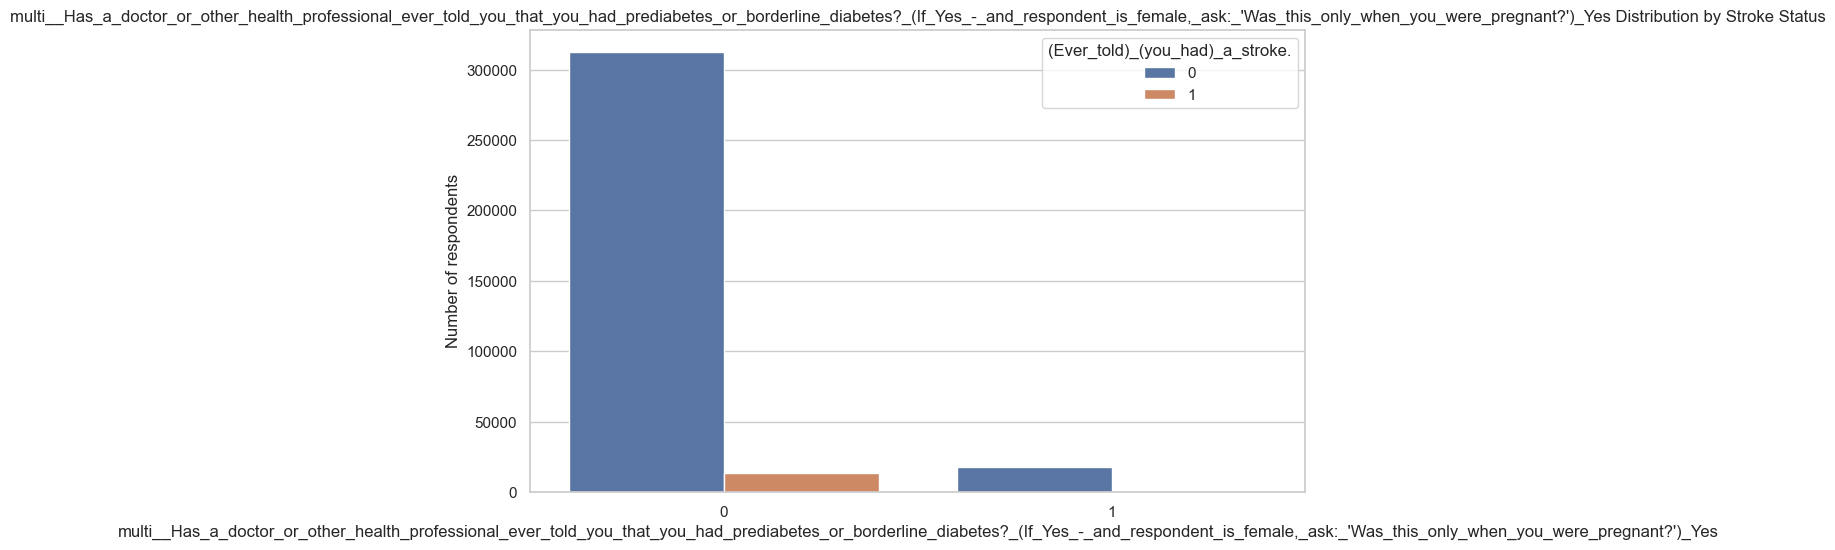

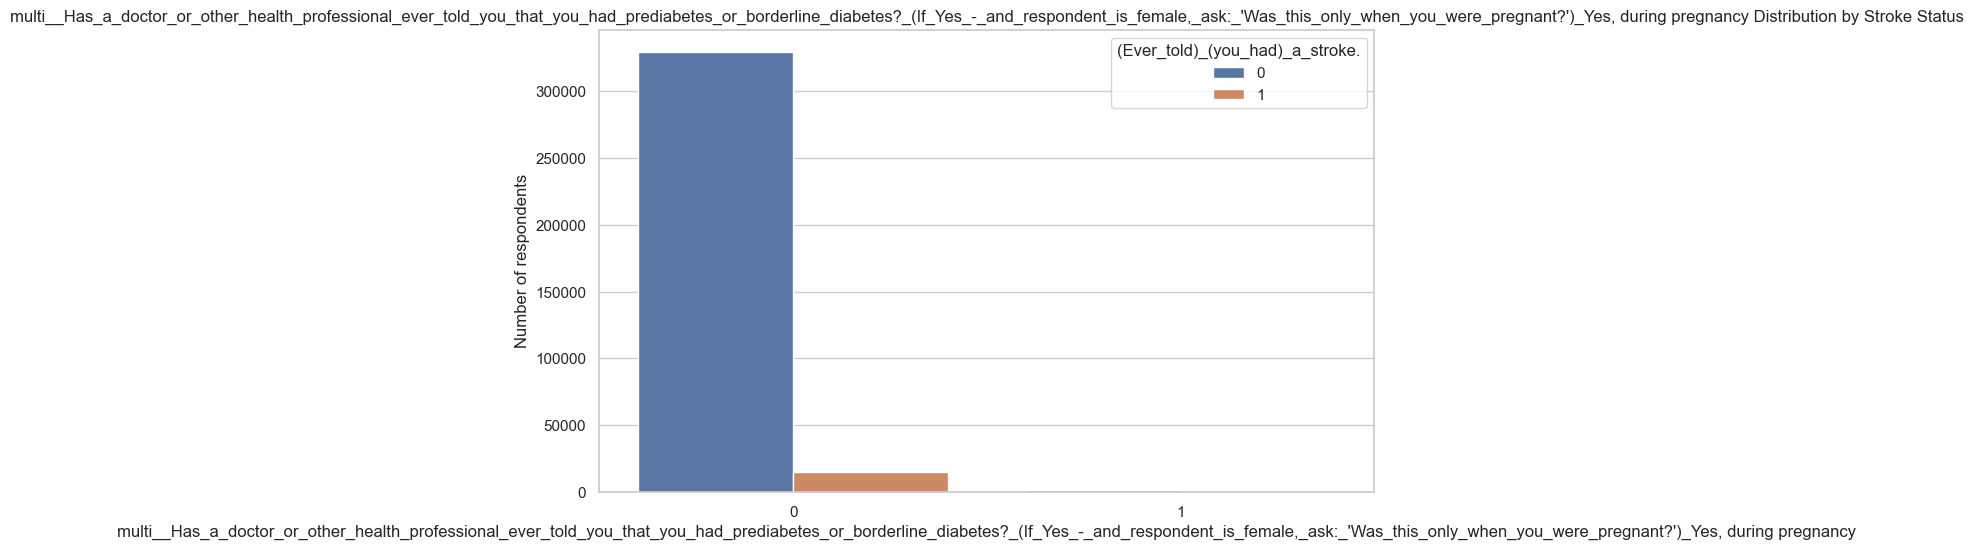

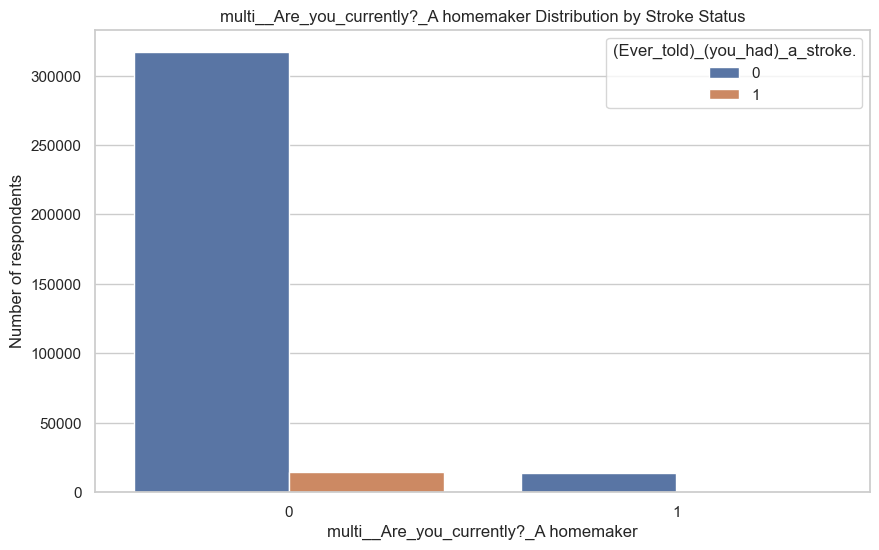

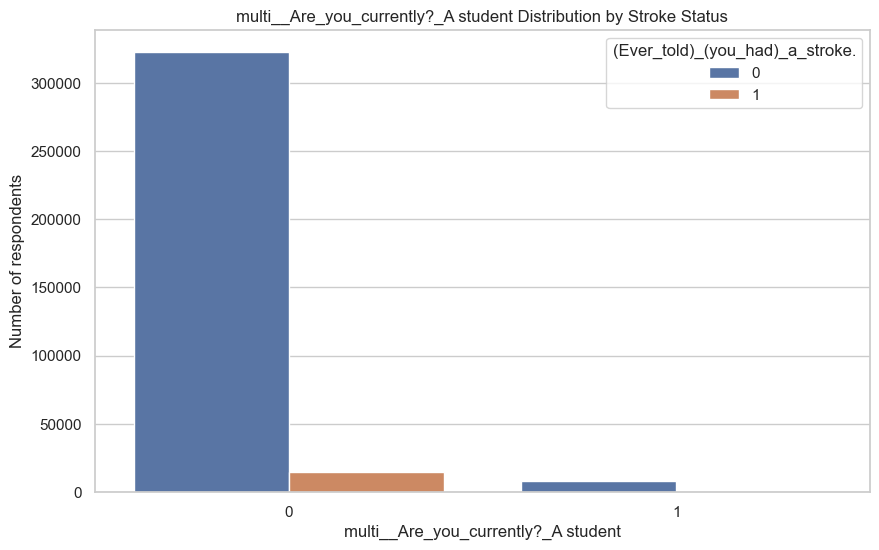

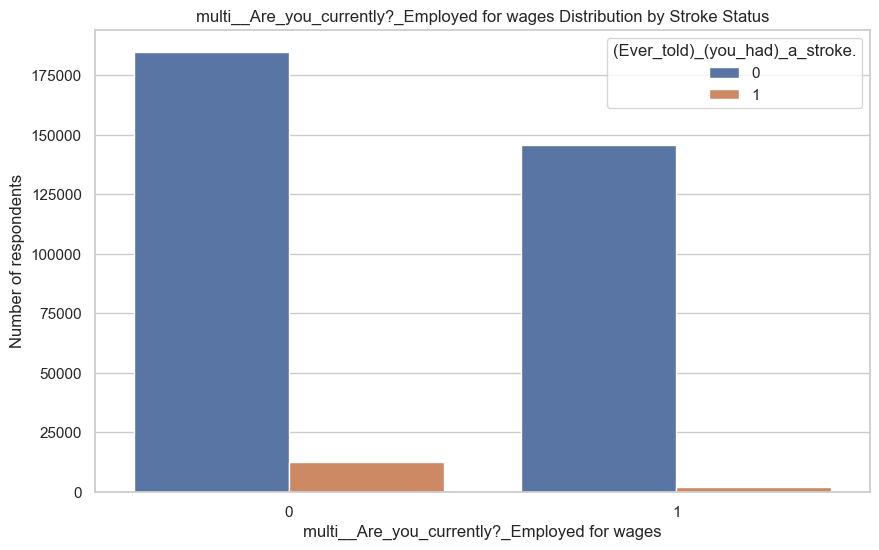

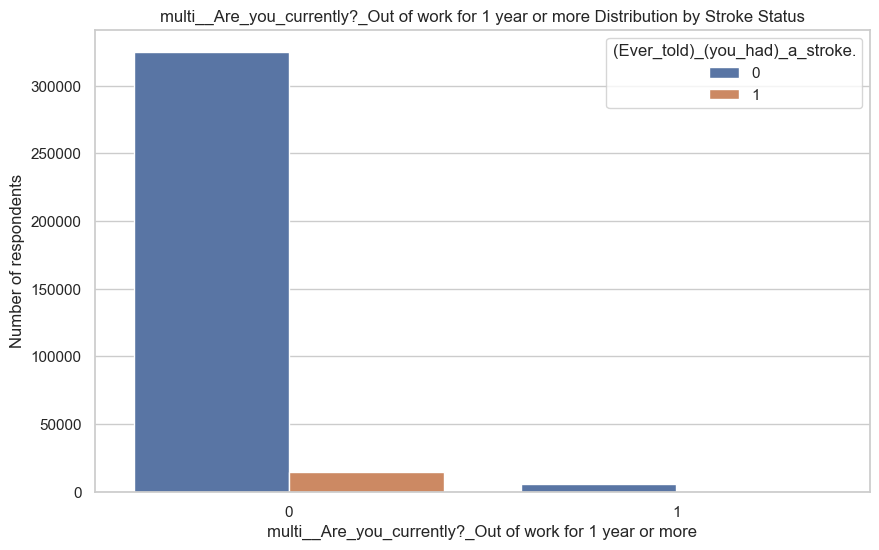

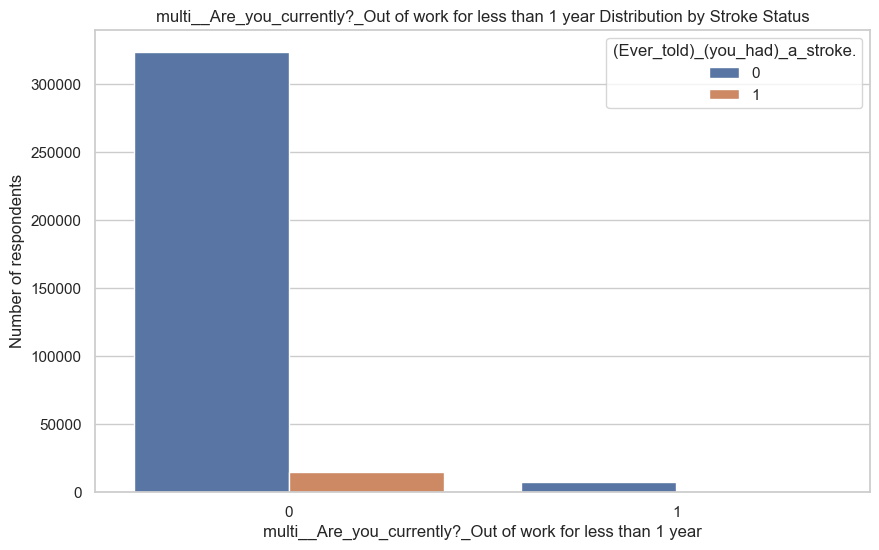

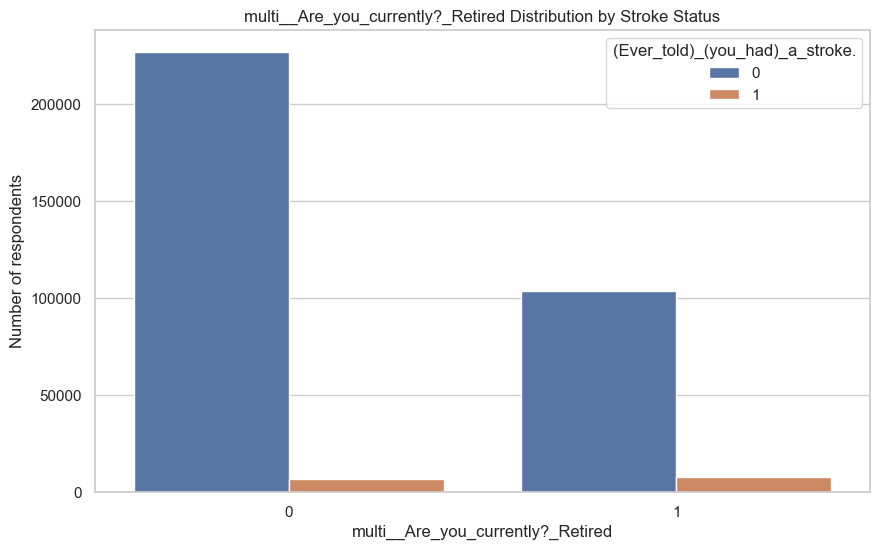

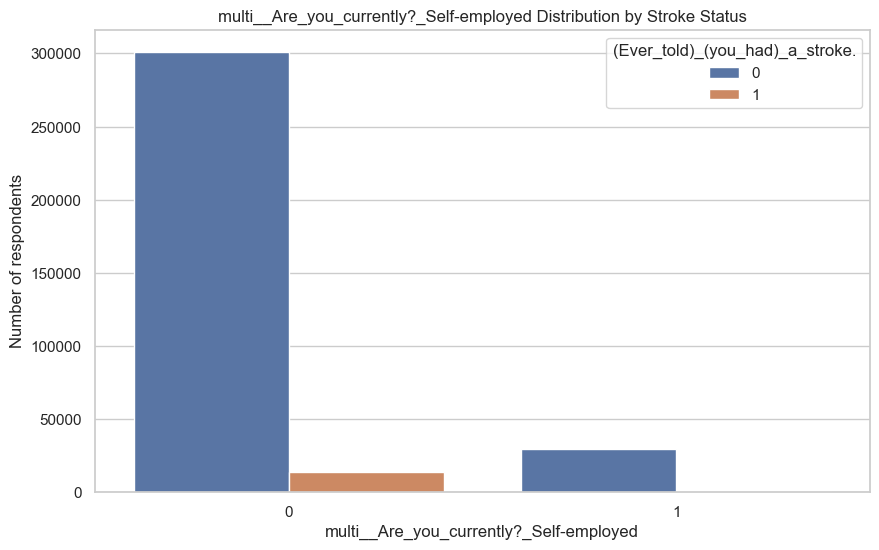

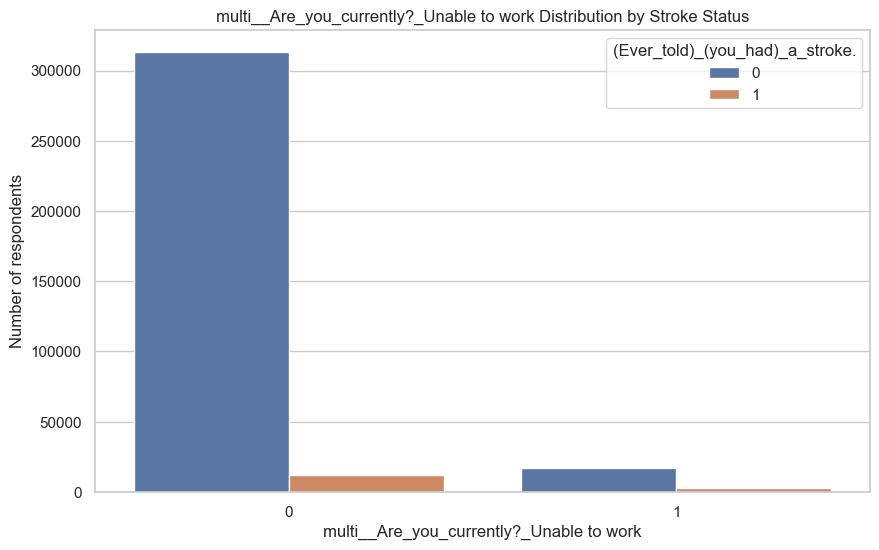

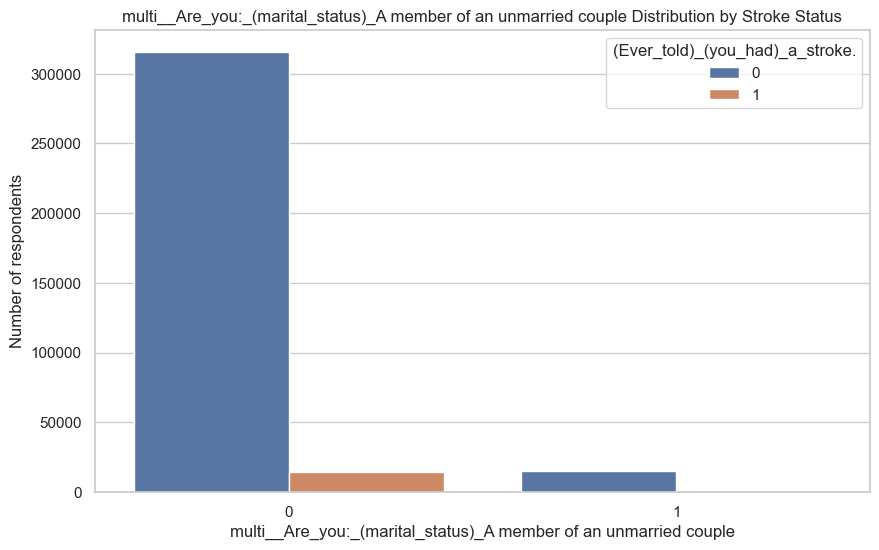

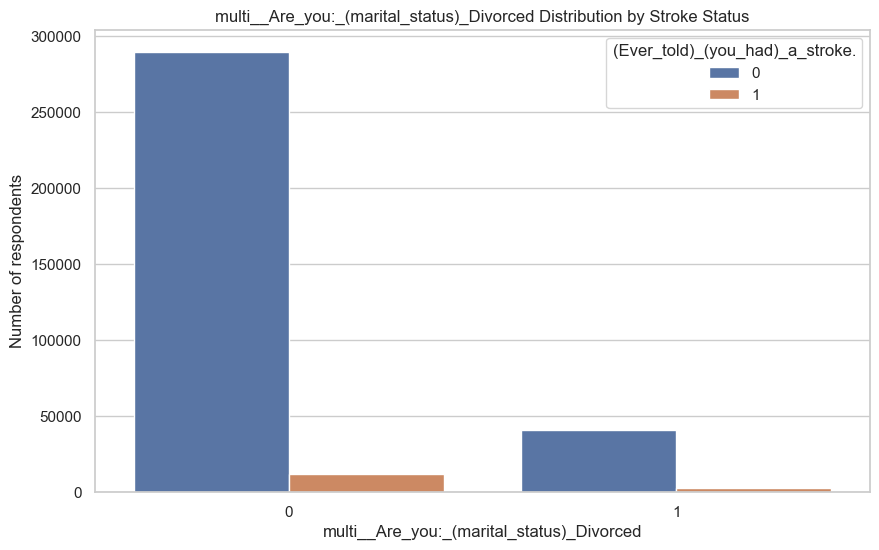

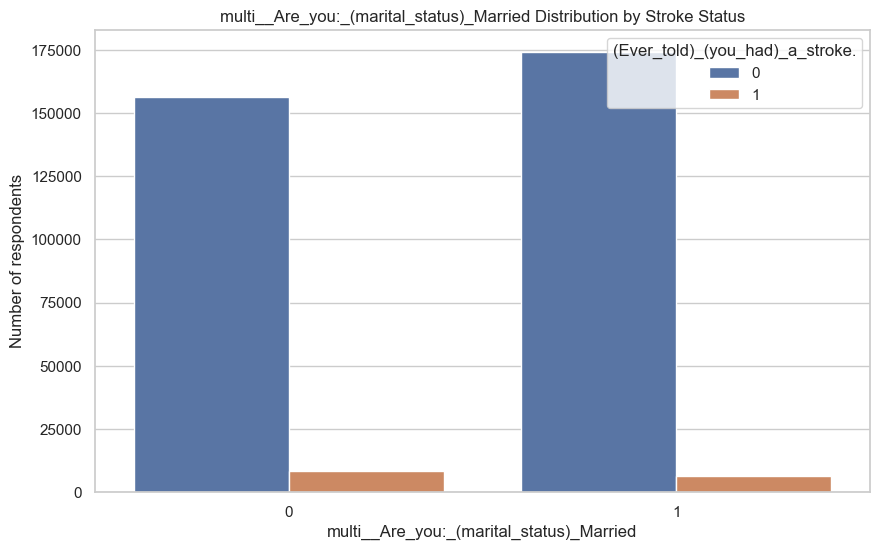

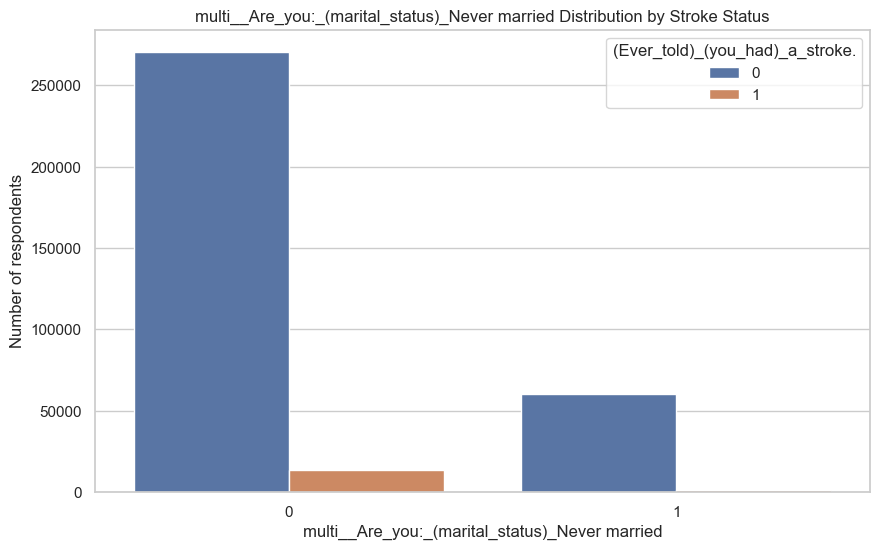

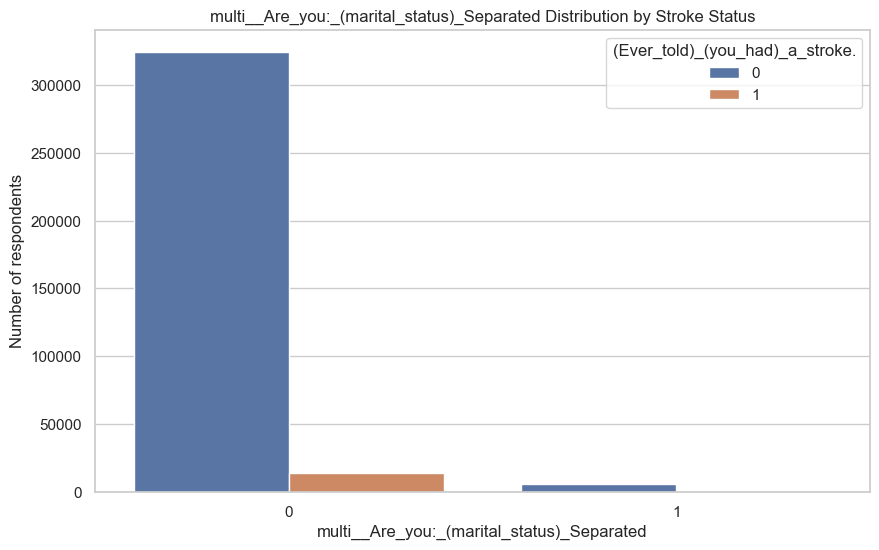

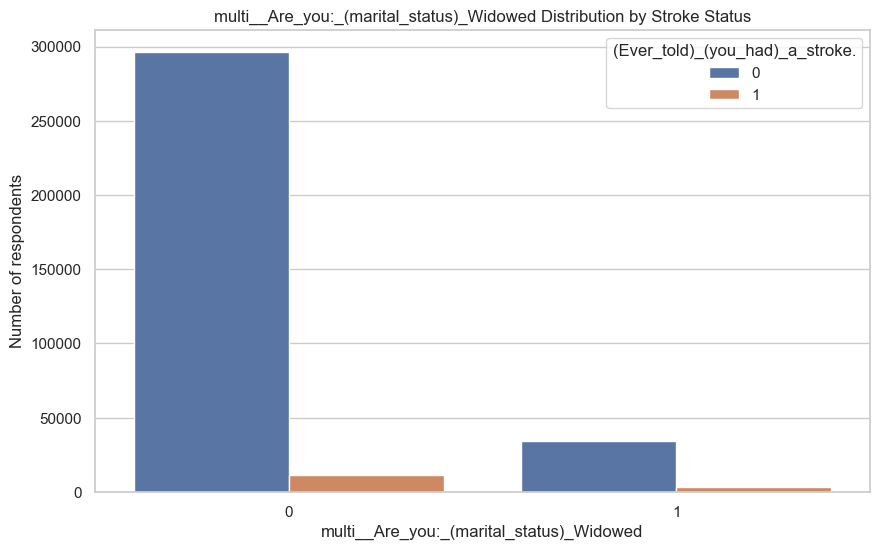

In [12]:
for col in numeric_feature_cols:
    sns.countplot(
        data=df,
        x=col,
        hue="(Ever_told)_(you_had)_a_stroke."
        )

    plt.xlabel(col)
    plt.ylabel("Number of respondents")
    plt.title(f"{col} Distribution by Stroke Status")
    plt.show()


## 7. Categorical and Binary Variable Analysis

In [13]:
unique_summary = (
    df.drop(columns=[target_col])
      .nunique()
      .sort_values()
      .to_frame("number_of_unique_values")
)

display(unique_summary)


,number_of_unique_values
binary__Sex_of_Respondent_Male,2
"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",2
binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes,2
binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,2
"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",2
binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,2
"binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes",2
binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,2
"binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes",2
binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days,2


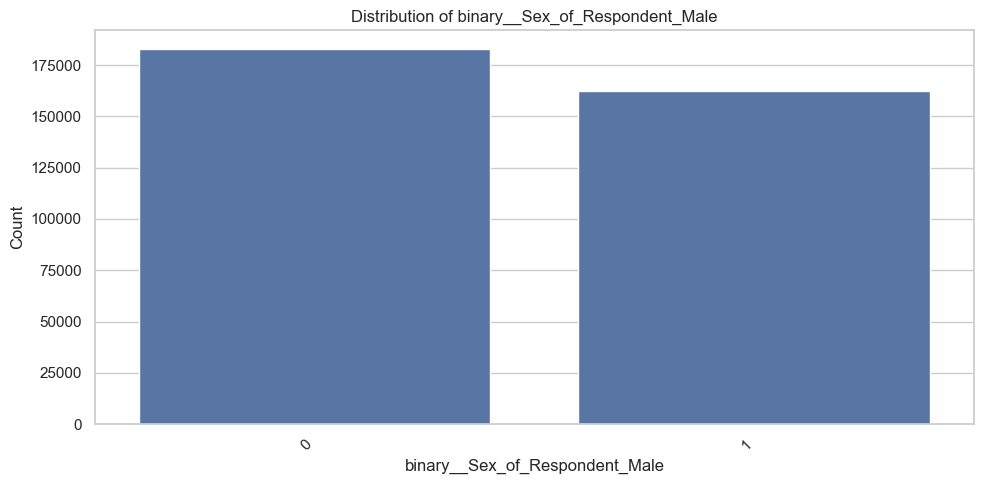

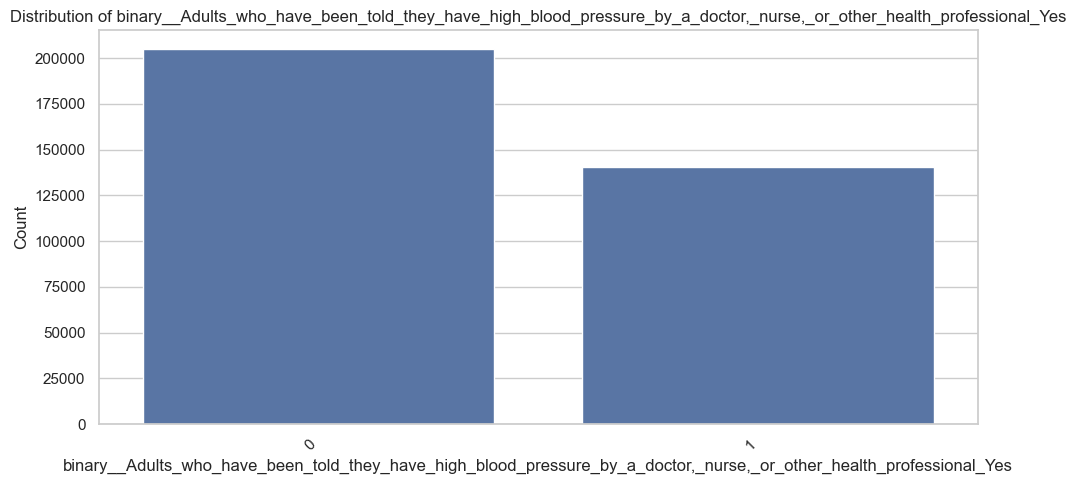

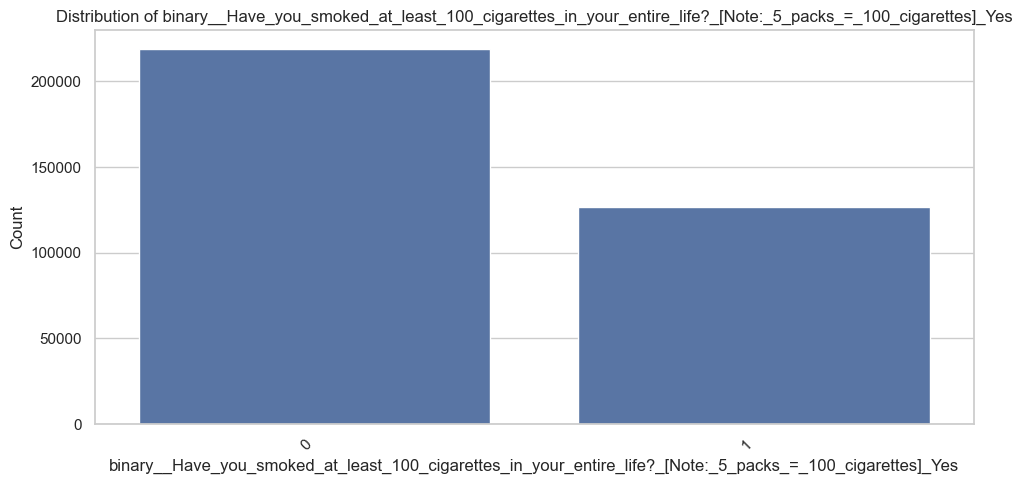

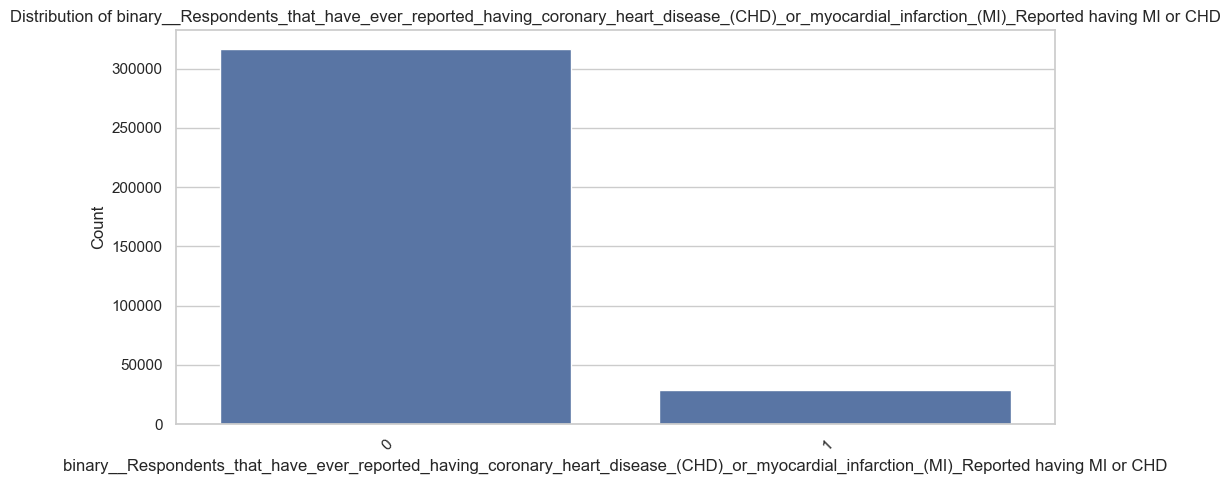

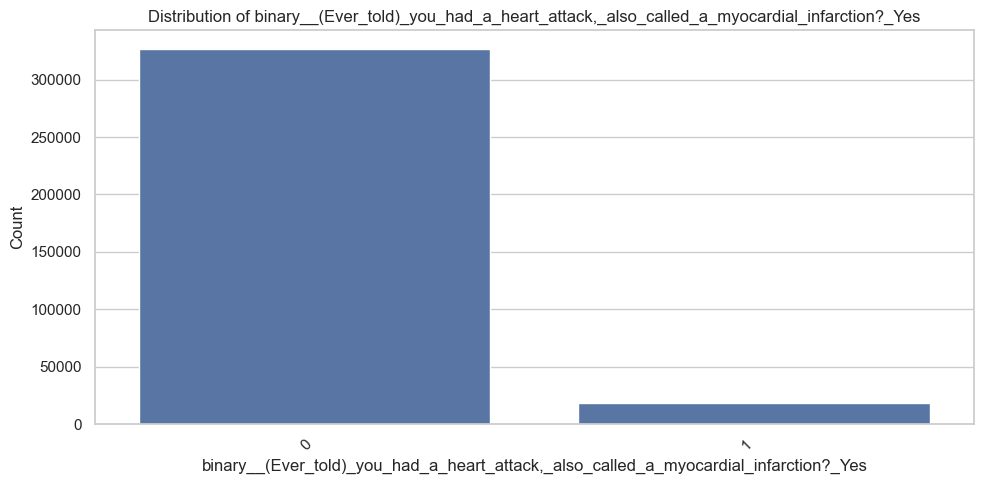

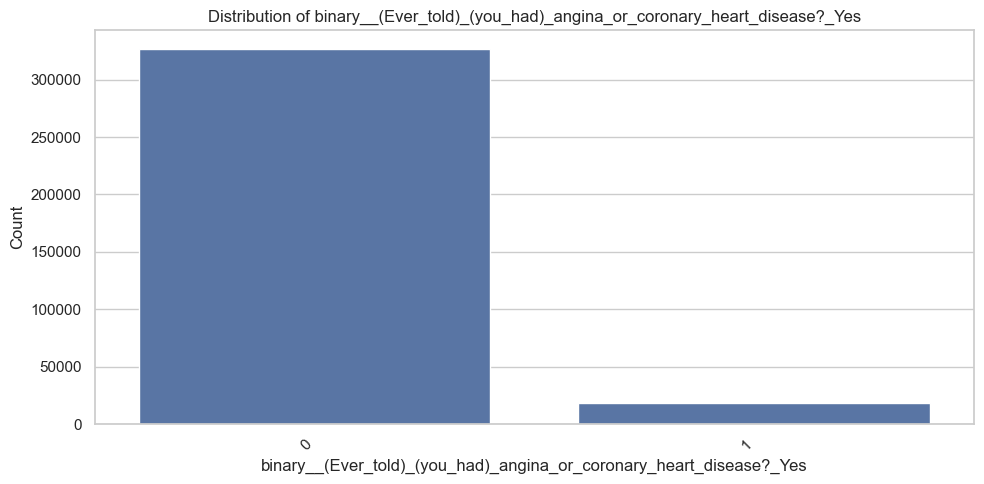

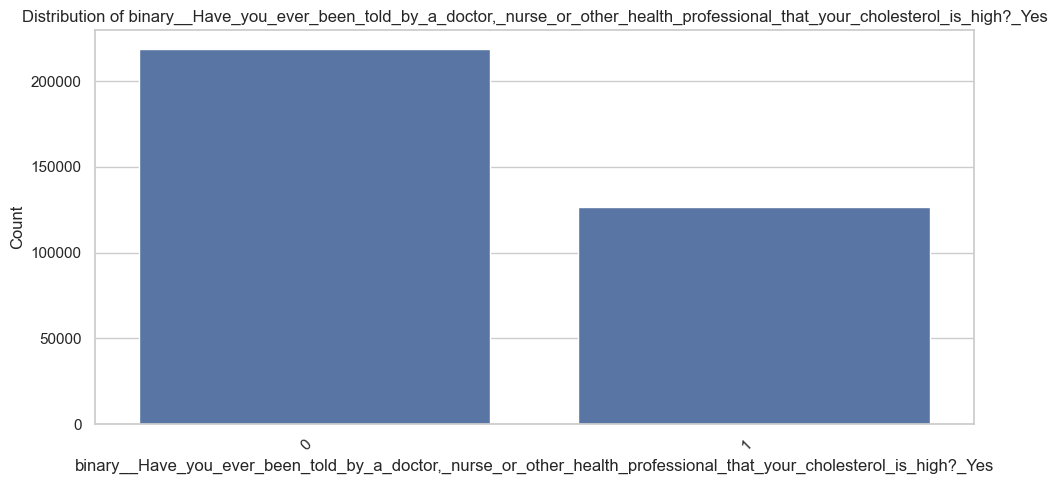

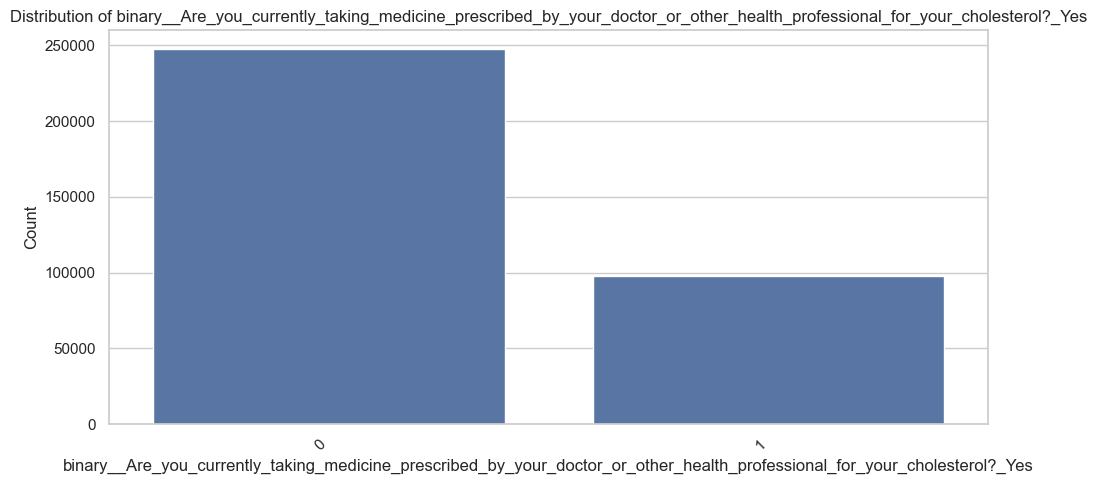

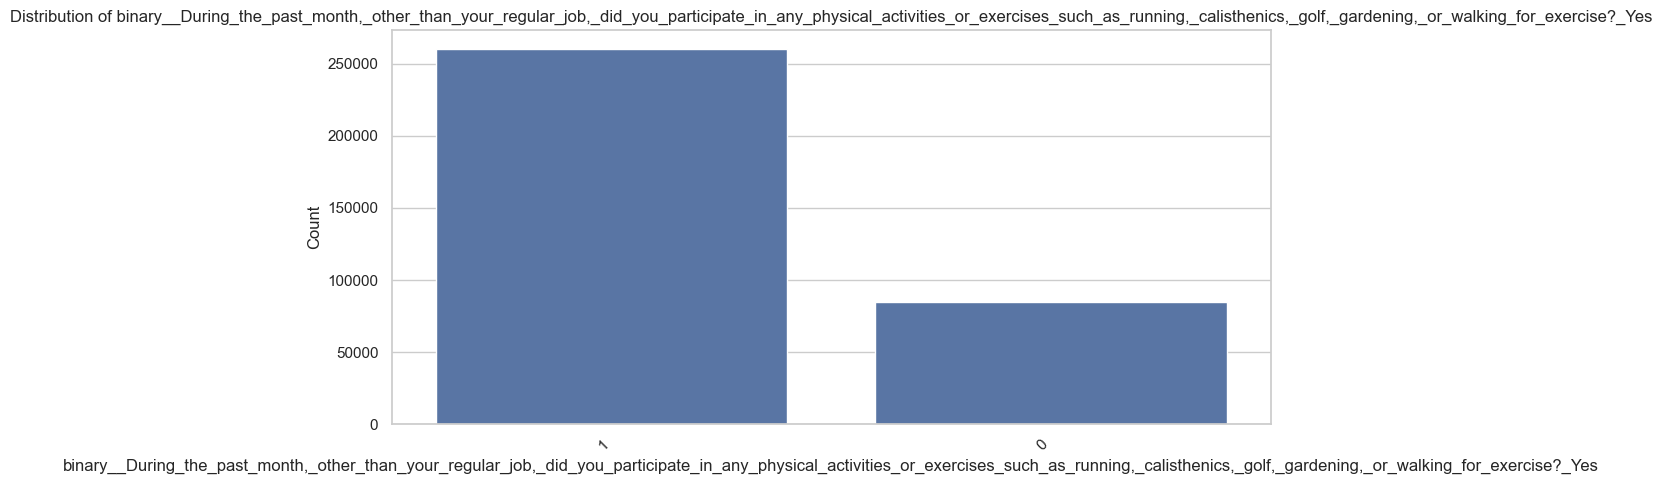

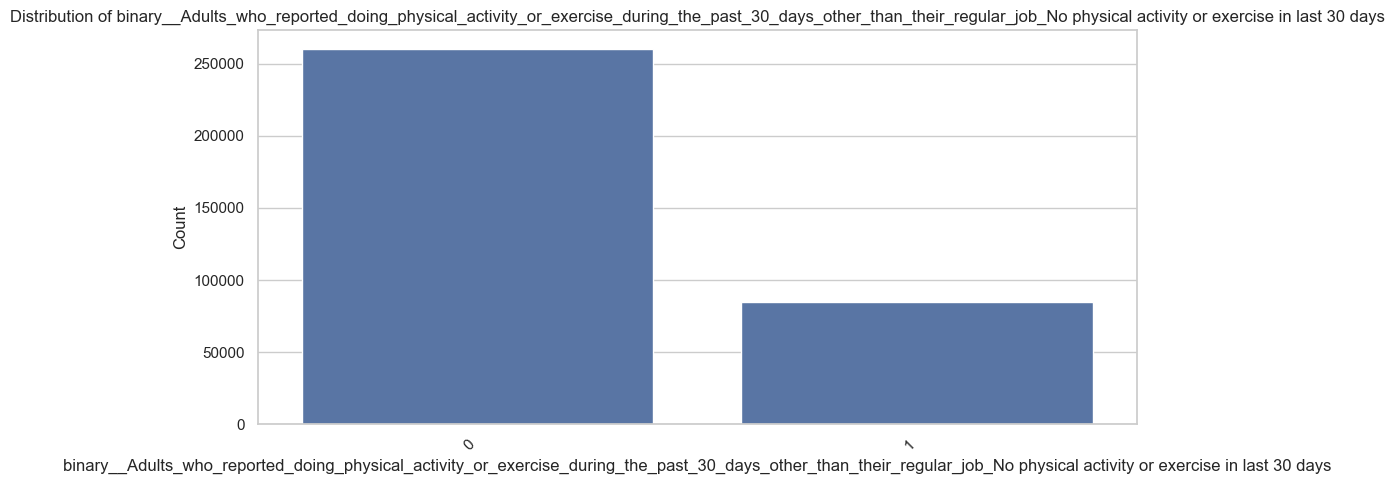

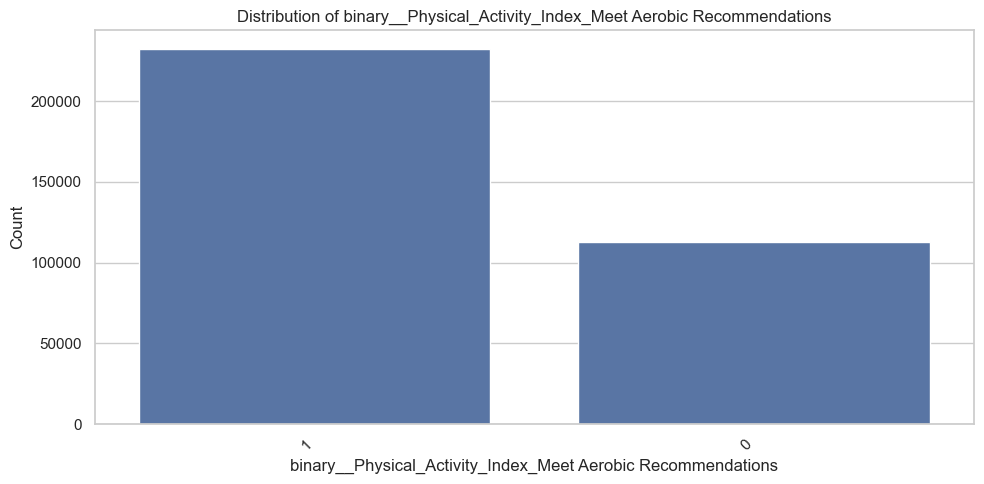

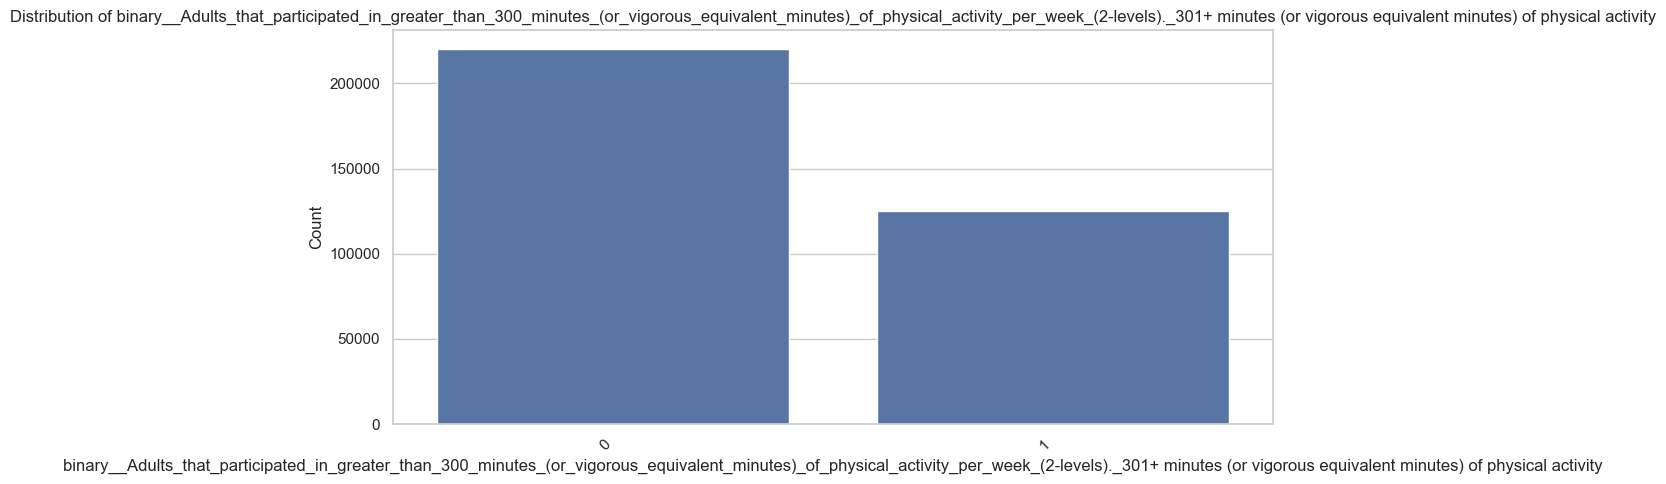

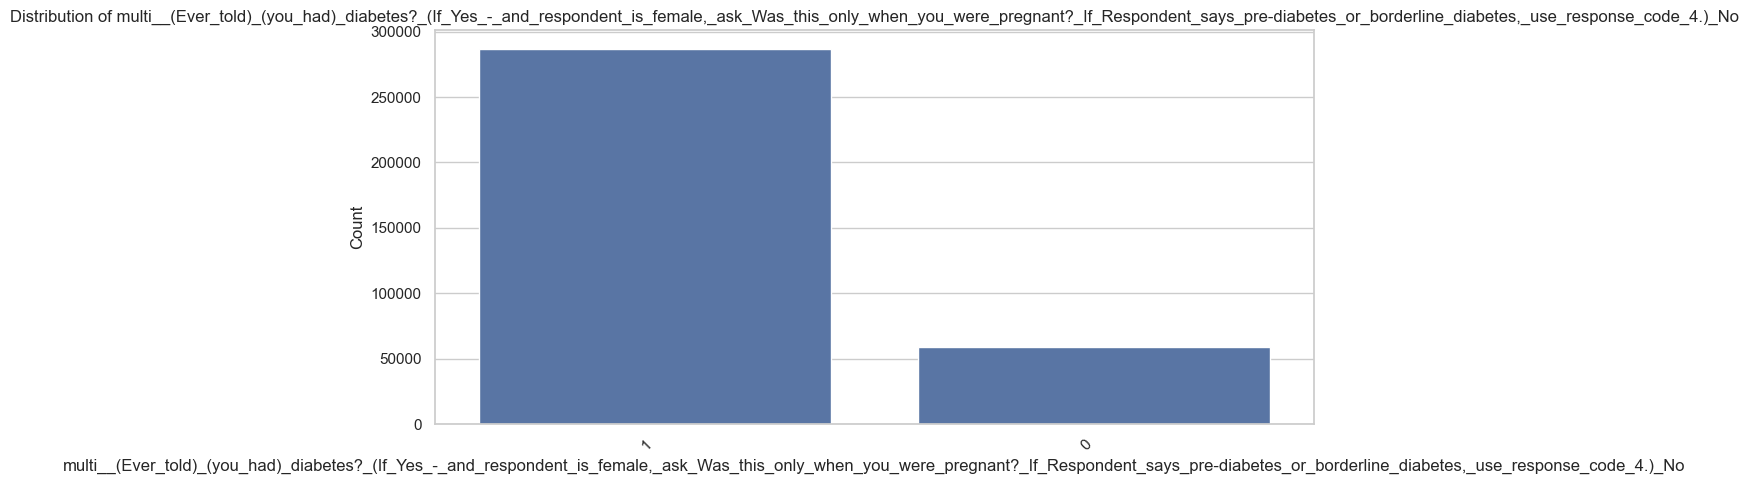

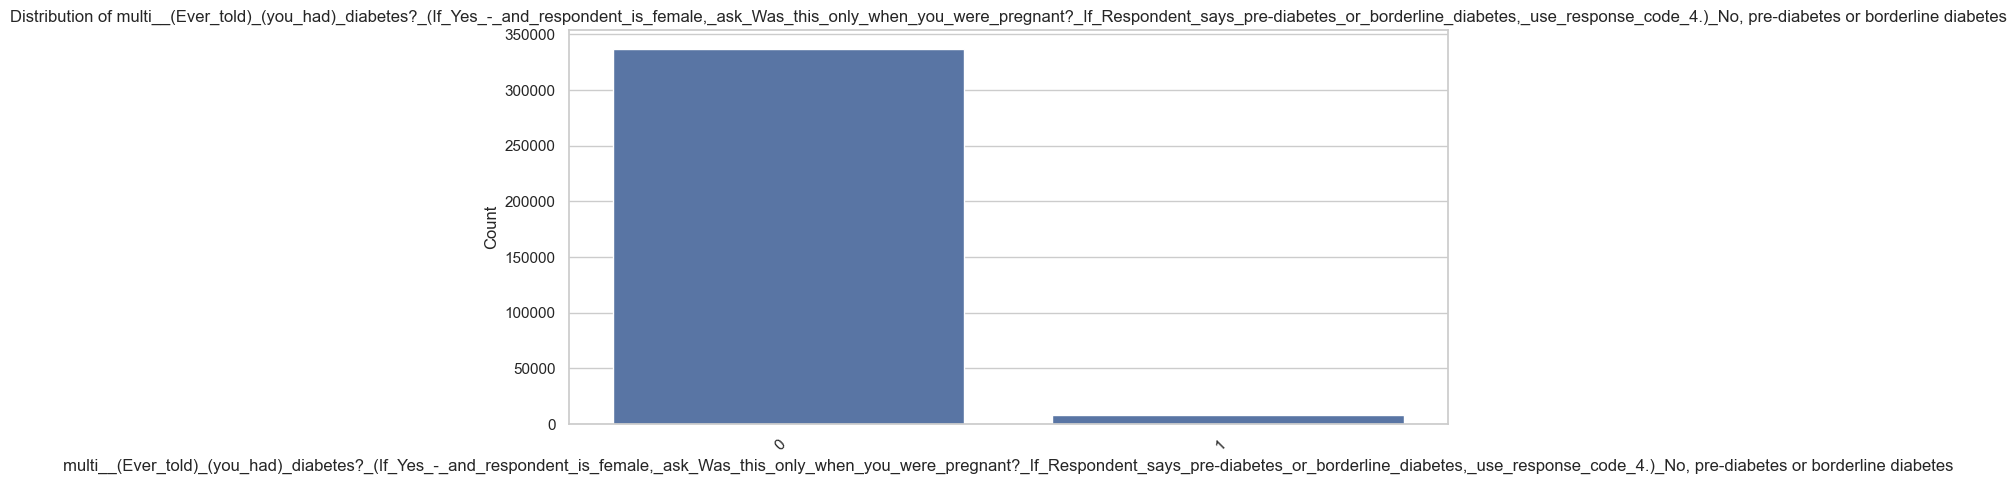

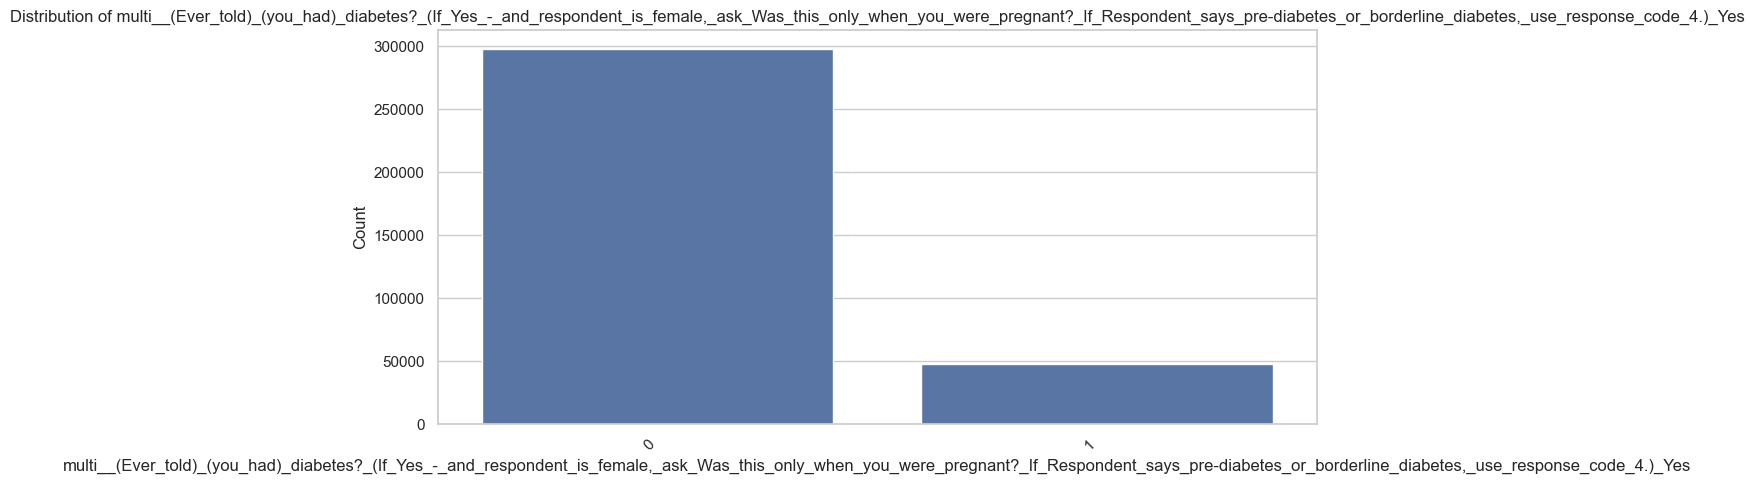

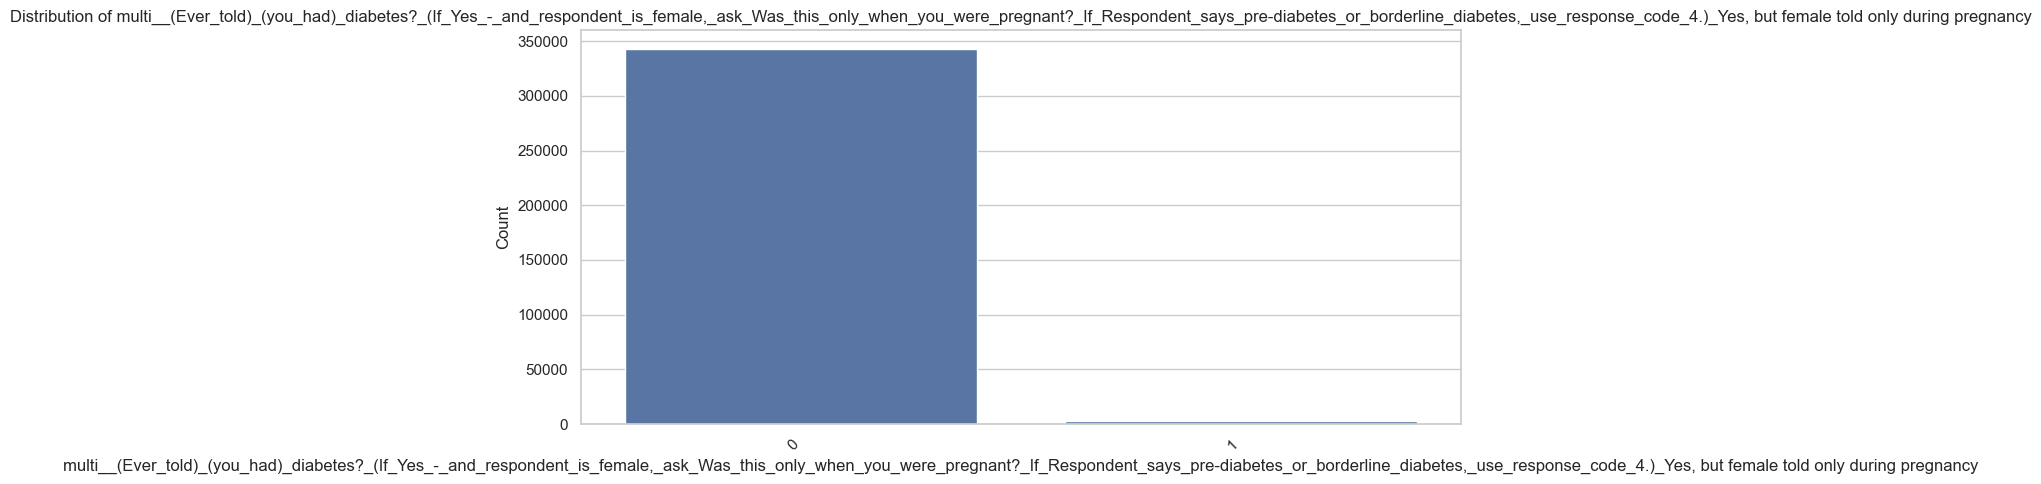

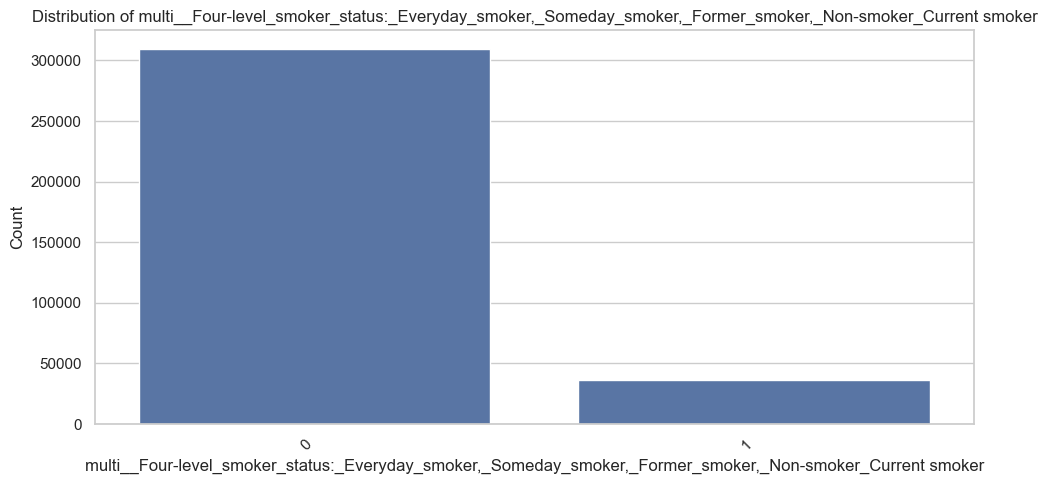

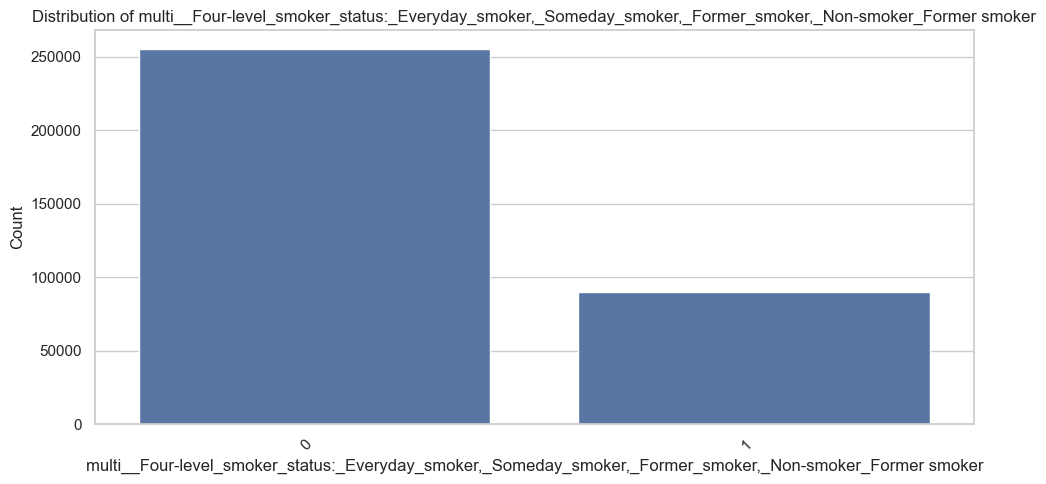

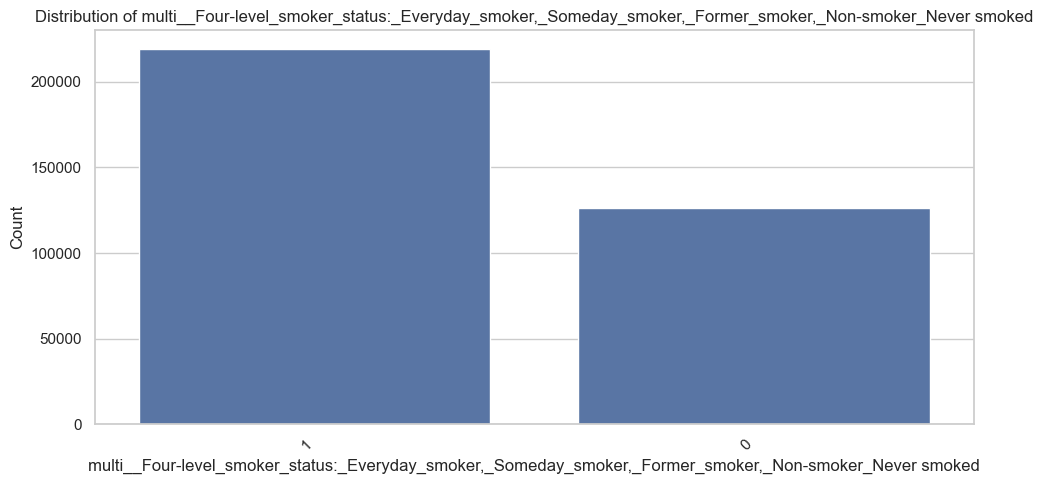

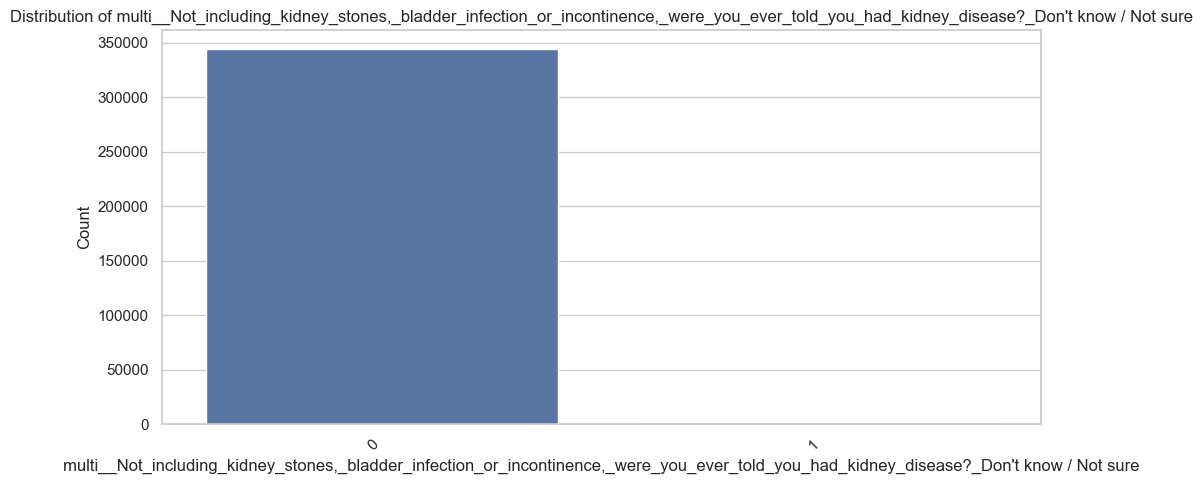

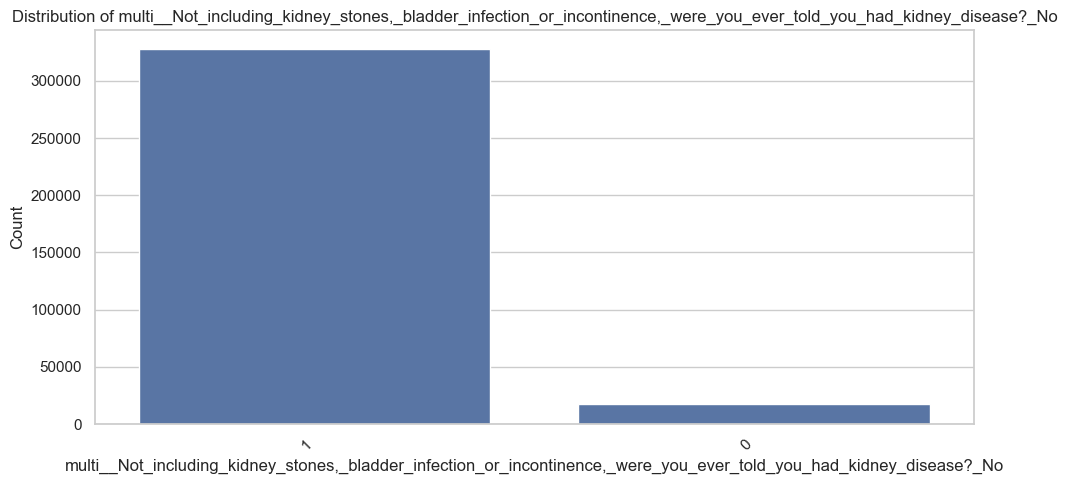

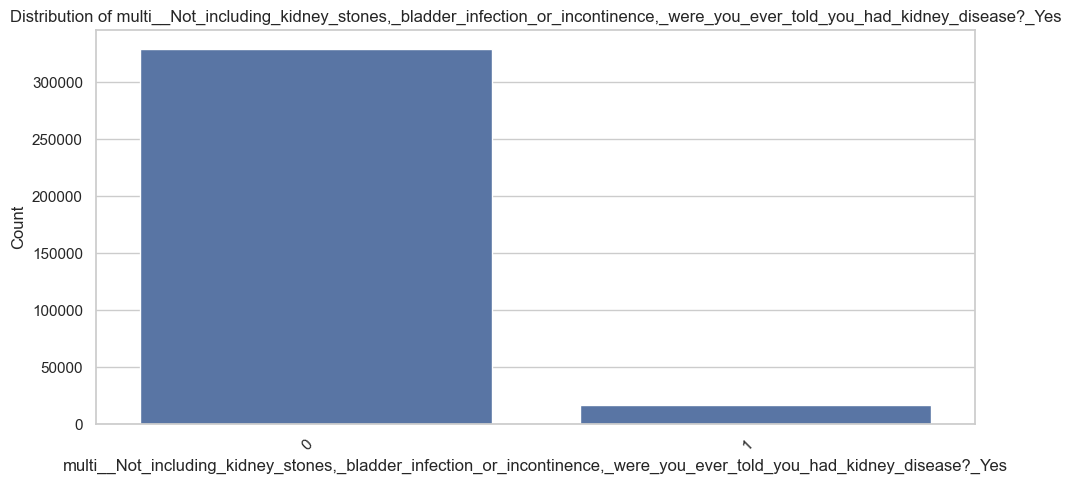

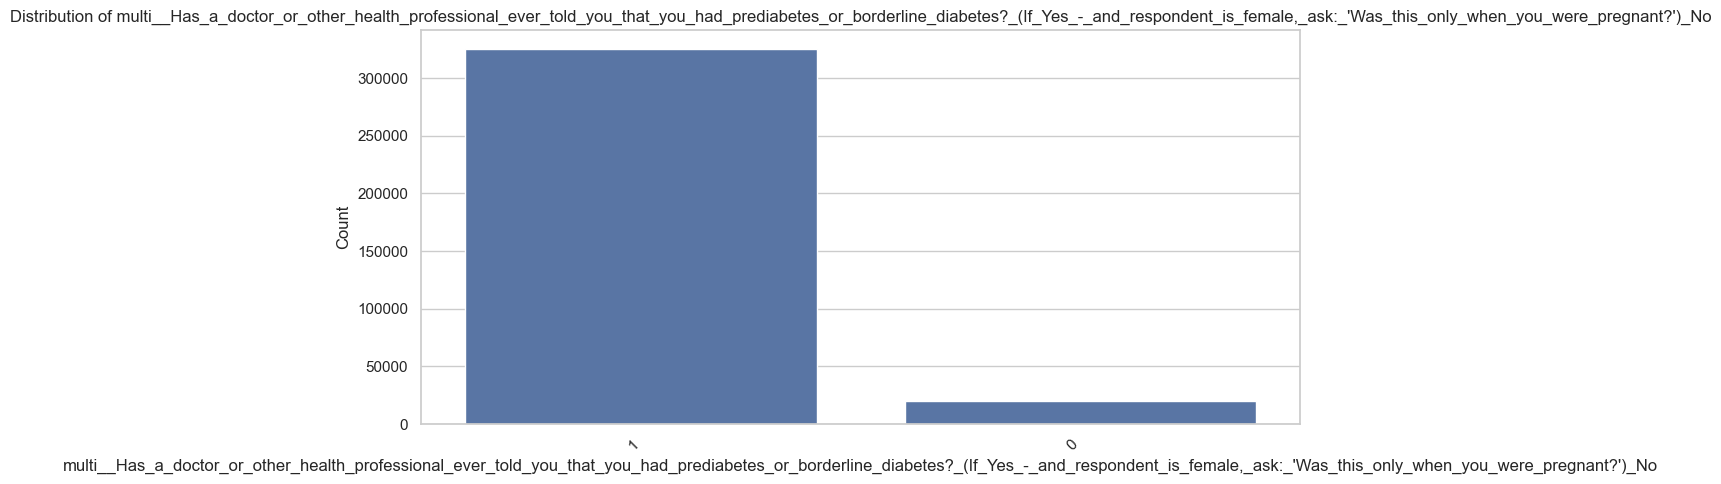

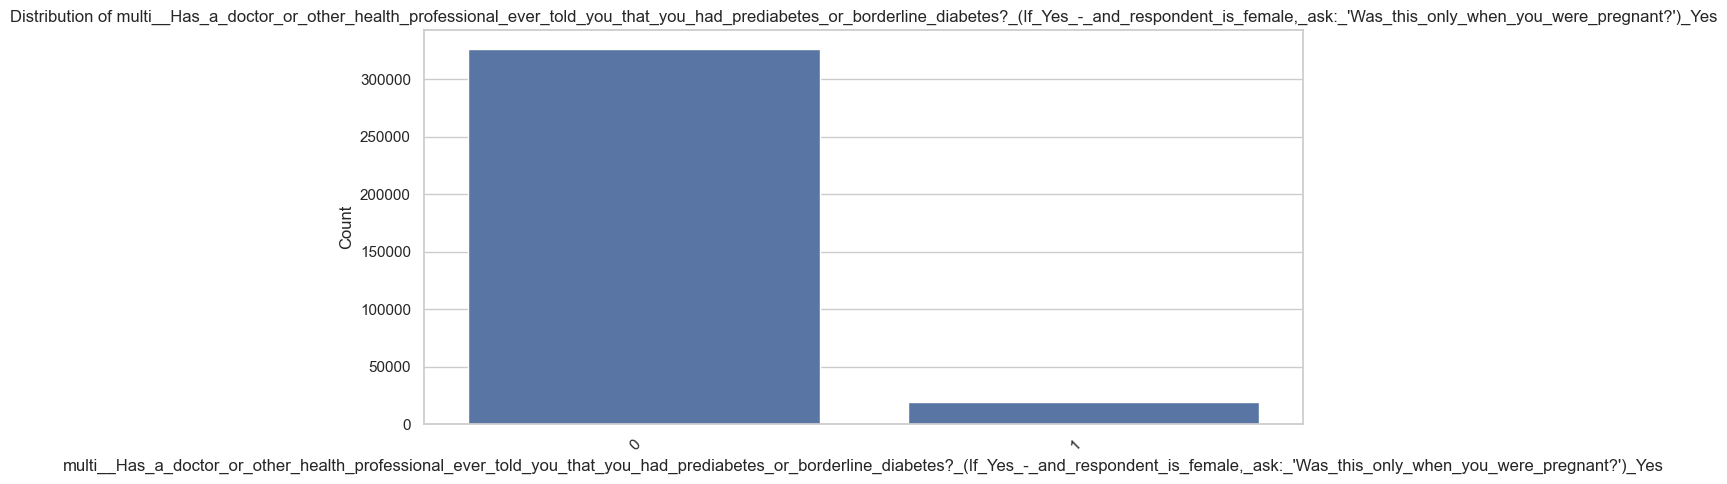

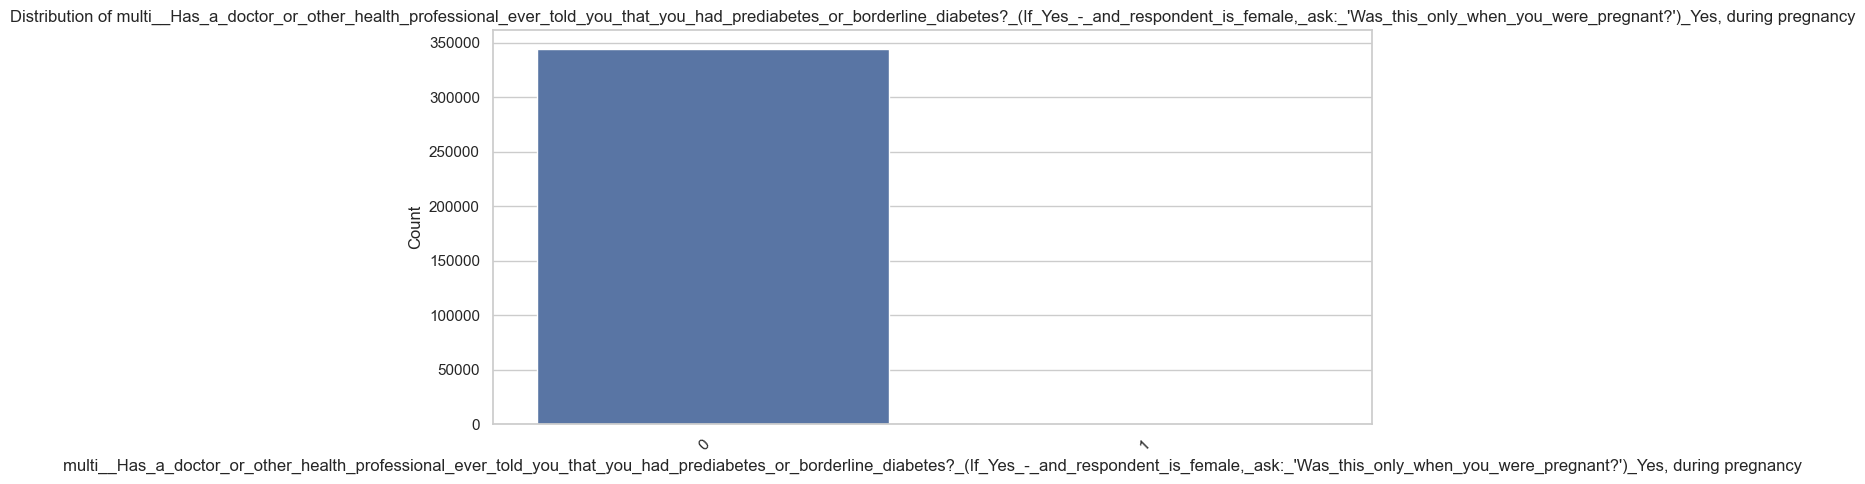

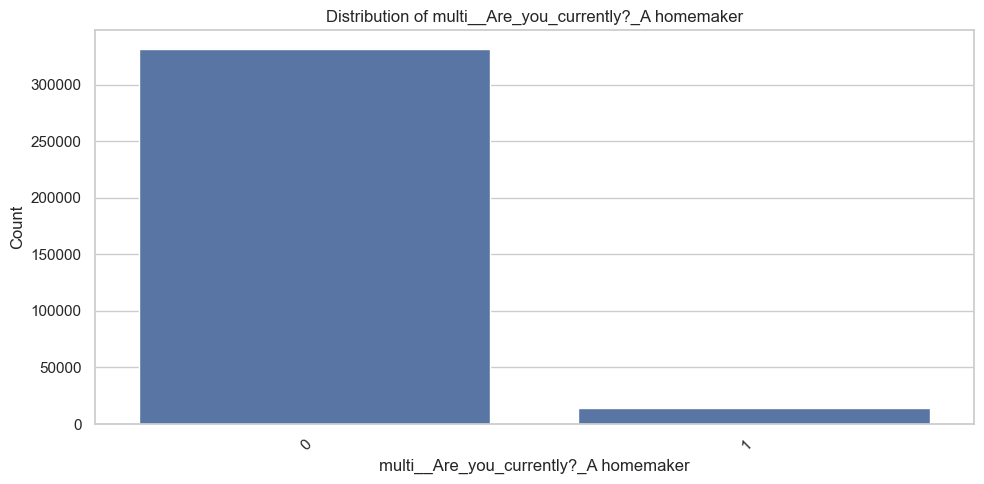

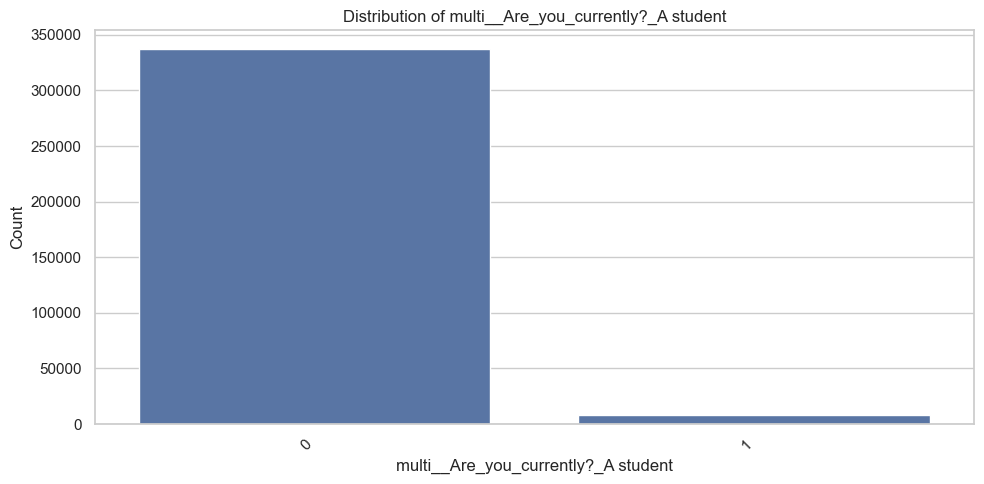

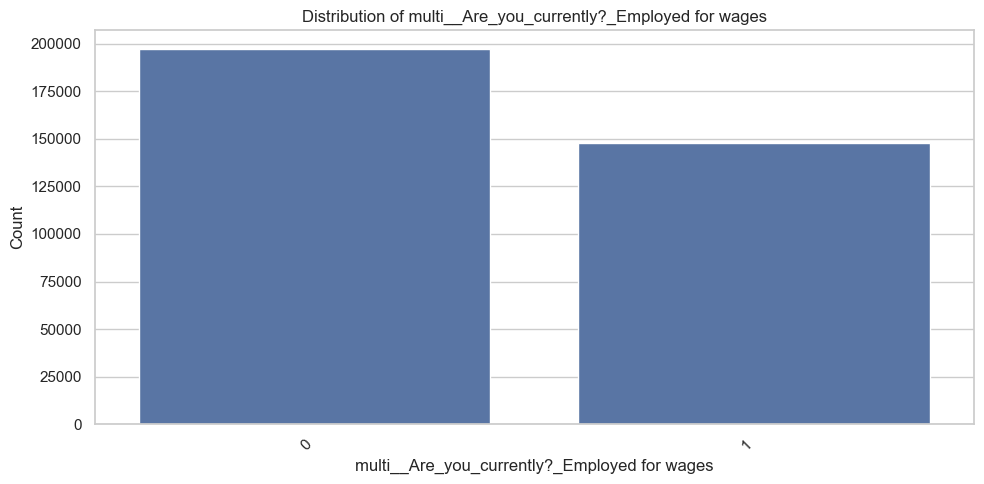

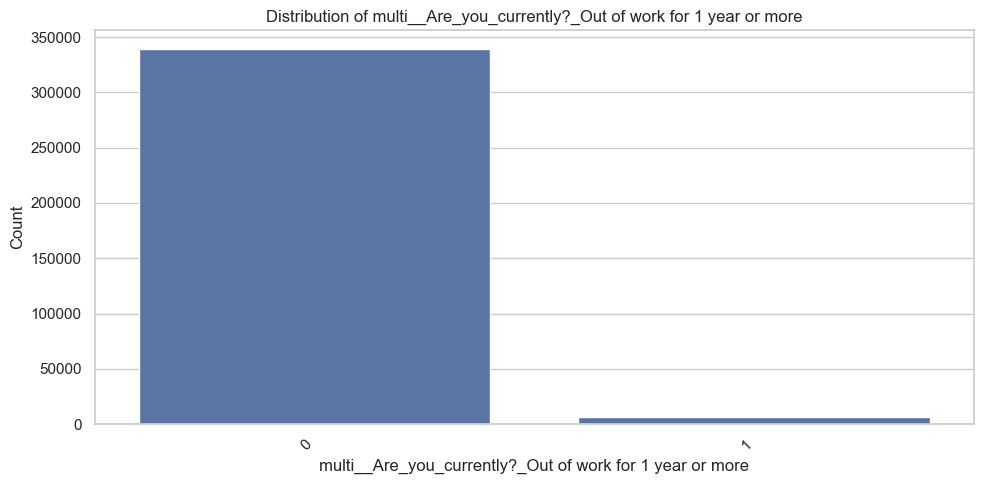

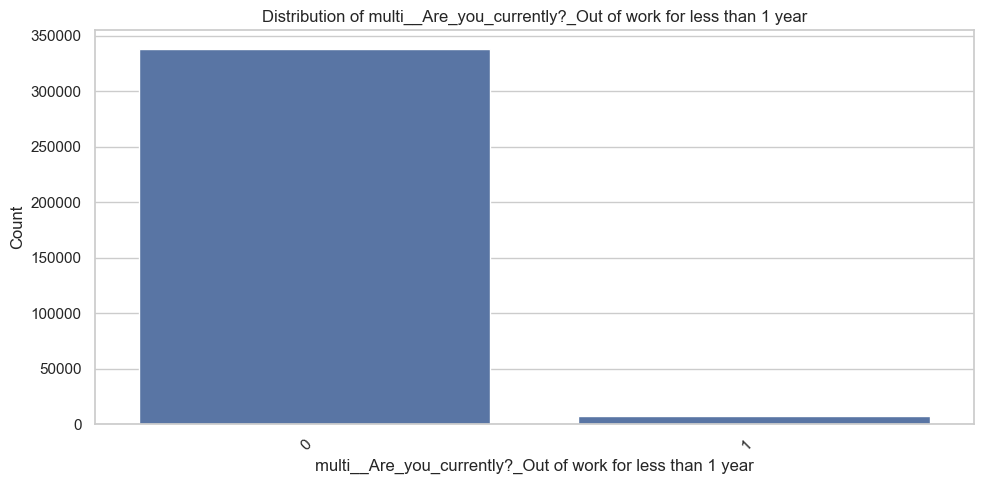

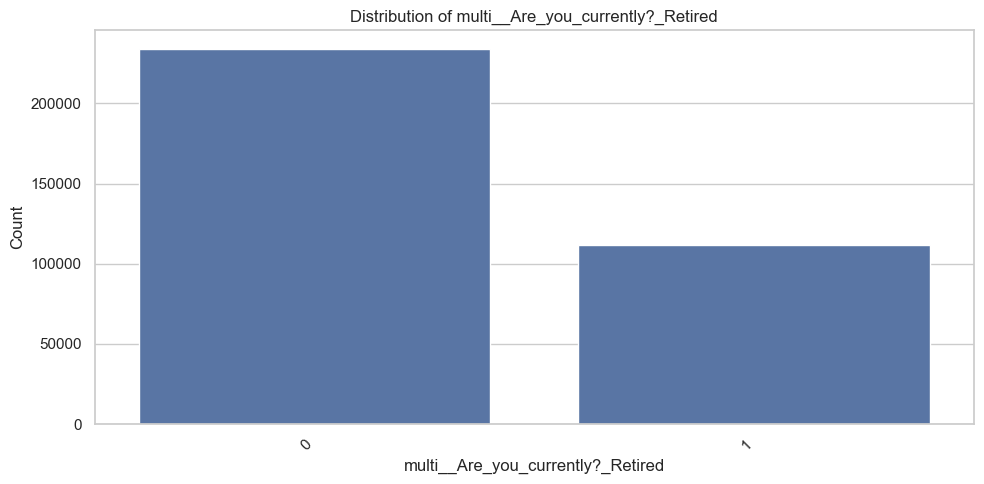

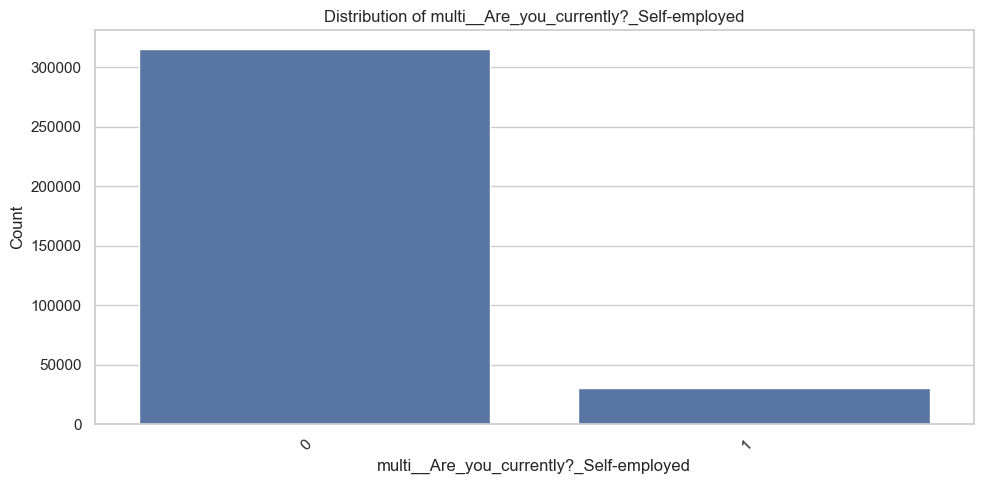

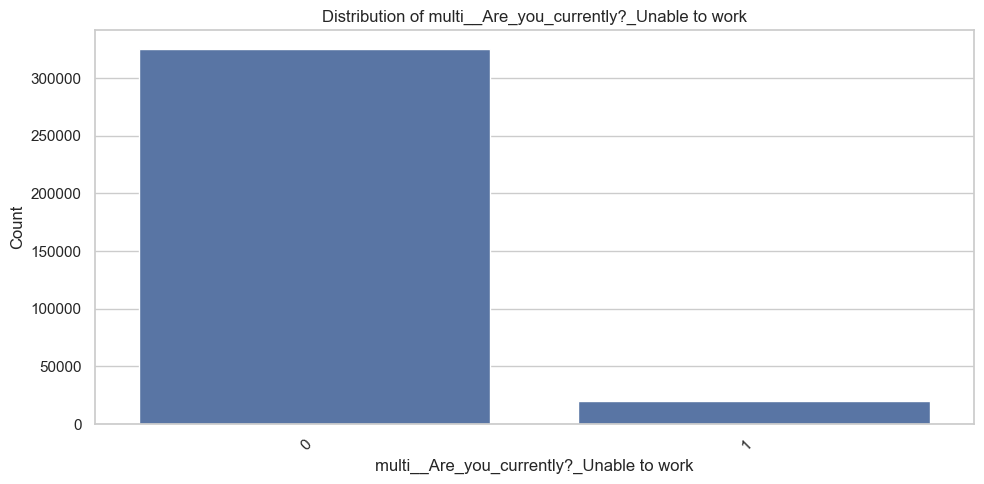

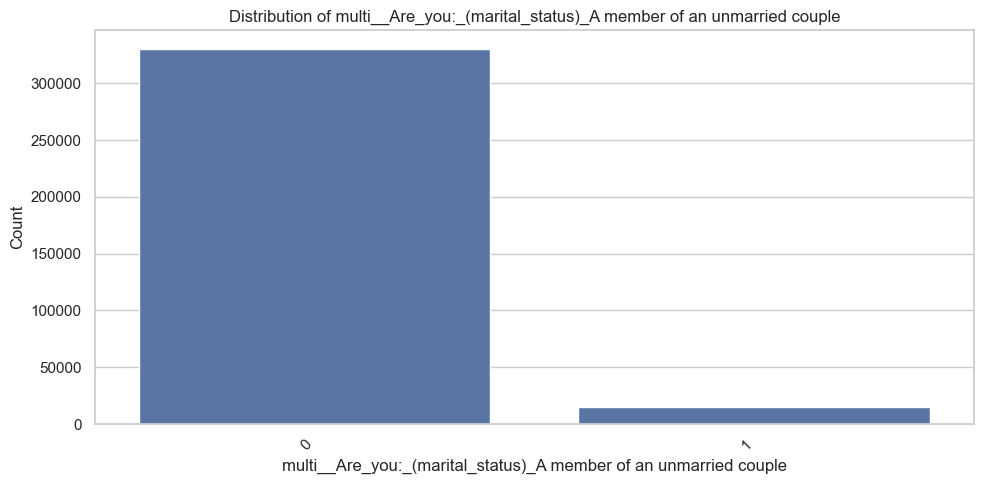

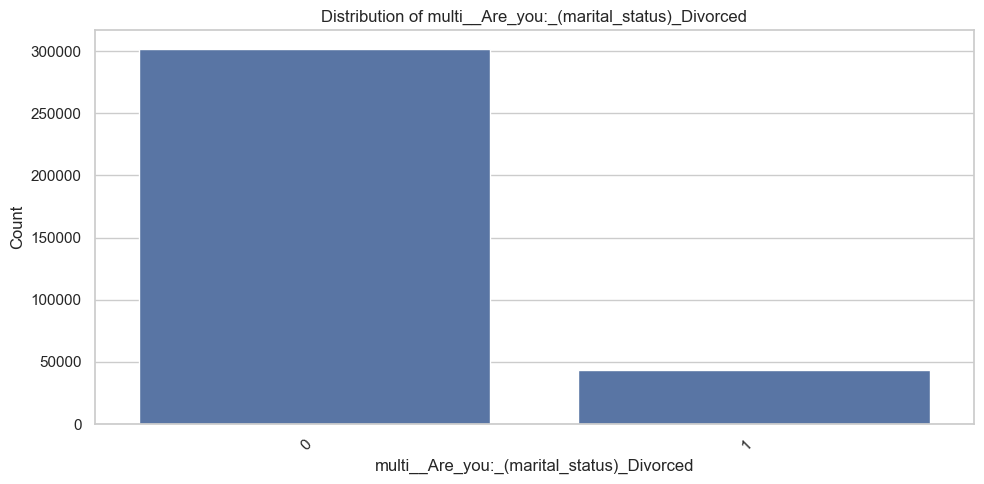

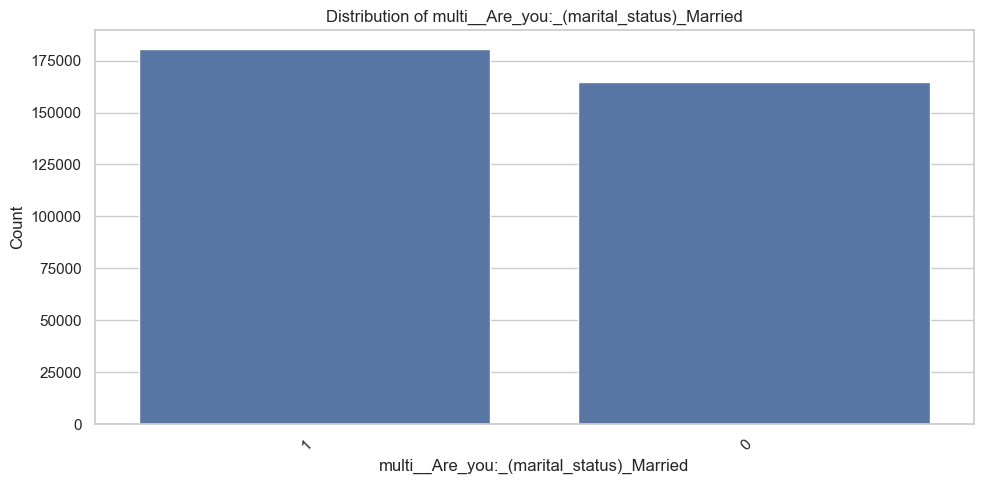

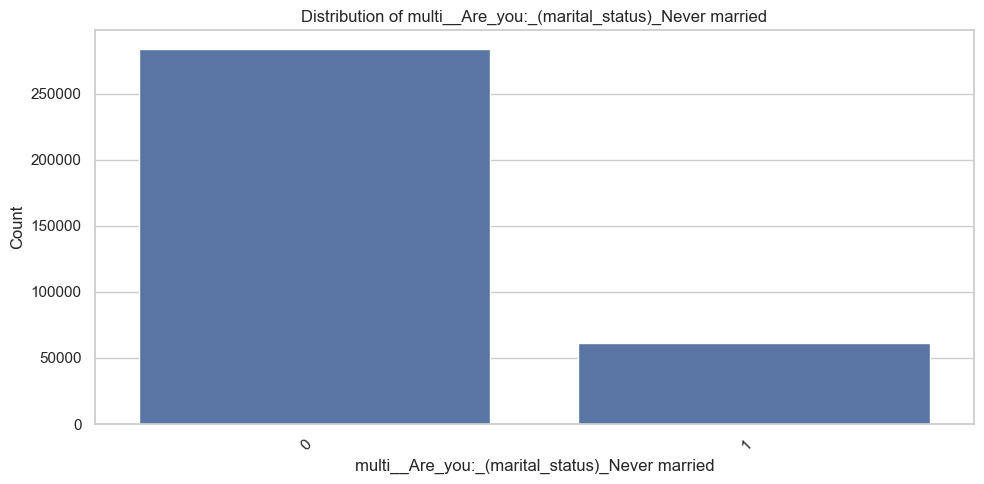

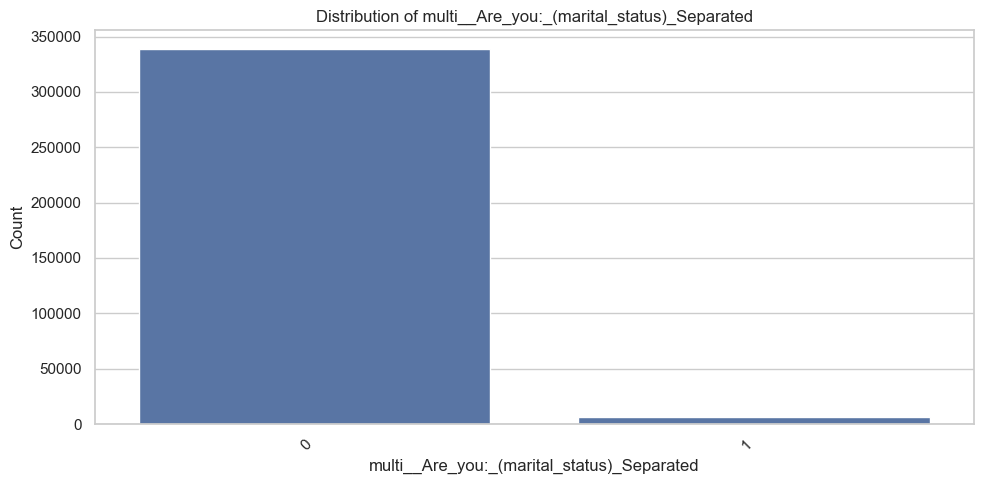

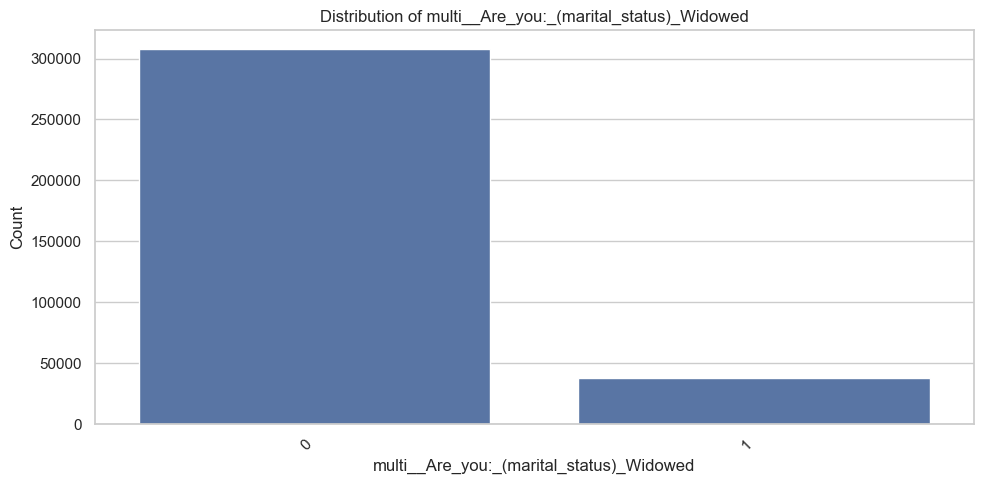

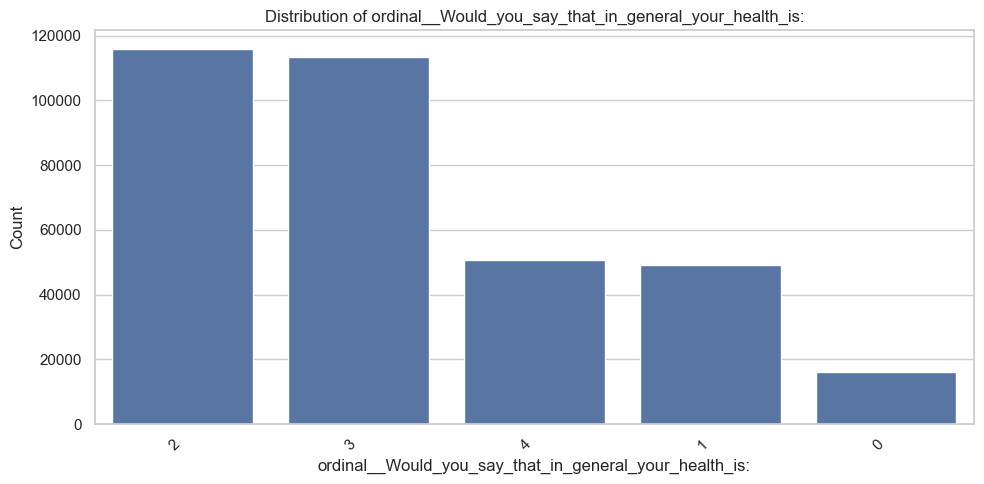

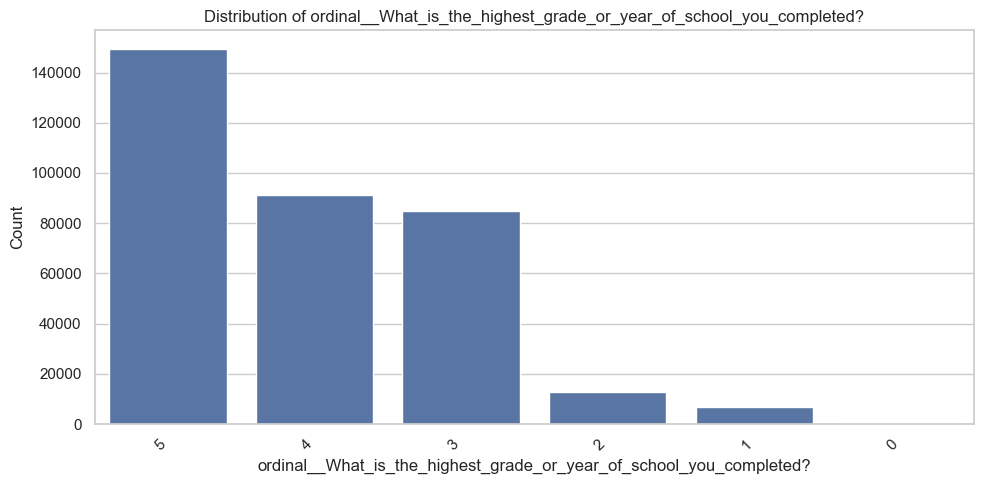

In [14]:
low_cardinality_cols = [
    col for col in df.columns
    if col != target_col and df[col].nunique(dropna=False) <= 8
]

for col in low_cardinality_cols:
    counts = df[col].value_counts(dropna=False).head(15)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts.index.astype(str), y=counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 8. Relationship Between Variables and Stroke

For binary and one-hot encoded variables, the mean within each stroke group can be interpreted as the proportion of records for which that indicator equals 1.

In [15]:
indicator_cols = [
    col for col in df.columns
    if col != target_col and df[col].nunique(dropna=True) <= 2
]

grouped_means = df.groupby(target_col)[indicator_cols].mean().T
display(grouped_means)


(Ever_told)_(you_had)_a_stroke.,0,1
binary__Sex_of_Respondent_Male,0.470356,0.473519
"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",0.392787,0.715425
binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes,0.359669,0.514961
binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,0.072399,0.336651
"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",0.045137,0.253698
binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,0.047273,0.204144
"binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes",0.357923,0.563970
binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,0.269912,0.580124
"binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes",0.761470,0.582646
binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days,0.238530,0.417354


C:\Users\nitya\AppData\Local\Temp\ipykernel_16504\2256066924.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


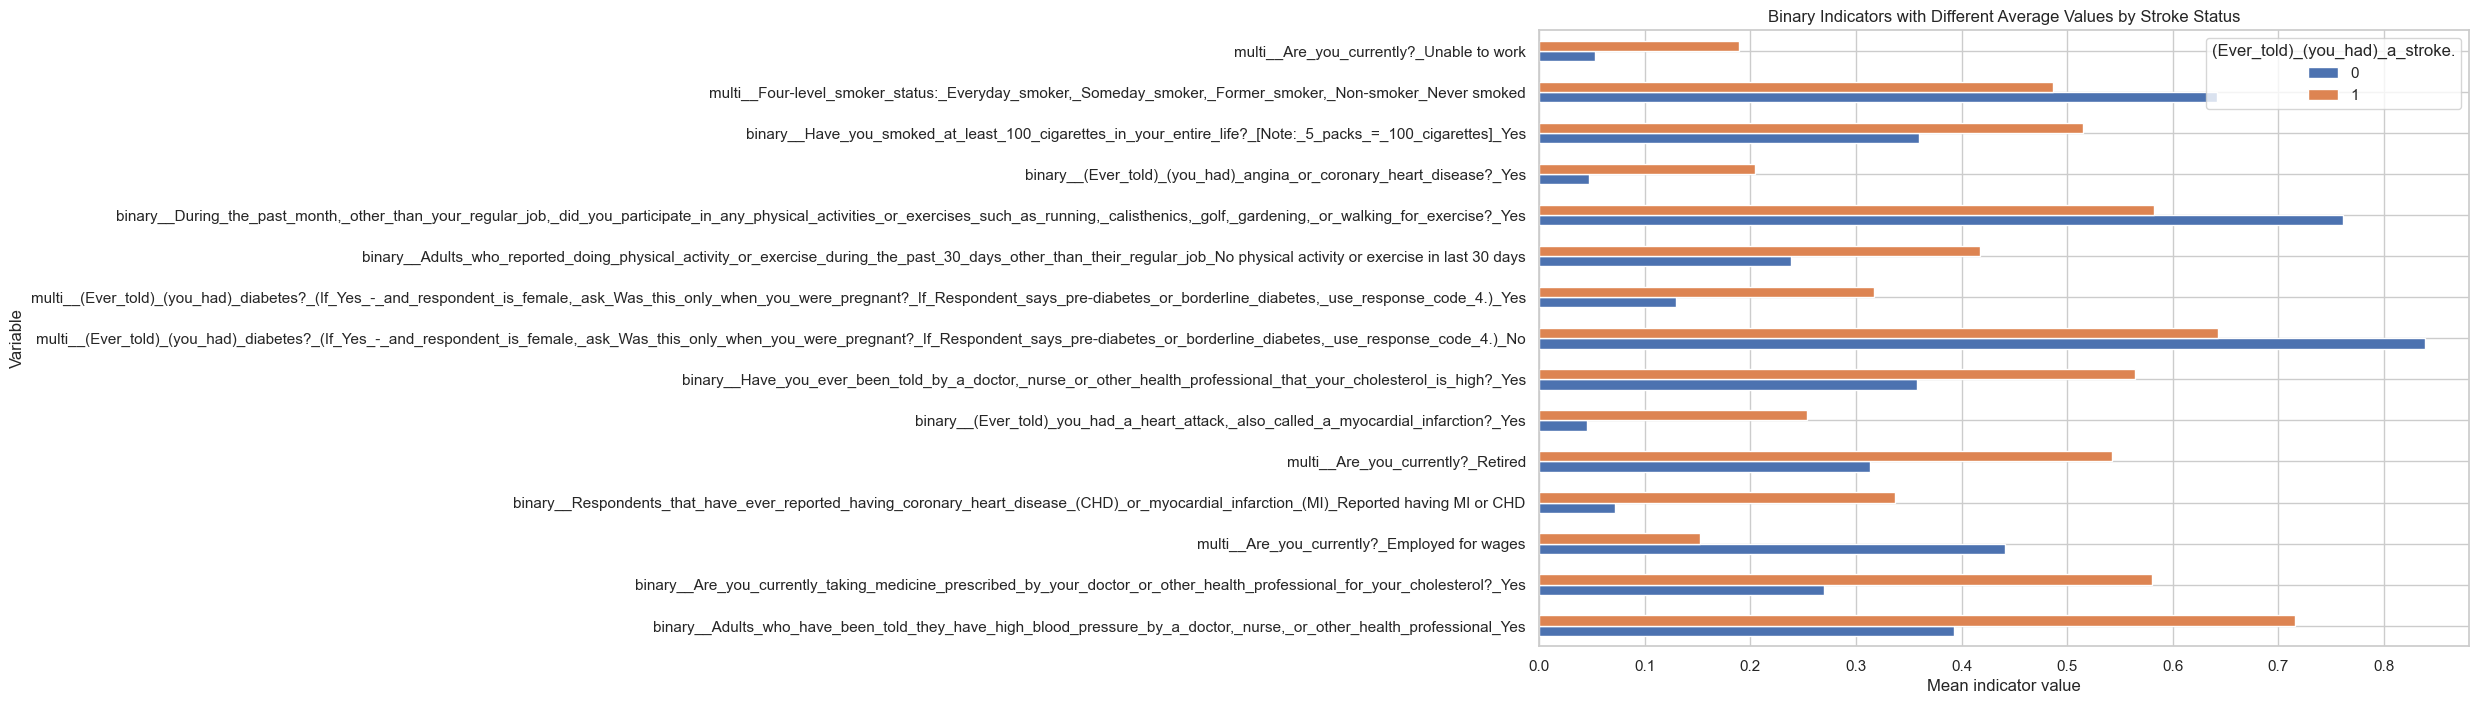

In [16]:
if not grouped_means.empty and grouped_means.shape[1] >= 2:
    comparison = grouped_means.copy()
    comparison["absolute_difference"] = (
        comparison.iloc[:, 1] - comparison.iloc[:, 0]
    ).abs()

    top_indicators = comparison.sort_values(
        "absolute_difference", ascending=False
    ).head(15).index

    grouped_means.loc[top_indicators].plot(
        kind="barh", figsize=(12, 8)
    )
    plt.title("Binary Indicators with Different Average Values by Stroke Status")
    plt.xlabel("Mean indicator value")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()


## 9. Correlation Analysis

Correlation measures statistical association, not causation. Because many columns are encoded indicators, correlations should be interpreted carefully.

C:\Users\nitya\AppData\Local\Temp\ipykernel_16504\1860589808.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


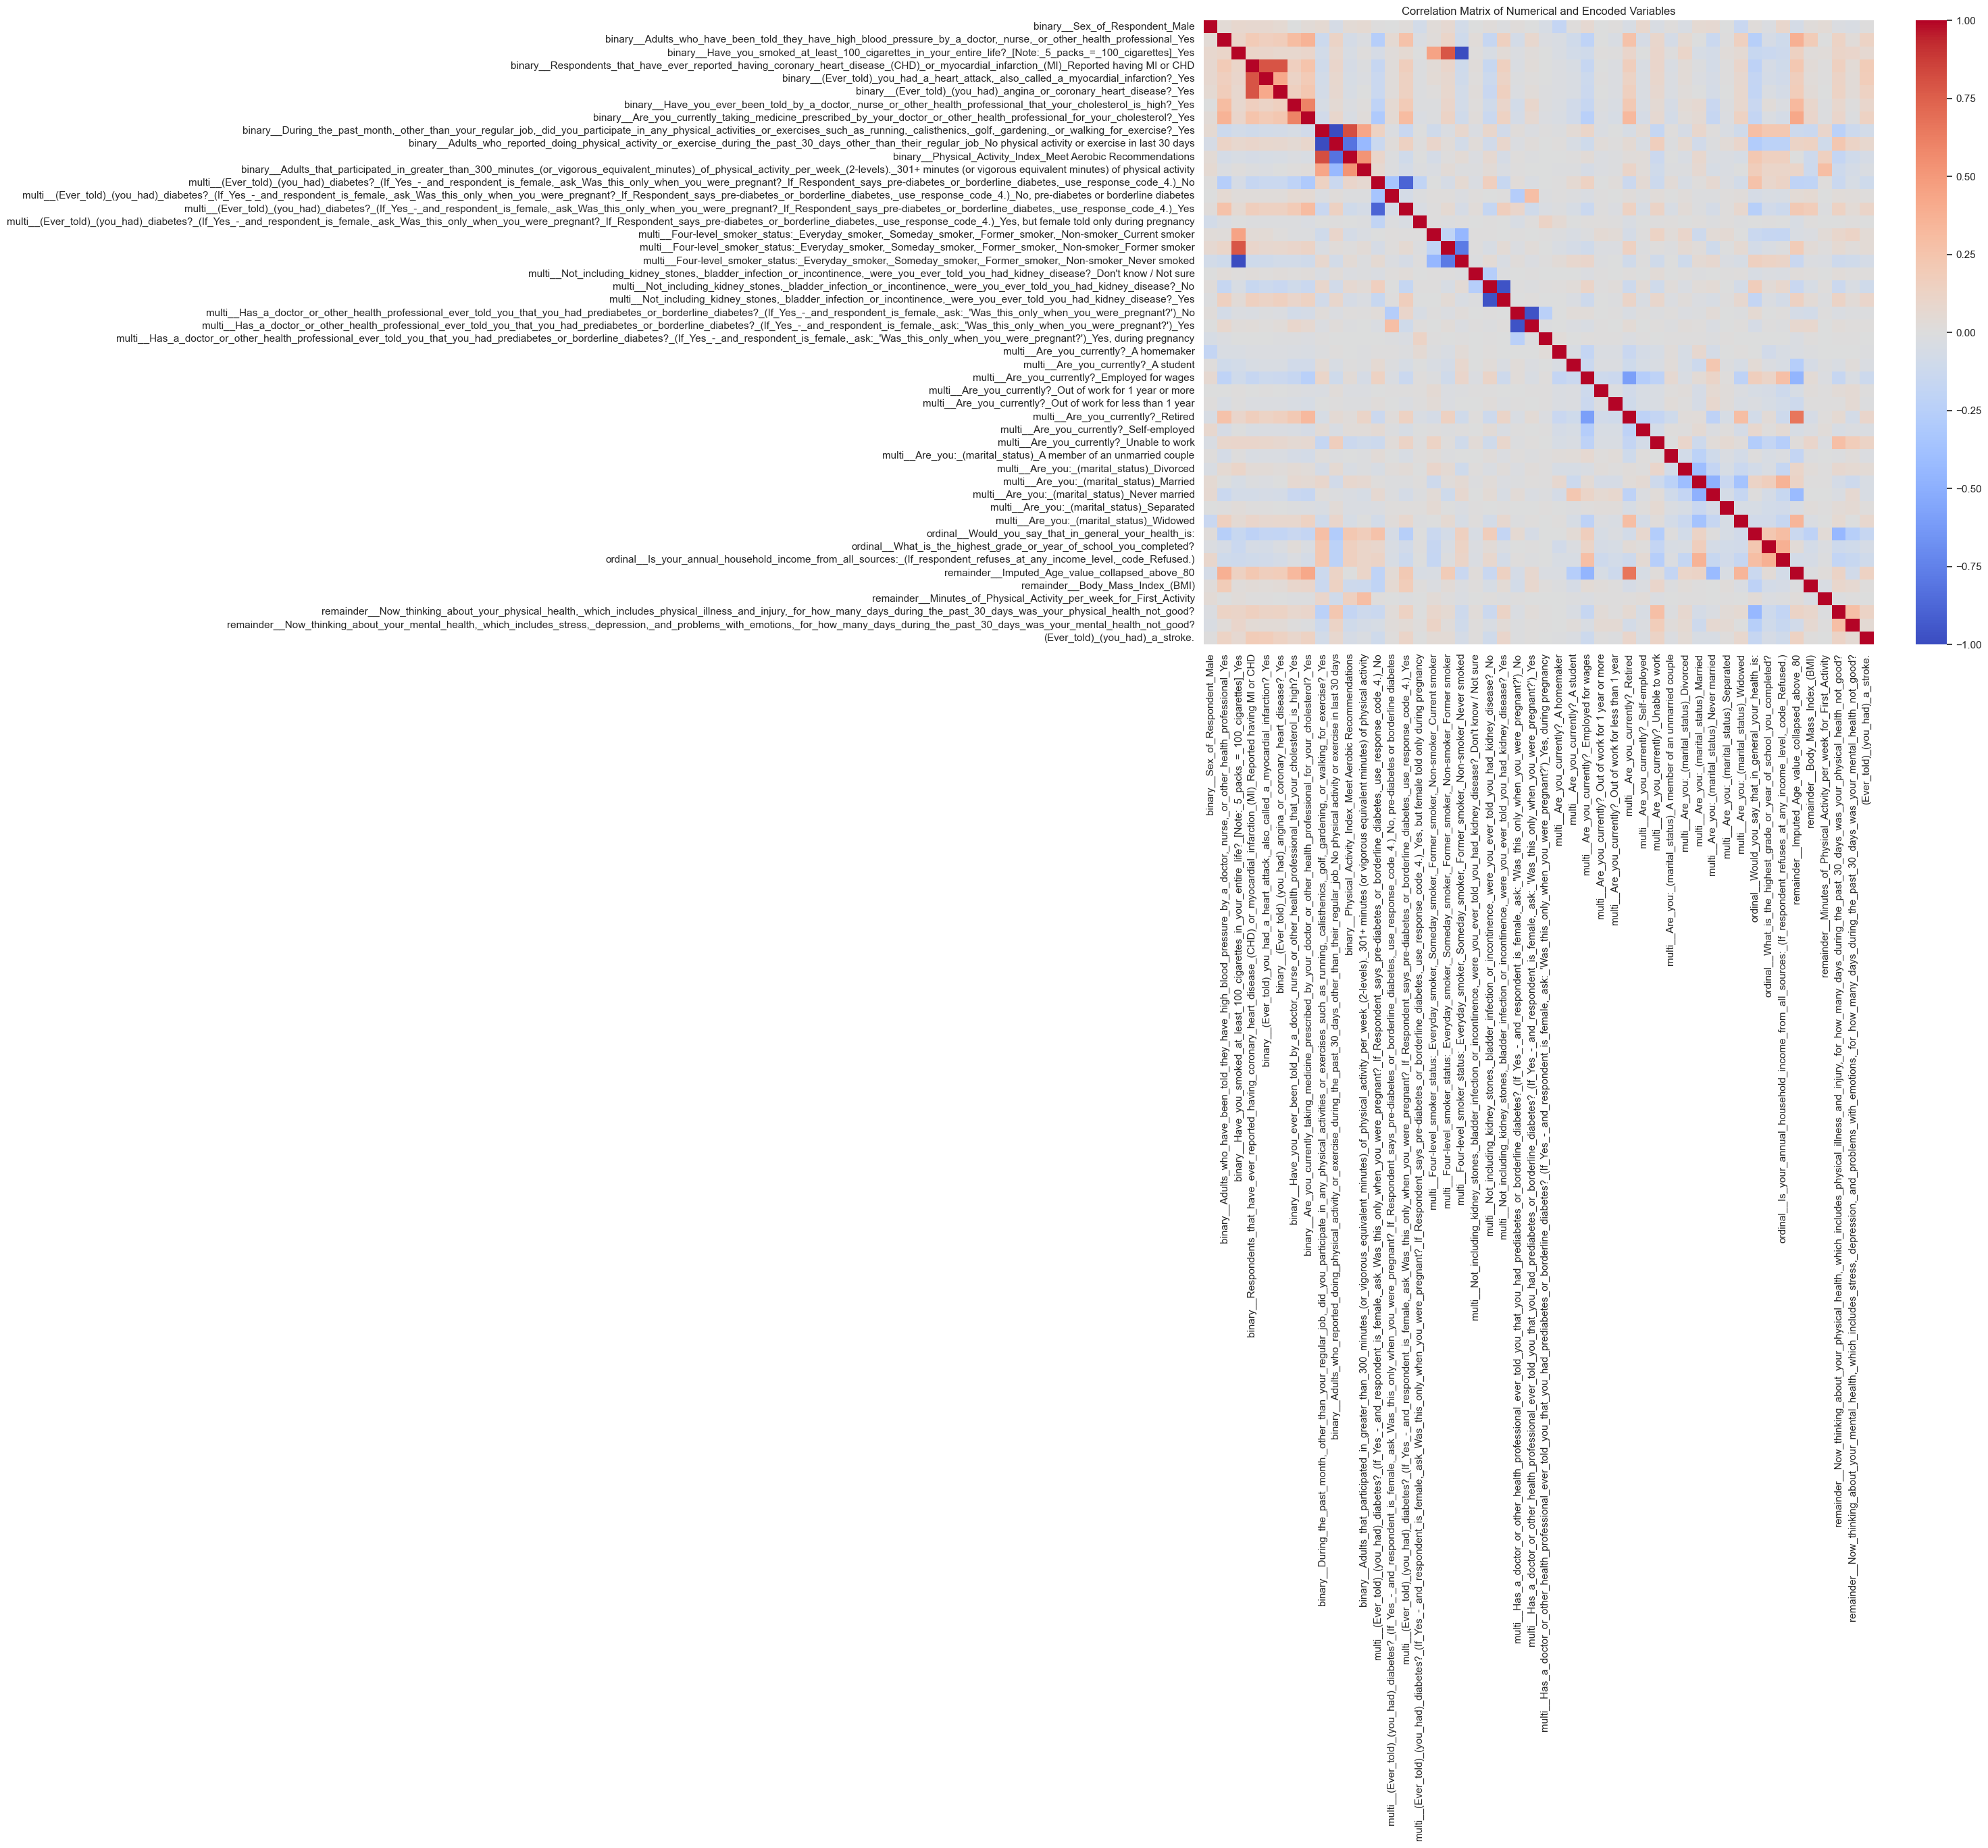

In [17]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical and Encoded Variables")
plt.tight_layout()
plt.show()


In [18]:
target_correlations = (
    correlation_matrix[target_col]
    .drop(target_col)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(target_correlations.to_frame("correlation_with_stroke"))


,correlation_with_stroke
binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,0.192550
"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",0.186136
ordinal__Would_you_say_that_in_general_your_health_is:,-0.156541
binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,0.140079
remainder__Imputed_Age_value_collapsed_above_80,0.139233
binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,0.138900
"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",0.132499
"remainder__Now_thinking_about_your_physical_health,_which_includes_physical_illness_and_injury,_for_how_many_days_during_the_past_30_days_was_your_physical_health_not_good?",0.122332
multi__Are_you_currently?_Unable to work,0.117715
multi__Are_you_currently?_Employed for wages,-0.117576


## 10. Outlier Detection

Outlier detection is applied to numerical variables with more than 10 unique values. Binary and one-hot encoded variables are excluded.

In [19]:
continuous_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != target_col and df[col].nunique() > 10
]

outlier_summary = []

for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": round(outlier_count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary.sort_values("outlier_percentage", ascending=False))


,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
4,"remainder__Now_thinking_about_your_physical_health,_which_includes_physical_illness_and_injury,_for_how_many_days_du...",6.00,6.00,0.0,6.00,6.00,130198,37.71
5,"remainder__Now_thinking_about_your_mental_health,_which_includes_stress,_depression,_and_problems_with_emotions,_for...",7.00,7.00,0.0,7.00,7.00,127951,37.06
3,remainder__Minutes_of_Physical_Activity_per_week_for_First_Activity,105.00,225.00,120.0,-75.00,405.00,47074,13.64
0,"ordinal__Is_your_annual_household_income_from_all_sources:_(If_respondent_refuses_at_any_income_level,_code_Refused.)",5.00,7.00,2.0,2.00,10.00,15224,4.41
2,remainder__Body_Mass_Index_(BMI),24.39,31.09,6.7,14.34,41.14,14229,4.12
1,remainder__Imputed_Age_value_collapsed_above_80,41.00,71.00,30.0,-4.00,116.00,0,0.00


## 11. Group-wise Summary Tables

In [20]:
if numeric_feature_cols:
    numerical_by_stroke = df.groupby(target_col)[numeric_feature_cols].agg(
        ["mean", "median", "std"]
    )
    display(numerical_by_stroke)


binary__Sex_of_Respondent_Male         \
                                                          mean median   
(Ever_told)_(you_had)_a_stroke.                                         
0                                                     0.470356    0.0   
1                                                     0.473519    0.0   

                                           \
                                      std   
(Ever_told)_(you_had)_a_stroke.             
0                                0.499121   
1                                0.499315   

                                binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes  \
                                                                                                                                                mean   
(Ever_told)_(you_had)_a_stroke.                                                                                                                        
0                                                                                                                                           0.392787   
1                                                                                                                                           0.715425   

                                                  \
                                median       std   
(Ever_told)_(you_had)_a_stroke.                    
0                                  0.0  0.488371   
1                                  1.0  0.451227   

                                binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes  \
                                                                                                                                     mean   
(Ever_told)_(you_had)_a_stroke.                                                                                                             
0                                                                                                                                0.359669   
1                                                                                                                                0.514961   

                                                  \
                                median       std   
(Ever_told)_(you_had)_a_stroke.                    
0                                  0.0  0.479904   
1                                  1.0  0.499793   

                                binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD  \
                                                                                                                                                                   mean   
(Ever_told)_(you_had)_a_stroke.                                                                                                                                           
0                                                                                                                                               0.072399                  
1                                                                                                                                               0.336651                  

                                                  \
                                median       std   
(Ever_told)_(you_had)_a_stroke.                    
0                                  0.0  0.259148   
1                                  0.0  0.472580   

                                binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes  \
                                                                                                                mean   
(Ever_told)_(you_had)_a_stroke.                                                               

In [21]:
feature_stroke_rates = []

for col in low_cardinality_cols:
    summary = (
        df.groupby(col)[target_col]
          .agg(["count", "mean"])
          .reset_index()
          .rename(columns={"mean": "stroke_rate"})
    )

    summary["variable"] = col
    feature_stroke_rates.append(summary)

if feature_stroke_rates:
    feature_stroke_rates = pd.concat(feature_stroke_rates, ignore_index=True)
    feature_stroke_rates["stroke_rate_percentage"] = (
        feature_stroke_rates["stroke_rate"] * 100
    ).round(2)

    display(feature_stroke_rates)


,binary__Sex_of_Respondent_Male,count,stroke_rate,variable,"binary__Adults_who_have_been_told_they_have_high_blood_pressure_by_a_doctor,_nurse,_or_other_health_professional_Yes",binary__Have_you_smoked_at_least_100_cigarettes_in_your_entire_life?_[Note:_5_packs_=_100_cigarettes]_Yes,binary__Respondents_that_have_ever_reported_having_coronary_heart_disease_(CHD)_or_myocardial_infarction_(MI)_Reported having MI or CHD,"binary__(Ever_told)_you_had_a_heart_attack,_also_called_a_myocardial_infarction?_Yes",binary__(Ever_told)_(you_had)_angina_or_coronary_heart_disease?_Yes,"binary__Have_you_ever_been_told_by_a_doctor,_nurse_or_other_health_professional_that_your_cholesterol_is_high?_Yes",binary__Are_you_currently_taking_medicine_prescribed_by_your_doctor_or_other_health_professional_for_your_cholesterol?_Yes,"binary__During_the_past_month,_other_than_your_regular_job,_did_you_participate_in_any_physical_activities_or_exercises_such_as_running,_calisthenics,_golf,_gardening,_or_walking_for_exercise?_Yes",binary__Adults_who_reported_doing_physical_activity_or_exercise_during_the_past_30_days_other_than_their_regular_job_No physical activity or exercise in last 30 days,binary__Physical_Activity_Index_Meet Aerobic Recommendations,binary__Adults_that_participated_in_greater_than_300_minutes_(or_vigorous_equivalent_minutes)_of_physical_activity_per_week_(2-levels)._301+ minutes (or vigorous equivalent minutes) of physical activity,"multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_No","multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_No, pre-diabetes or borderline diabetes","multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_Yes","multi__(Ever_told)_(you_had)_diabetes?_(If_Yes_-_and_respondent_is_female,_ask_Was_this_only_when_you_were_pregnant?_If_Respondent_says_pre-diabetes_or_borderline_diabetes,_use_response_code_4.)_Yes, but female told only during pregnancy","multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Current smoker","multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Former smoker","multi__Four-level_smoker_status:_Everyday_smoker,_Someday_smoker,_Former_smoker,_Non-smoker_Never smoked","multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_Don't know / Not sure","multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_No","multi__Not_including_kidney_stones,_bladder_infection_or_incontinence,_were_you_ever_told_you_had_kidney_disease?_Yes","multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_No","multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_Yes","multi__Has_a_doctor_or_other_health_professional_ever_told_you_that_you_had_prediabetes_or_borderline_diabetes?_(If_Yes_-_and_respondent_is_female,_ask:_'Was_this_only_when_you_were_pregnant?')_Yes, during pregnancy",multi__Are_you_currently?_A homemaker,multi__Are_you_currently?_A student,multi__Are_you_currently?_Employed for wages,multi__Are_you_currently?_Out of work for 1 year or more,multi__Are_you_currently?_Out of work for less than 1 year,multi__Are_you_currently?_Retired,multi__Are_you_currently?_Self-employed,multi__Are_you_currently?_Unable to work,multi__Are

## 12. EDA Findings Template

Use the outputs above to write observations in a descriptive way. Avoid claiming that a variable causes stroke.

- **Dataset structure:** Describe the number of rows, columns, and data types.
- **Data quality:** Report missing values, duplicate rows, and unusual values.
- **Target distribution:** State the number and percentage of stroke and non-stroke observations.
- **Basic user information:** Describe noticeable differences in age, sex, marital status, education, employment, and income across stroke groups.
- **Health variables:** Describe which health indicators appear more common among stroke-positive observations.
- **Lifestyle variables:** Describe patterns in smoking and physical activity.
- **Physical and mental well-being:** Compare BMI and physical/mental health-day distributions.
- **Associations:** Mention the strongest observed relationships while stating that correlation does not imply causation.
- **Outliers:** Identify variables with unusually high outlier percentages and decide whether they represent valid observations or data-quality issues.

### Important interpretation note

This notebook is intended to understand trends and patterns in the data. The observations are exploratory and should not be interpreted as medical conclusions or causal relationships.